In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_predict,RandomizedSearchCV,GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline,make_pipeline
from xgboost import XGBRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, ConstantKernel as C,DotProduct, RationalQuadratic
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# 容错导入SHAP
try:
    import shap
except Exception as e:
    print(f"SHAP导入失败: {e}")
    shap = None

import warnings
warnings.filterwarnings("ignore")

/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Hiragino Sans GB', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 全局统一调色板（全笔记本快速调用）
COLOR_PALETTE = {
    'blue_light': '#9ecae1',
    'blue_mid': '#4292c6',
    'blue_dark': '#08519c',
    'green': '#59A14F',
    'red': '#D62728',
    'orange': '#F28E2B',
    'gray': '#9A9A9A',
    'yellow': '#F1CE63',
    'purple': '#6A3D9A'
}

# 快捷颜色变量（推荐后续统一使用）
CLR_BLUE_LIGHT = COLOR_PALETTE['blue_light']
CLR_BLUE_MID = COLOR_PALETTE['blue_mid']
CLR_BLUE_DARK = COLOR_PALETTE['blue_dark']
CLR_GREEN = COLOR_PALETTE['green']
CLR_RED = COLOR_PALETTE['red']
CLR_ORANGE = COLOR_PALETTE['orange']
CLR_GRAY = COLOR_PALETTE['gray']
CLR_YELLOW = COLOR_PALETTE['yellow']
CLR_PURPLE = COLOR_PALETTE['purple']

# 常用组合
LEVEL_BLUE_COLORS = [CLR_BLUE_LIGHT, CLR_BLUE_MID, CLR_BLUE_DARK]


In [4]:
# 初始准备工作
# 1.读取清洗好的数据
file_path = "Final_Features_Ultimate_all_deletion.csv" 
df = pd.read_csv(file_path)

In [5]:
# 2. 定义特征组 (严格对齐新版 CSV 列名)

# A. 力学特征组 (用于预测 Strength, Elongation)
# 包含：用量层 + 身份层 + 机理层
features_mech = [
    # --- 1. 用量层 (Dosage) ---
    'X1_Soft_Content',      # 软段含量 (原 X1_SoftSeg)
    'X2_DA_Content',        # DA单体含量
    'X3_Hard_Content',      # 硬段含量 (原 X3_HardSeg)
    'X4_R_Ratio',           # 异氰酸酯指数
    'X5_Add_Crosslink',     # 额外非DA交联剂含量 (原 X5_Crosslink)
    
    # --- 2. 身份层 (Identity) ---
    'DA_Linker_Type',       # 0=无, 1=糠胺, 2=糠醇 (替代原来的 DA_KA/KC)
    'Network_Topology',     # 0=主链, 1=侧链 (替代原来的 cross_class)
    'Polyol_Class',         # 0=聚醚, 1=聚酯 (替代 Polyol_Type)
    'Iso_Class',            # 0=脂肪族, 1=芳香族 (替代 Iso_Type 1-5分)
    
    # --- 3. 机理层 (Mechanism) ---
    'Soft_Mw',              # 软段分子量
    'Constraint_Factor',    # 冻结因子 (关键!)
    'Hard_Symmetry',        # 硬段对称性
    'Soft_Cryst',           # 软段结晶性
    'Synergy_Feature'       # 结晶协同因子
    # 注意：Extender_Class、Add_Crosslinker_Flag 已删除（与 X5_Add_Crosslink 完全相关 r=1.0）
]

# B. 愈合特征组 (用于预测 Healing Efficiency)
# 包含：力学特征 + 工艺参数 (温度、时间)
features_heal = features_mech + ['healing_temperature', 'healing_time']

# 3. 二次清洗 (逻辑保持不变)
def get_clean_data(target_col, feature_cols, df):
    """
    清洗数据：仅保留目标值和特征值都不为空的行
    """
    missing_cols = [c for c in feature_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"以下特征在 CSV 中找不到，请检查列名拼写: {missing_cols}")

    data = df.dropna(subset=[target_col] + feature_cols).copy()
    X = data[feature_cols].values
    y = data[target_col].values
    return X, y

# 4. 定义评估函数 (逻辑保持不变)
def evaluate_model(model, X, y, task_name="Task"):
    cv = LeaveOneOut()
    y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    return r2, rmse, y_pred



# 6. 嵌套 LOOCV + 内层 KFold 调参（多模型单元调用）
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV


def nested_loocv_tune_eval(
    model_name,
    base_estimator,
    param_space,
    X,
    y,
    grid_threshold=60,
    random_iter=25,
    outer_mode="kfoldOuter",
    n_outer_splits=5,
    inner_split_cap=3,
    search_n_jobs=1,
):
    """嵌套交叉验证调参 + 评估。

    - outer_mode='loo': 外层留一（极慢，仅小样本/最终严谨评估用）
    - outer_mode='kfoldOuter'（或 'kfold' 别名）: 外层 K 折（**多模型对比默认**，耗时可控，仍为嵌套无泄露）

    Jupyter/macOS 下 search_n_jobs=-1 容易卡死或极慢，默认改 1。
    """
    X_arr = np.asarray(X)
    y = np.asarray(y).ravel()
    n = len(y)
    y_pred = np.full(n, np.nan, dtype=float)
    inner_rmse = []
    fold_params = []
    route = "NestedCV"

    if outer_mode == "loo":
        outer = LeaveOneOut()
        route = "NestedLOOCV"
    elif outer_mode in ("kfoldOuter", "kfold"):
        k = min(n_outer_splits, n)
        if k < 2:
            raise ValueError("样本过少，无法进行外层 K 折")
        outer = KFold(n_splits=k, shuffle=True, random_state=42)
        route = f"Nested{k}Fold"
    else:
        raise ValueError("outer_mode 须为 'loo' / 'kfoldOuter' / 'kfold'")

    splits = list(outer.split(X_arr))
    n_out = len(splits)
    for i, (tr, te) in enumerate(splits):
        if i == 0 or i == n_out - 1 or (i + 1) % max(1, n_out // 3) == 0:
            print(f"  -> {model_name}: {route} 外层进度 {i + 1}/{n_out}")

        X_tr, X_te = X_arr[tr], X_arr[te]
        y_tr, y_te = y[tr], y[te]
        nn = len(tr)
        ns = min(inner_split_cap, nn)
        inner = KFold(n_splits=ns, shuffle=True, random_state=42) if ns >= 2 else None
        est = clone(base_estimator)

        if not param_space:
            est.fit(X_tr, y_tr)
            y_pred[te] = np.asarray(est.predict(X_te)).ravel()
            fold_params.append({})
            continue
        if inner is None:
            est.fit(X_tr, y_tr)
            y_pred[te] = np.asarray(est.predict(X_te)).ravel()
            fold_params.append({})
            continue

        n_comb = len(list(ParameterGrid(param_space)))
        if n_comb <= grid_threshold:
            search = GridSearchCV(
                est,
                param_space,
                cv=inner,
                scoring="neg_mean_squared_error",
                n_jobs=search_n_jobs,
                verbose=0,
            )
            sub_route = f"Grid({n_comb})"
        else:
            ni = min(random_iter, n_comb)
            search = RandomizedSearchCV(
                est,
                param_distributions=param_space,
                n_iter=ni,
                cv=inner,
                scoring="neg_mean_squared_error",
                random_state=42,
                n_jobs=search_n_jobs,
                verbose=0,
            )
            sub_route = f"Rand({ni}/{n_comb})"

        search.fit(X_tr, y_tr)
        y_pred[te] = np.asarray(search.predict(X_te)).ravel()
        inner_rmse.append(float(np.sqrt(-search.best_score_)))
        fold_params.append(search.best_params_)
        route = f"{route}+{sub_route}"

    if np.isnan(y_pred).any():
        raise RuntimeError("nested_loocv_tune_eval: 存在未填充的预测（请检查外层划分）")

    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    tune_rmse = float(np.mean(inner_rmse)) if inner_rmse else np.nan
    import json as _j
    from collections import Counter as _C

    keys = [_j.dumps(p, sort_keys=True, default=str) for p in fold_params if p]
    maj = _j.loads(_C(keys).most_common(1)[0][0]) if keys else {}
    final_m = clone(base_estimator)
    if maj:
        final_m.set_params(**maj)
    final_m.fit(X_arr, y)
    return final_m, route, maj, tune_rmse, r2, rmse, y_pred


# 5. 检查与验证
print("特征组定义完毕！")
print(f"力学模型特征数: {len(features_mech)}")
print(f"自愈合模型特征数: {len(features_heal)}")

try:
    print("\n特征数据概览 (前5行):")
    print(df[features_mech].head())
    print(f"\n有效总样本数: {len(df)}")
except KeyError as e:
    print(f"\n❌ 错误：CSV列名不匹配！报错列名: {e}")
except NameError:
    print("\n⚠️ 提示：df 尚未加载，请先读取 CSV 文件。")



特征组定义完毕！
力学模型特征数: 14
自愈合模型特征数: 16

特征数据概览 (前5行):
   X1_Soft_Content  X2_DA_Content  X3_Hard_Content  X4_R_Ratio  \
0           0.6607         0.1924           0.1469      0.5000   
1           0.6825         0.1658           0.1517      0.5333   
2           0.4880         0.0800           0.4320      0.9677   
3           0.6651         0.0000           0.3349      1.3333   
4           0.5592         0.0000           0.4078      1.0000   

   X5_Add_Crosslink  DA_Linker_Type  Network_Topology  Polyol_Class  \
0             0.000               2                 0             1   
1             0.000               2                 0             1   
2             0.000               2                 1             0   
3             0.000               0                 0             0   
4             0.033               0                 0             0   

   Iso_Class  Soft_Mw  Constraint_Factor  Hard_Symmetry  Soft_Cryst  \
0          0   2000.0             0.0001              0 

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

Pearson 相关性分析（双目标：tensile_strength + elongation）
有效样本数: 84
分析维度: 14 特征 + 2 目标

✅ 无常数特征，Pearson 矩阵完整

✅ 高相关特征对检查（|r| > 0.85）
   X3_Hard_Content ↔ Constraint_Factor: 0.856

✅ 各目标 Top5 线性相关特征

   tensile_strength:
      X3_Hard_Content: 0.653
      Soft_Cryst: 0.594
      Constraint_Factor: 0.435
      X1_Soft_Content: 0.397
      Synergy_Feature: 0.359

   elongation:
      X2_DA_Content: 0.425
      Hard_Symmetry: 0.414
      Iso_Class: 0.336
      X1_Soft_Content: 0.313
      X4_R_Ratio: 0.288


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

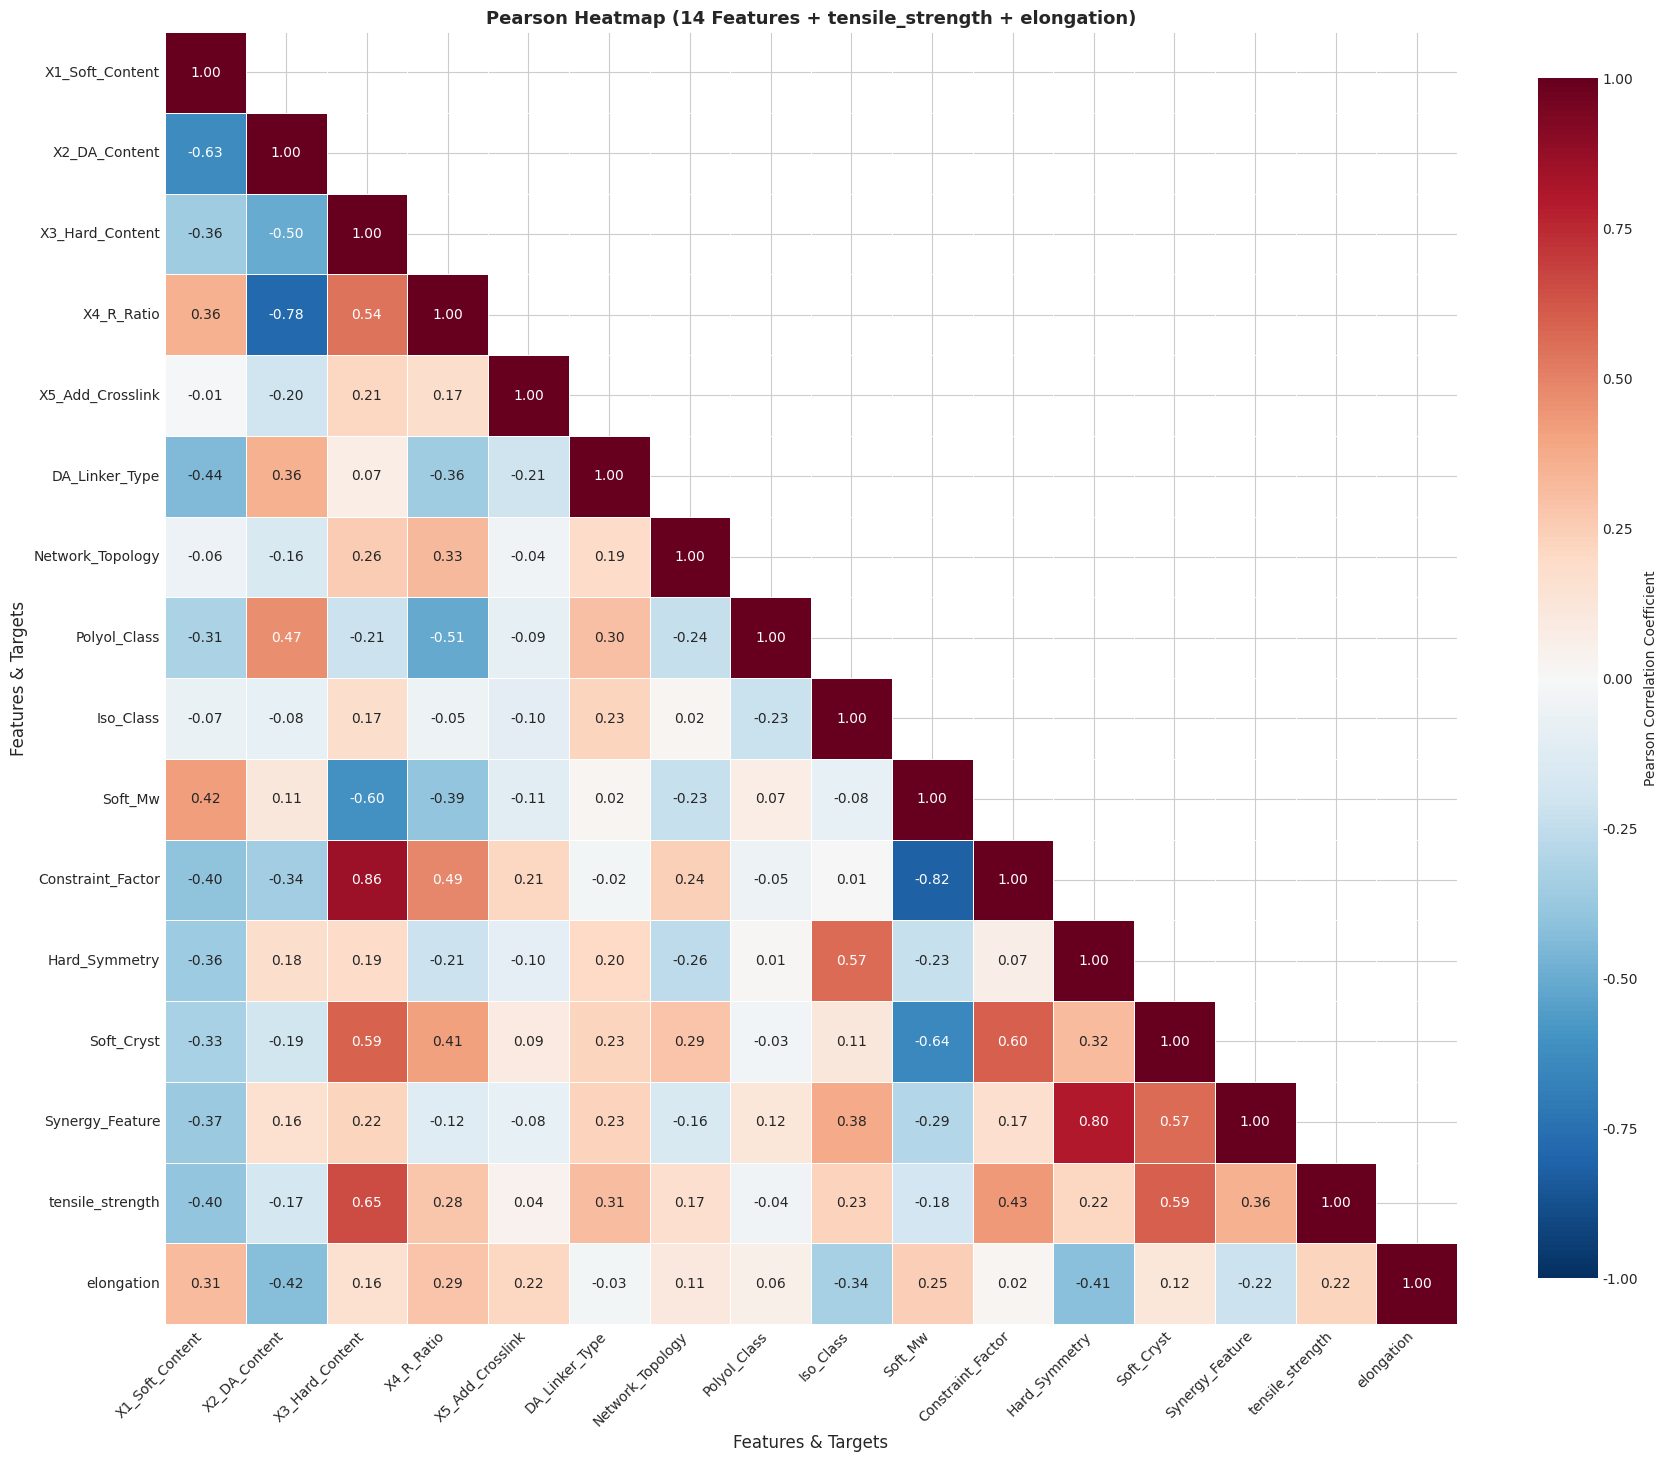


分析完成：双目标 Pearson（n=84）


In [21]:
# ============================================
# Pearson 相关性分析（双目标：tensile_strength + elongation）
# ============================================
"""
目的：
1. 检查特征冗余（多重共线性）
2. 识别与两个力学目标线性相关最强的特征
3. 为后续 Top-7 特征精选图提供基础
"""

targets_pearson = ['tensile_strength', 'elongation']

print("="*80)
print("Pearson 相关性分析（双目标：tensile_strength + elongation）")
print("="*80)

# 使用力学特征 + 双目标，dropna 后得到最大样本量
pearson_data = df[features_mech + targets_pearson].dropna()
print(f"有效样本数: {len(pearson_data)}")
print(f"分析维度: {len(features_mech)} 特征 + {len(targets_pearson)} 目标")
corr_matrix_mech = pearson_data.corr(method='pearson')

# 常数列检查
zero_var_check = pearson_data[features_mech].nunique(dropna=True)
zero_var_check = zero_var_check[zero_var_check <= 1]
if len(zero_var_check) > 0:
    print("\n⚠️ 存在常数特征（Pearson 为 NaN）:")
    for col, nuniq in zero_var_check.items():
        print(f"   {col}: unique={nuniq}")
else:
    print("\n✅ 无常数特征，Pearson 矩阵完整")

# 特征间高相关检查
print("\n✅ 高相关特征对检查（|r| > 0.85）")
high_corr_features = []
for i in range(len(features_mech)):
    for j in range(i+1, len(features_mech)):
        corr_val = corr_matrix_mech.loc[features_mech[i], features_mech[j]]
        if abs(corr_val) > 0.85:
            high_corr_features.append((features_mech[i], features_mech[j], corr_val))
            print(f"   {features_mech[i]} ↔ {features_mech[j]}: {corr_val:.3f}")
if not high_corr_features:
    print("   未发现高度冗余的特征对")

# 各目标 Top5 线性相关特征
print("\n✅ 各目标 Top5 线性相关特征")
for target in targets_pearson:
    target_corr = corr_matrix_mech[target].drop(targets_pearson).abs().sort_values(ascending=False)
    top5 = target_corr.head(5)
    print(f"\n   {target}:")
    for feat, corr_val in top5.items():
        print(f"      {feat}: {corr_val:.3f}")

# 绘图：双目标全量热力图
fig, ax = plt.subplots(figsize=(18, 16))
mask = np.triu(np.ones_like(corr_matrix_mech, dtype=bool), k=1)
sns.heatmap(
    corr_matrix_mech,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"}
)
plt.title("Pearson Heatmap (14 Features + tensile_strength + elongation)", fontsize=13, fontweight='bold')
plt.xlabel("Features & Targets", fontsize=12)
plt.ylabel("Features & Targets", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("分析完成：双目标 Pearson（n=84）")
print("="*80)

入选连续特征与目标相关性（原始量纲计算）:
  X3_Hard_Content    | r_tensile= 0.653 | r_elong= 0.157 | sum|r|= 0.810
  X1_Soft_Content    | r_tensile=-0.397 | r_elong= 0.313 | sum|r|= 0.709
  X2_DA_Content      | r_tensile=-0.175 | r_elong=-0.425 | sum|r|= 0.599
  Synergy_Feature    | r_tensile= 0.359 | r_elong=-0.218 | sum|r|= 0.576
  X4_R_Ratio         | r_tensile= 0.279 | r_elong= 0.288 | sum|r|= 0.567
  Constraint_Factor  | r_tensile= 0.435 | r_elong= 0.022 | sum|r|= 0.457
  Soft_Mw            | r_tensile=-0.181 | r_elong= 0.246 | sum|r|= 0.428


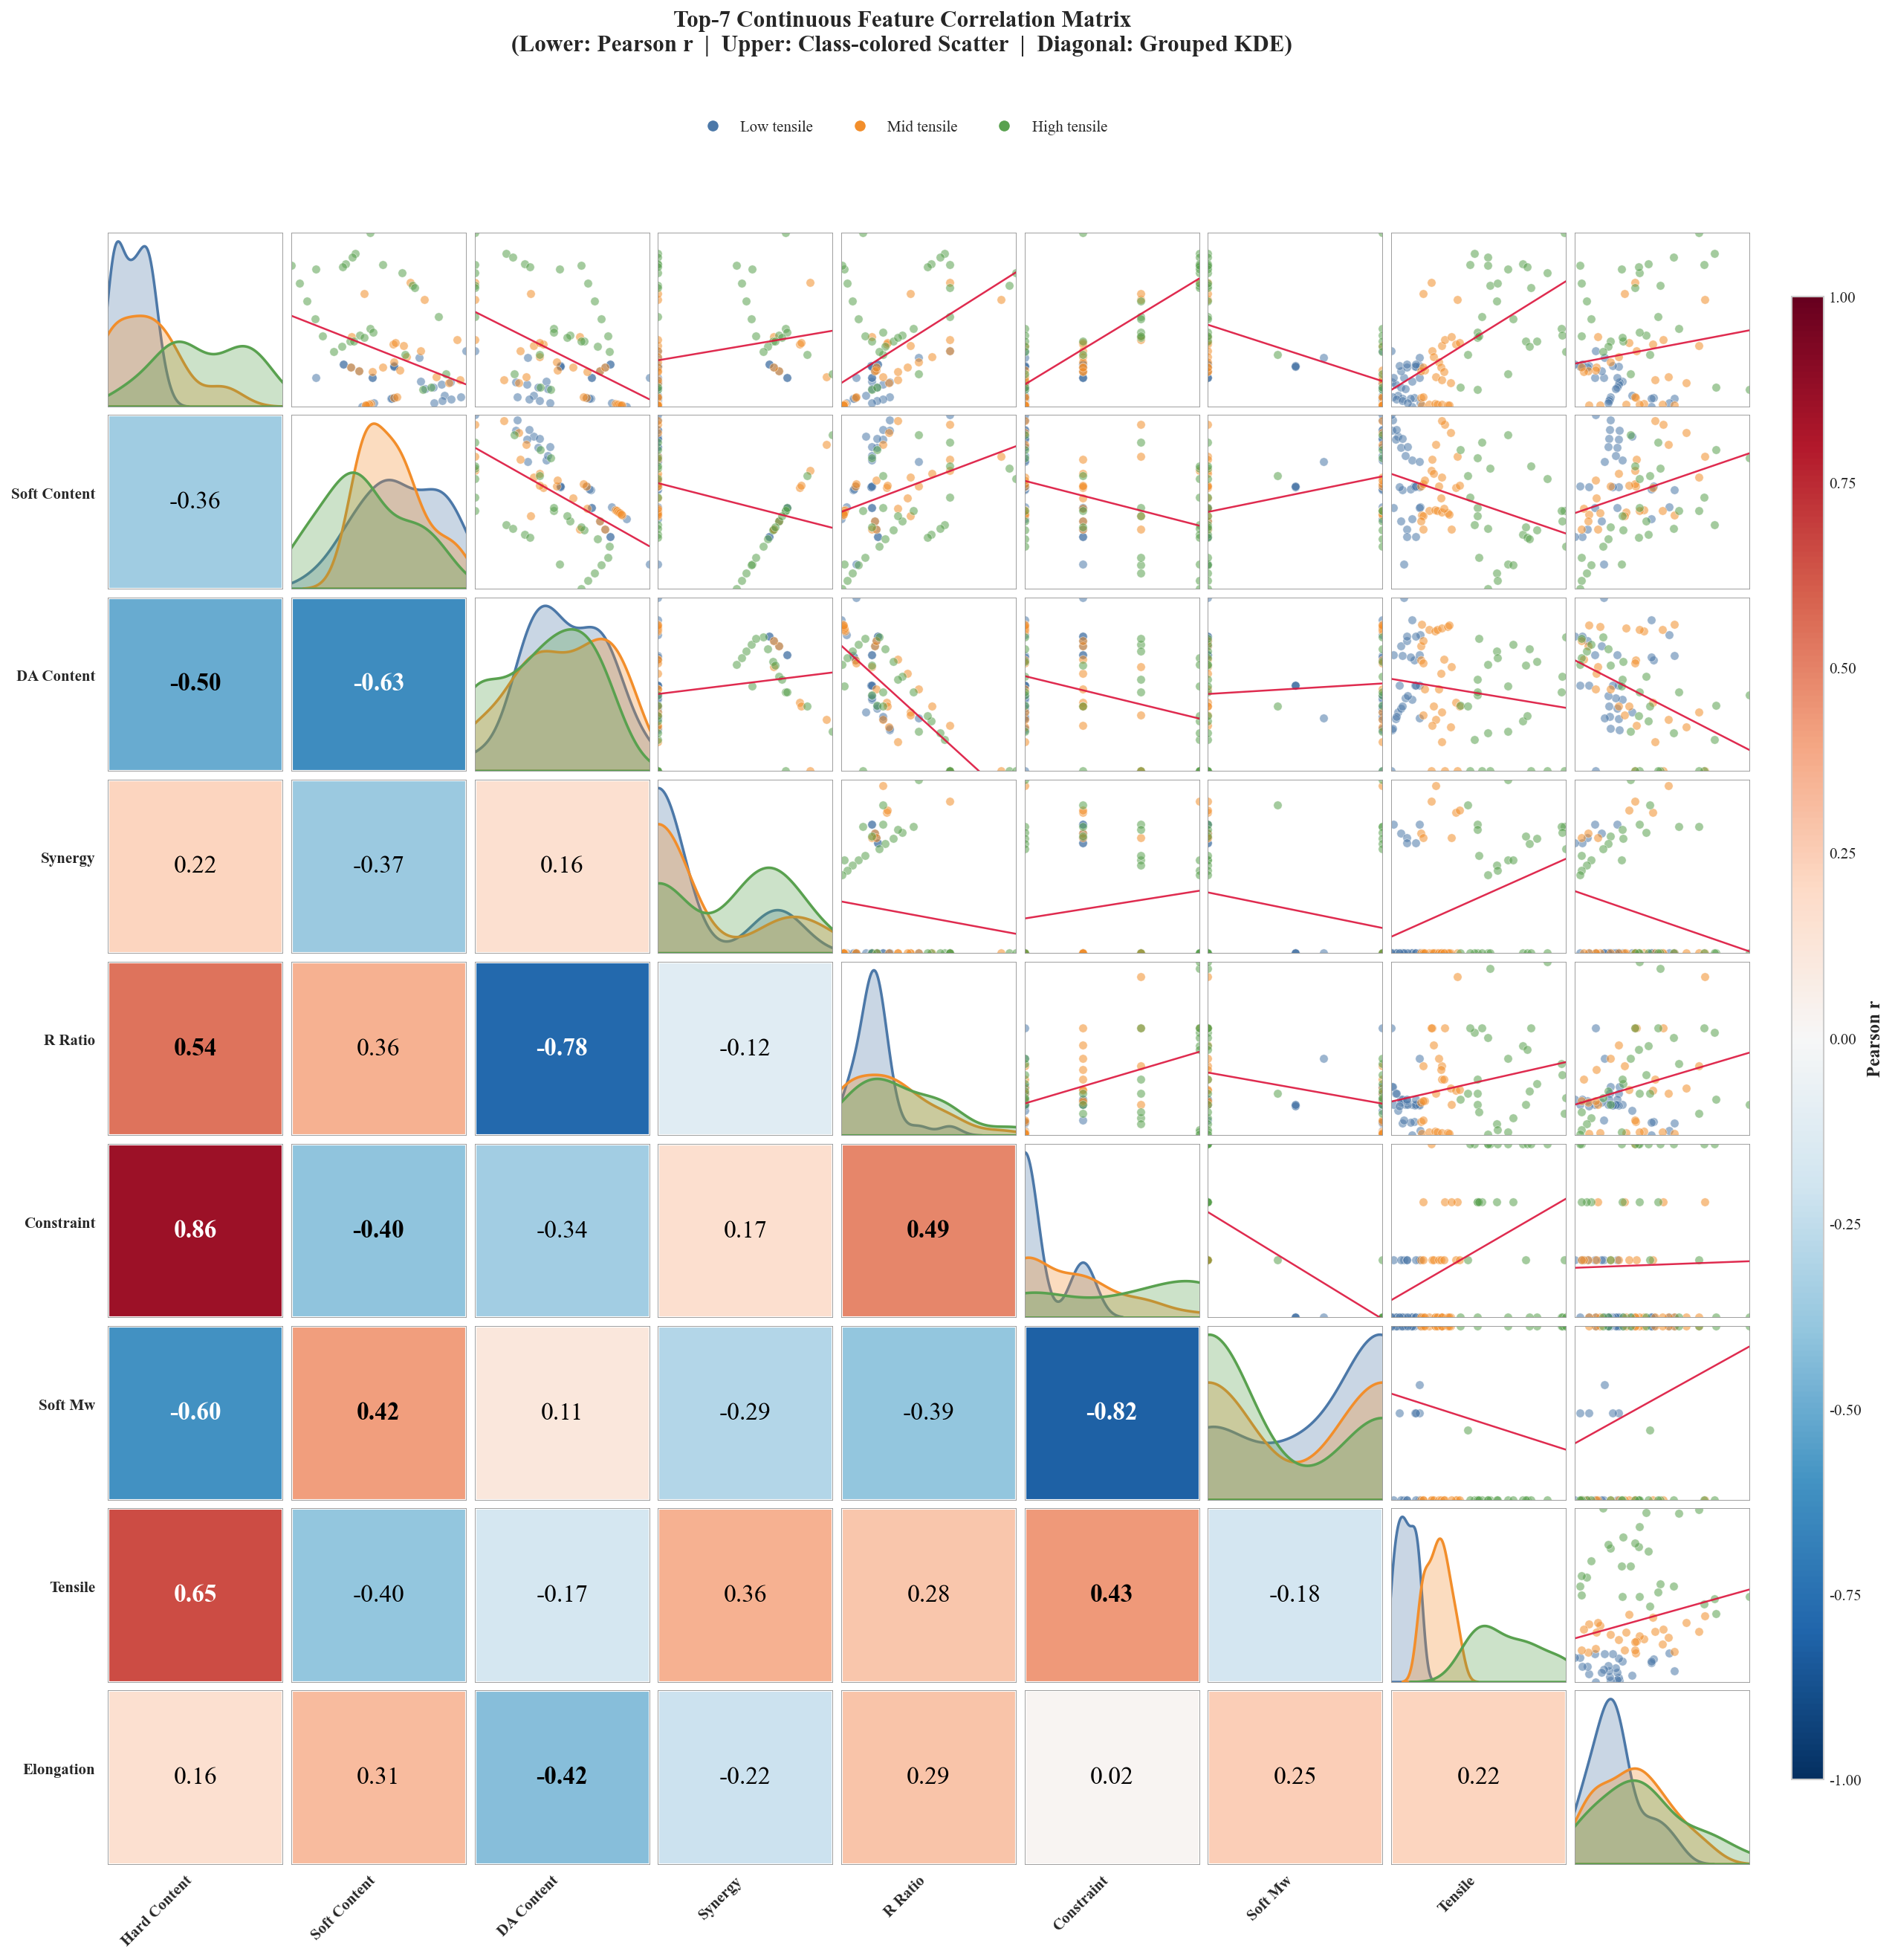

✅ 分类增强版组合图已保存为 Top7_Pearson_Matrix_continuous_classed.png


In [ ]:
# ============================================
# Top-7 连续特征 Pearson 组合图（去除二分类特征）
# 左下 = 相关系数热力块 | 右上 = 分层散点 | 对角线 = 分组KDE填充曲线
# ============================================
"""
增强点：
1) 去掉右上角等高线，仅保留分层散点 + 趋势线；
2) 对角线改为三组 KDE curve（fill=True）叠加；
3) 热力图数字字体放大，提高可读性。
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm

# ---------- 数据准备 ----------
top7_features = [
    'X3_Hard_Content',
    'X1_Soft_Content',
    'X2_DA_Content',
    'Synergy_Feature',
    'X4_R_Ratio',
    'Constraint_Factor',
    'Soft_Mw',
]
plot_targets = ['tensile_strength', 'elongation']

display_names = {
    'X3_Hard_Content': 'Hard Content',
    'X1_Soft_Content': 'Soft Content',
    'X2_DA_Content': 'DA Content',
    'Synergy_Feature': 'Synergy',
    'X4_R_Ratio': 'R Ratio',
    'Constraint_Factor': 'Constraint',
    'Soft_Mw': 'Soft Mw',
    'tensile_strength': 'Tensile',
    'elongation': 'Elongation',
}

# 以双目标有效样本为基础
data_plot_raw = pearson_data[top7_features + plot_targets].copy()

# 对7个连续特征做 0-1 归一化（目标保持原始量纲）
scaled_feats = {}
for col in top7_features:
    col_min = data_plot_raw[col].min()
    col_max = data_plot_raw[col].max()
    if np.isclose(col_max, col_min):
        scaled_feats[col] = pd.Series(np.zeros(len(data_plot_raw)), index=data_plot_raw.index)
    else:
        scaled_feats[col] = (data_plot_raw[col] - col_min) / (col_max - col_min)

data_plot = pd.DataFrame(scaled_feats)
data_plot['tensile_strength'] = data_plot_raw['tensile_strength']
data_plot['elongation'] = data_plot_raw['elongation']

# 按 tensile_strength 三分位做“类别分层”
q1, q2 = data_plot_raw['tensile_strength'].quantile([0.33, 0.67])
strength_class = pd.cut(
    data_plot_raw['tensile_strength'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['Low', 'Mid', 'High']
)
data_plot['strength_class'] = strength_class.values

class_palette = {
    'Low': '#4292c6',
    'Mid': '#F28E2B',
    'High': '#59A14F'
}

# 打印特征有效性（与目标相关）
corr_check = data_plot_raw[top7_features + plot_targets].corr(method='pearson')
print('入选连续特征与目标相关性（原始量纲计算）:')
for f in top7_features:
    r_t = corr_check.loc[f, 'tensile_strength']
    r_e = corr_check.loc[f, 'elongation']
    print(f"  {f:<18} | r_tensile={r_t:>6.3f} | r_elong={r_e:>6.3f} | sum|r|={abs(r_t)+abs(r_e):>6.3f}")

all_cols = top7_features + plot_targets
corr = data_plot[all_cols].corr(method='pearson')
n_vars = len(all_cols)

# ---------- 绘图 ----------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fig, axes = plt.subplots(n_vars, n_vars, figsize=(19, 19), dpi=150)
fig.subplots_adjust(hspace=0.05, wspace=0.05)

norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
cmap = plt.cm.RdBu_r

for i in range(n_vars):
    for j in range(n_vars):
        ax = axes[i, j]
        ax.set_xticks([])
        ax.set_yticks([])

        if i == j:
            vals = data_plot.iloc[:, i].dropna()

            # 对角线：按类别分组叠加 KDE（fill=True）
            for cls in ['Low', 'Mid', 'High']:
                cls_vals = data_plot.loc[data_plot['strength_class'] == cls, all_cols[i]].dropna()
                if len(cls_vals) > 3 and cls_vals.nunique() > 1:
                    sns.kdeplot(
                        x=cls_vals,
                        ax=ax,
                        fill=True,
                        alpha=0.30,
                        linewidth=1.7,
                        color=class_palette[cls],
                        common_norm=False
                    )
            ax.set_xlim(vals.min(), vals.max())

        elif i > j:
            r_val = corr.iloc[i, j]
            color = cmap(norm(r_val))
            ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                   facecolor=color, edgecolor='white', linewidth=1.5))
            fontsize = 16
            fontweight = 'bold' if abs(r_val) >= 0.4 else 'normal'
            txt_color = 'white' if abs(r_val) >= 0.6 else 'black'
            ax.text(0.5, 0.5, f'{r_val:.2f}', transform=ax.transAxes,
                    ha='center', va='center', fontsize=fontsize,
                    fontweight=fontweight, color=txt_color)

        else:
            x_vals = data_plot.iloc[:, j]
            y_vals = data_plot.iloc[:, i]

            # 右上：按类别着色散点（放大 & 更透明）
            for cls in ['Low', 'Mid', 'High']:
                cls_mask = data_plot['strength_class'] == cls
                ax.scatter(
                    x_vals[cls_mask], y_vals[cls_mask],
                    s=30, alpha=0.55, c=class_palette[cls],
                    edgecolors='white', linewidths=0.35
                )

            # 趋势线
            valid = x_vals.notna() & y_vals.notna()
            if valid.sum() > 2:
                z_fit = np.polyfit(x_vals[valid], y_vals[valid], 1)
                x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
                ax.plot(x_line, np.polyval(z_fit, x_line), color='crimson', linewidth=1.2, alpha=0.9)

            ax.set_xlim(x_vals.min(), x_vals.max())
            ax.set_ylim(y_vals.min(), y_vals.max())

        for spine in ax.spines.values():
            spine.set_linewidth(0.45)
            spine.set_color('#9A9A9A')

        if i == n_vars - 1:
            ax.set_xlabel(display_names.get(all_cols[j], all_cols[j]),
                          fontsize=10,fontweight='bold',rotation=45,ha='right',labelpad=6)
        if j == 0:
            ax.set_ylabel(display_names.get(all_cols[i], all_cols[i]),
                          fontsize=10, fontweight='bold', rotation=0, ha='right', labelpad=8)
            

# 颜色条
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Pearson r', fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=10)

# 分类图例
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Low tensile', markerfacecolor=class_palette['Low'], markeredgecolor='white', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Mid tensile', markerfacecolor=class_palette['Mid'], markeredgecolor='white', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='High tensile', markerfacecolor=class_palette['High'], markeredgecolor='white', markersize=8),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.94), frameon=False, fontsize=10)

fig.suptitle('Top-7 Continuous Feature Correlation Matrix\n(Lower: Pearson r  |  Upper: Class-colored Scatter  |  Diagonal: Grouped KDE)',
             fontsize=15, fontweight='bold', y=0.985)

plt.savefig('Top7_Pearson_Matrix_continuous_classed.png', dpi=240, bbox_inches='tight')
plt.show()

print('✅ 分类增强版组合图已保存为 Top7_Pearson_Matrix_continuous_classed.png')


[方案2] 三目标性能间的 Trade-off 分析
三目标都有数据的样本数: 37
（healing_eff 数据较少，仅 37 个样本）

三目标性能之间的 Pearson 相关系数：
                  tensile_strength  elongation  healing_eff
tensile_strength          1.000000    0.381294     0.576129
elongation                0.381294    1.000000     0.152781
healing_eff               0.576129    0.152781     1.000000

🔍 Trade-off 证明
tensile_strength ↔ healing_eff: 0.576
   ❌ 正相关，不存在 Trade-off

elongation ↔ healing_eff: 0.153
   ❌ 正相关，不存在 Trade-off


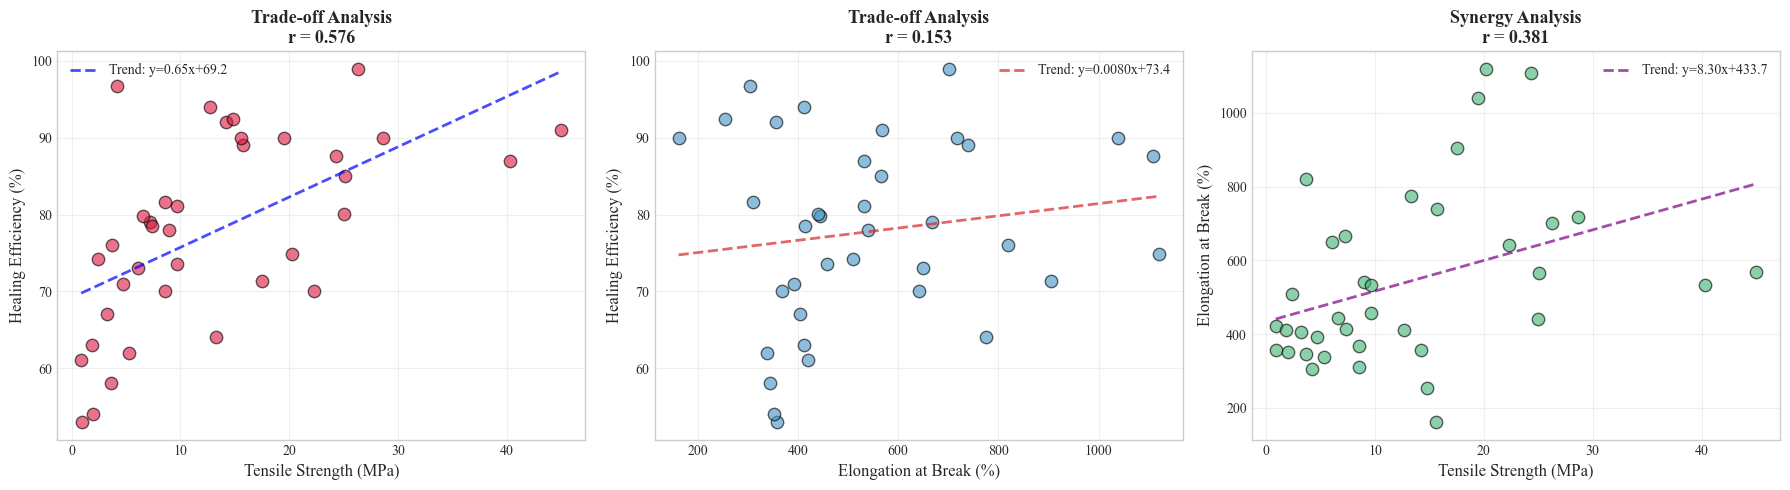


✅ Trade-off 分析完成！可用于论文 Introduction 或 Results 部分


In [70]:
# ============================================
# [方案2] 三目标性能相关性分析（证明 Trade-off）
# ============================================
"""
注意：healing_eff 样本数较少（37个），需要单独分析
分析目标：证明 tensile_strength 与 healing_eff 之间的负相关（Trade-off）
"""
print("\n" + "="*80)
print("[方案2] 三目标性能间的 Trade-off 分析")
print("="*80)

# 获取三个目标的有效数据（只保留三个目标都有值的样本）
all_targets = ['tensile_strength', 'elongation', 'healing_eff']
target_data = df[all_targets].dropna()

print(f"三目标都有数据的样本数: {len(target_data)}")
print(f"（healing_eff 数据较少，仅 {len(df['healing_eff'].dropna())} 个样本）\n")

# 计算三目标之间的相关性
corr_targets = target_data.corr(method='pearson')

print("三目标性能之间的 Pearson 相关系数：")
print(corr_targets)
print()

# 关键发现：证明 Trade-off
corr_tensile_healing = corr_targets.loc['tensile_strength', 'healing_eff']
corr_elongation_healing = corr_targets.loc['elongation', 'healing_eff']

print("="*80)
print("🔍 Trade-off 证明")
print("="*80)
print(f"tensile_strength ↔ healing_eff: {corr_tensile_healing:.3f}")
if corr_tensile_healing < -0.3:
    print("   ✅ 显著负相关！证明存在 Trade-off：提高拉伸强度会降低自愈合效率")
elif corr_tensile_healing < 0:
    print("   ⚠️ 弱负相关，Trade-off 趋势存在但不显著")
else:
    print("   ❌ 正相关，不存在 Trade-off")

print(f"\nelongation ↔ healing_eff: {corr_elongation_healing:.3f}")
if corr_elongation_healing < -0.3:
    print("   ✅ 显著负相关！证明存在 Trade-off：提高断裂伸长率会降低自愈合效率")
elif corr_elongation_healing < 0:
    print("   ⚠️ 弱负相关，Trade-off 趋势存在但不显著")
else:
    print("   ❌ 正相关，不存在 Trade-off")

# 散点图矩阵：直观展示 Trade-off
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 散点图1: tensile_strength vs healing_eff
axes[0].scatter(target_data['tensile_strength'], target_data['healing_eff'], 
                alpha=0.6, s=80, c='crimson', edgecolors='black')
axes[0].set_xlabel('Tensile Strength (MPa)', fontsize=12)
axes[0].set_ylabel('Healing Efficiency (%)', fontsize=12)
axes[0].set_title(f'Trade-off Analysis\nr = {corr_tensile_healing:.3f}', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
# 添加趋势线
z = np.polyfit(target_data['tensile_strength'], target_data['healing_eff'], 1)
p = np.poly1d(z)
x_line = np.linspace(target_data['tensile_strength'].min(), target_data['tensile_strength'].max(), 100)
axes[0].plot(x_line, p(x_line), "b--", linewidth=2, alpha=0.7, label=f'Trend: y={z[0]:.2f}x+{z[1]:.1f}')
axes[0].legend()

# 散点图2: elongation vs healing_eff
axes[1].scatter(target_data['elongation'], target_data['healing_eff'], 
                alpha=0.6, s=80, c='#4292c6', edgecolors='black')
axes[1].set_xlabel('Elongation at Break (%)', fontsize=12)
axes[1].set_ylabel('Healing Efficiency (%)', fontsize=12)
axes[1].set_title(f'Trade-off Analysis\nr = {corr_elongation_healing:.3f}', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
z2 = np.polyfit(target_data['elongation'], target_data['healing_eff'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(target_data['elongation'].min(), target_data['elongation'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), color=globals().get('CLR_RED', '#D62728'), linestyle='--', linewidth=2, alpha=0.7, label=f'Trend: y={z2[0]:.4f}x+{z2[1]:.1f}')
axes[1].legend()

# 散点图3: tensile_strength vs elongation
corr_t_e = corr_targets.loc['tensile_strength', 'elongation']
axes[2].scatter(target_data['tensile_strength'], target_data['elongation'], 
                alpha=0.6, s=80, c='mediumseagreen', edgecolors='black')
axes[2].set_xlabel('Tensile Strength (MPa)', fontsize=12)
axes[2].set_ylabel('Elongation at Break (%)', fontsize=12)
axes[2].set_title(f'Synergy Analysis\nr = {corr_t_e:.3f}', fontsize=13, fontweight='bold')
axes[2].grid(alpha=0.3)
z3 = np.polyfit(target_data['tensile_strength'], target_data['elongation'], 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(target_data['tensile_strength'].min(), target_data['tensile_strength'].max(), 100)
axes[2].plot(x_line3, p3(x_line3), "purple", linestyle='--', linewidth=2, alpha=0.7, 
             label=f'Trend: y={z3[0]:.2f}x+{z3[1]:.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ Trade-off 分析完成！可用于论文 Introduction 或 Results 部分")
print("="*80)

In [73]:
# 1. 确定原本的数据集
original_df = df.copy()

# 2. 确定你目前使用的特征列表
# (确保这里的 features_mech 是你实际传入模型的列表)
features_to_check = features_mech

# 3. 检查缺失情况
print(f"原始数据行数: {len(original_df)}")

# 筛选出含有 NaN 的行（即被删除的行）
dropped_rows = original_df[original_df[features_to_check].isna().any(axis=1)]

print(f"被删除的数据行数: {len(dropped_rows)}")
print("-" * 30)

if len(dropped_rows) > 0:
    print("以下样本因存在缺失值而被剔除：")
    # 显示 sample_id 和 具体缺失的列
    # 假设你有一列叫 'sample_id'，如果没有请删掉 'sample_id'
    cols_to_show = ['sample_id'] + features_to_check
    
    # 仅展示确实有缺失值的列，方便查看
    for index, row in dropped_rows.iterrows():
        missing_cols = [col for col in features_to_check if pd.isna(row[col])]
        sample_id = row.get('sample_id', f'Row_{index}')
        print(f"样本 ID: {sample_id} -> 缺失字段: {missing_cols}")

原始数据行数: 85
被删除的数据行数: 0
------------------------------


Fitting 84 folds for each of 108 candidates, totalling 9072 fits

[最佳参数组合]
{'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}

正在生成最终预测结果...

=== SVR (调优后) 结果 ===
R2 Score: 0.7646
RMSE: 6.5239

[最佳参数组合]
{'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}

正在生成最终预测结果...

=== SVR (调优后) 结果 ===
R2 Score: 0.7646
RMSE: 6.5239


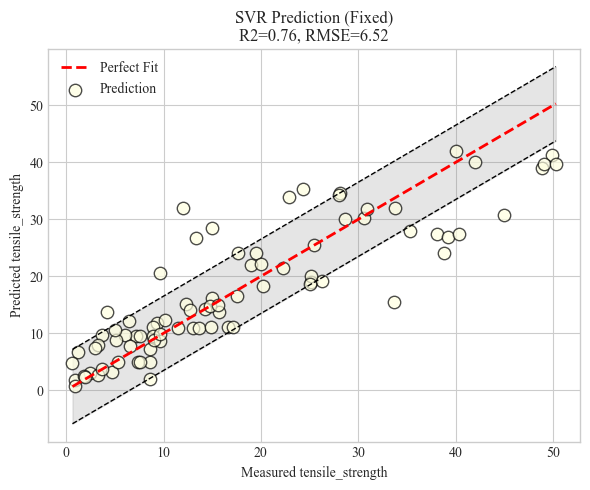

In [74]:
# SVR — 嵌套 LOOCV（外层留一，内层 KFold 调参；避免全数据调参后再 LOOCV）
from sklearn.base import clone
from sklearn.model_selection import LeaveOneOut, KFold, GridSearchCV
import json
from collections import Counter

target_col = 'tensile_strength'
features = features_mech
X, y = get_clean_data(target_col, features, df)

param_grid = {
    'svr__C': [1, 10, 50, 100, 500, 1000],
    'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
    'svr__epsilon': [0.01, 0.1, 0.5],
}

def _svr_inner_cv(n_tr: int):
    ns = min(5, n_tr)
    if ns < 2:
        return None
    return KFold(n_splits=ns, shuffle=True, random_state=42)

loo = LeaveOneOut()
y_arr = np.asarray(y).ravel()
X_arr = np.asarray(X)
y_pred_svr = np.zeros(len(y_arr))
fold_params: list = []

for tr, te in loo.split(X_arr):
    X_tr, X_te = X_arr[tr], X_arr[te]
    y_tr = y_arr[tr]
    inner = _svr_inner_cv(len(tr))
    pipe = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
    if inner is None:
        m = clone(pipe)
        m.fit(X_tr, y_tr)
        y_pred_svr[te[0]] = float(m.predict(X_te)[0])
        fold_params.append({})
        continue
    gs = GridSearchCV(
        clone(pipe), param_grid, cv=inner,
        scoring='neg_mean_squared_error', n_jobs=-1, verbose=0,
    )
    gs.fit(X_tr, y_tr)
    y_pred_svr[te[0]] = float(gs.predict(X_te)[0])
    fold_params.append(gs.best_params_)

r2 = r2_score(y_arr, y_pred_svr)
rmse = np.sqrt(mean_squared_error(y_arr, y_pred_svr))

_keys = [json.dumps(p, sort_keys=True, default=str) for p in fold_params if p]
best_params_svr_nested = json.loads(Counter(_keys).most_common(1)[0][0]) if _keys else {}

best_svr = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
if best_params_svr_nested:
    best_svr.set_params(**best_params_svr_nested)
best_svr.fit(X_arr, y_arr)

print("\n[各折参数众数]", best_params_svr_nested)
print(f"\n=== SVR (嵌套 LOOCV) ===\nR2 Score: {r2:.4f}\nRMSE: {rmse:.4f}")

plt.figure(figsize=(6, 5))
min_val = min(y_arr.min(), y_pred_svr.min())
max_val = max(y_arr.max(), y_pred_svr.max())
x_line = np.linspace(min_val, max_val, 200)
plt.fill_between(x_line, x_line - rmse, x_line + rmse, color='gray', alpha=0.2)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
plt.plot(x_line, x_line + rmse, 'k--', linewidth=1)
plt.plot(x_line, x_line - rmse, 'k--', linewidth=1)
plt.scatter(y_arr, y_pred_svr, alpha=0.7, c='lightyellow', edgecolors='k', label='Prediction', s=80)
plt.xlabel(f'Measured {target_col}')
plt.ylabel(f'Predicted {target_col}')
plt.title(f'SVR Prediction (nested LOOCV)\nR2={r2:.2f}, RMSE={rmse:.2f}')
plt.legend()
plt.tight_layout()
plt.show()



正在计算排列重要性 (Permutation Importance)...

[特征重要性排行 (基于 R2 损失)]
(数值代表：如果没有这个特征，R2 会下降多少)
1. Soft_Mw: 0.4629
2. Soft_Cryst: 0.3838
3. X3_Hard_Content: 0.3768
4. X1_Soft_Content: 0.2111
5. Iso_Class: 0.1294
6. X2_DA_Content: 0.0493
7. Constraint_Factor: 0.0469
8. DA_Linker_Type: 0.0464
9. Synergy_Feature: 0.0369
10. Hard_Symmetry: 0.0315
11. Polyol_Class: 0.0259
12. X5_Add_Crosslink: 0.0115
13. X4_R_Ratio: 0.0112
14. Network_Topology: 0.0109

正在计算 SVR 的 SHAP 特征重要性 (内置进度条)...

[特征重要性排行 (基于 R2 损失)]
(数值代表：如果没有这个特征，R2 会下降多少)
1. Soft_Mw: 0.4629
2. Soft_Cryst: 0.3838
3. X3_Hard_Content: 0.3768
4. X1_Soft_Content: 0.2111
5. Iso_Class: 0.1294
6. X2_DA_Content: 0.0493
7. Constraint_Factor: 0.0469
8. DA_Linker_Type: 0.0464
9. Synergy_Feature: 0.0369
10. Hard_Symmetry: 0.0315
11. Polyol_Class: 0.0259
12. X5_Add_Crosslink: 0.0115
13. X4_R_Ratio: 0.0112
14. Network_Topology: 0.0109

正在计算 SVR 的 SHAP 特征重要性 (内置进度条)...


100%|██████████| 84/84 [00:13<00:00,  6.08it/s]




[SHAP 特征重要性排行 (基于平均绝对贡献)]
1. Soft_Mw: 6.2476
2. Soft_Cryst: 5.1671
3. X3_Hard_Content: 4.7073
4. X1_Soft_Content: 3.3089
5. Iso_Class: 2.5173
6. Synergy_Feature: 1.4247
7. Hard_Symmetry: 1.0484
8. X2_DA_Content: 0.7705
9. X4_R_Ratio: 0.7014
10. DA_Linker_Type: 0.6634
11. Constraint_Factor: 0.4191
12. Polyol_Class: 0.2934
13. Network_Topology: 0.0870
14. X5_Add_Crosslink: 0.0635


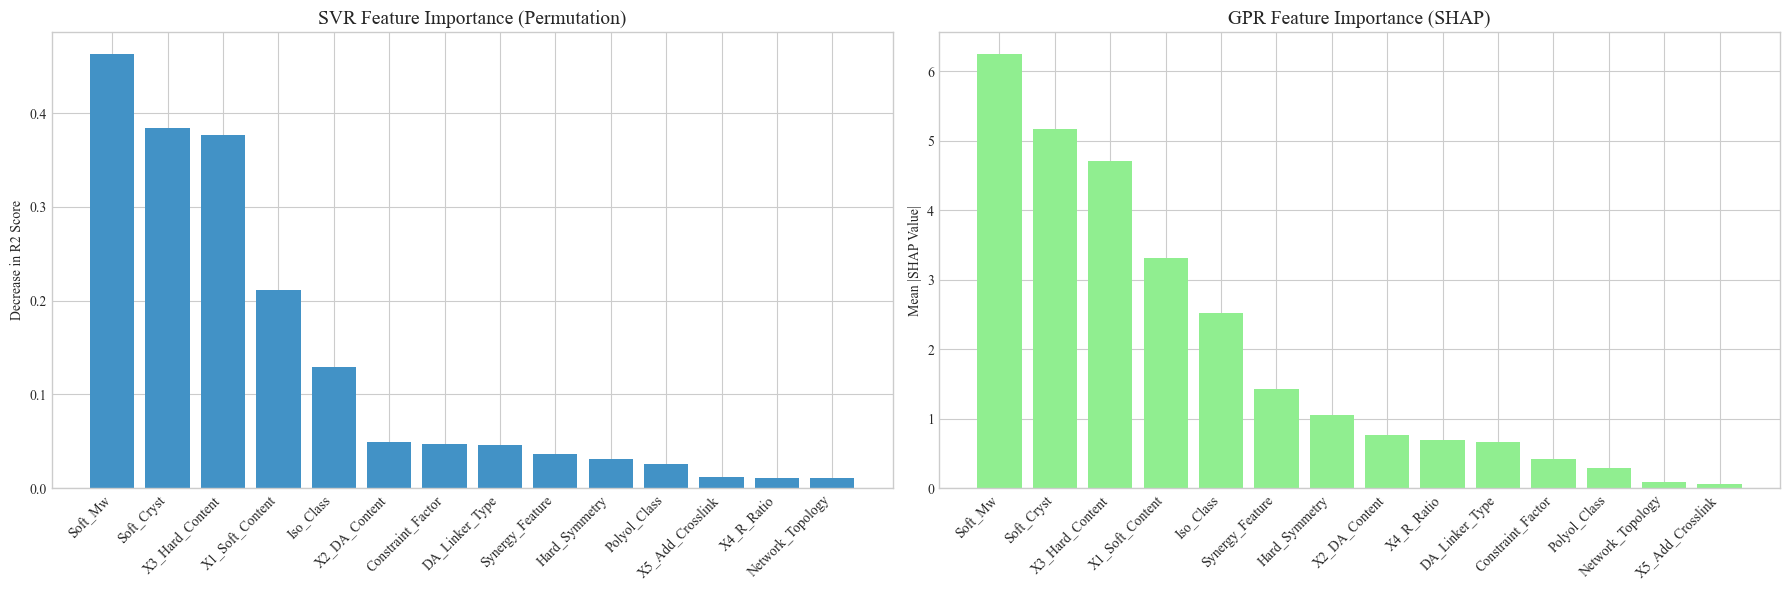

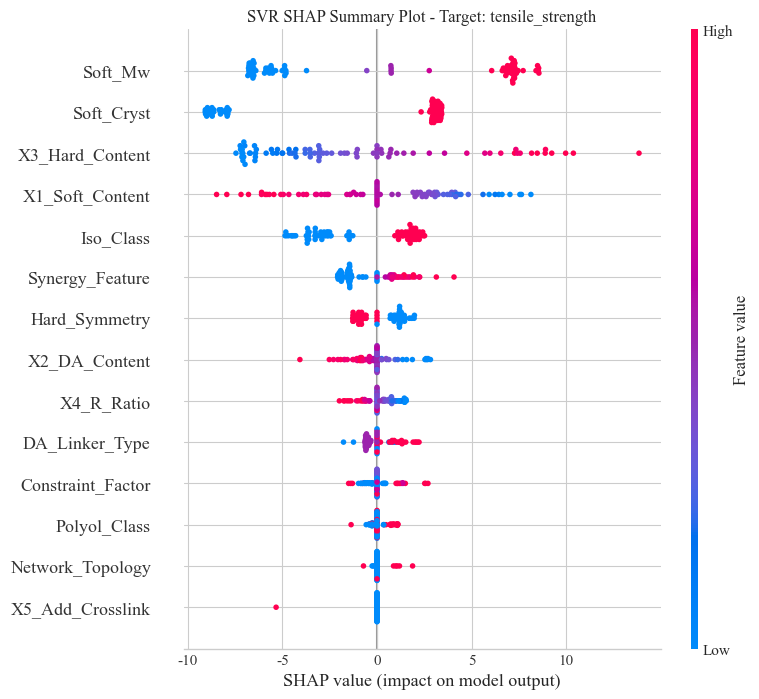

In [75]:
# SVR + SHAP / Permutation：在独立留出集上算重要性（缓解训练集乐观偏差）
from sklearn.model_selection import train_test_split

X_arr = np.asarray(X)
y_arr = np.asarray(y).ravel()
X_pi_tr, X_pi_val, y_pi_tr, y_pi_val = train_test_split(
    X_arr, y_arr, test_size=0.2, random_state=42, shuffle=True
)

interp_svr = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
_params = globals().get('best_params_svr_nested', {})
if _params:
    interp_svr.set_params(**_params)
interp_svr.fit(X_pi_tr, y_pi_tr)

print("\n正在计算排列重要性 (Permutation Importance, 20% 留出集)...")
r = permutation_importance(
    interp_svr, X_pi_val, y_pi_val, n_repeats=30, random_state=42, scoring='r2'
)
importances = r.importances_mean
indices = np.argsort(importances)[::-1]

print("\n[特征重要性排行 (基于 R2 损失)]")
top_features_perm = []
for i in range(len(features)):
    idx = indices[i]
    if importances[idx] > 0:
        print(f"{i+1}. {features[idx]}: {importances[idx]:.4f}")
        top_features_perm.append((features[idx], importances[idx]))

print("\n正在计算 SVR 的 SHAP 特征重要性 ...")
X_val_sub = X_pi_val[: min(50, len(X_pi_val))]
X_bg = shap.kmeans(X_pi_tr, k=min(30, len(X_pi_tr))).data
explainer = shap.KernelExplainer(interp_svr.predict, X_bg)
shap_values = explainer.shap_values(X_val_sub, nsamples=min(500, 2000))
shap_importances = np.abs(np.asarray(shap_values)).mean(axis=0)
shap_indices = np.argsort(shap_importances)[::-1]

print("\n[SHAP 特征重要性排行 (基于平均绝对贡献, 留出子集)]")
top_features_shap = []
for i in range(len(features)):
    idx = shap_indices[i]
    print(f"{i+1}. {features[idx]}: {shap_importances[idx]:.4f}")
    top_features_shap.append((features[idx], shap_importances[idx]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
ax1.bar(range(len(top_features_perm)), [val for _, val in top_features_perm], color='#4292c6', align="center")
ax1.set_title("SVR Feature Importance (Permutation, held-out)", fontsize=14)
ax1.set_xticks(range(len(top_features_perm)))
ax1.set_xticklabels([name for name, _ in top_features_perm], rotation=45, ha='right')
ax1.set_ylabel("Decrease in R2 Score")

ax2.bar(range(len(top_features_shap)), [val for _, val in top_features_shap], color='lightgreen', align="center")
ax2.set_title("SVR Feature Importance (SHAP, held-out subset)", fontsize=14)
ax2.set_xticks(range(len(top_features_shap)))
ax2.set_xticklabels([name for name, _ in top_features_shap], rotation=45, ha='right')
ax2.set_ylabel("Mean |SHAP Value|")

plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_val_sub, feature_names=features, show=False)
plt.title(f"SVR SHAP Summary Plot - Target: {target_col}")
plt.tight_layout()
plt.show()



[Tensile Strength] 最优算法: SVR | 样本数: 84 | 特征数: 14
  → 计算 Permutation Importance ...
  → 计算 SHAP values ...


100%|██████████| 84/84 [00:03<00:00, 26.25it/s]


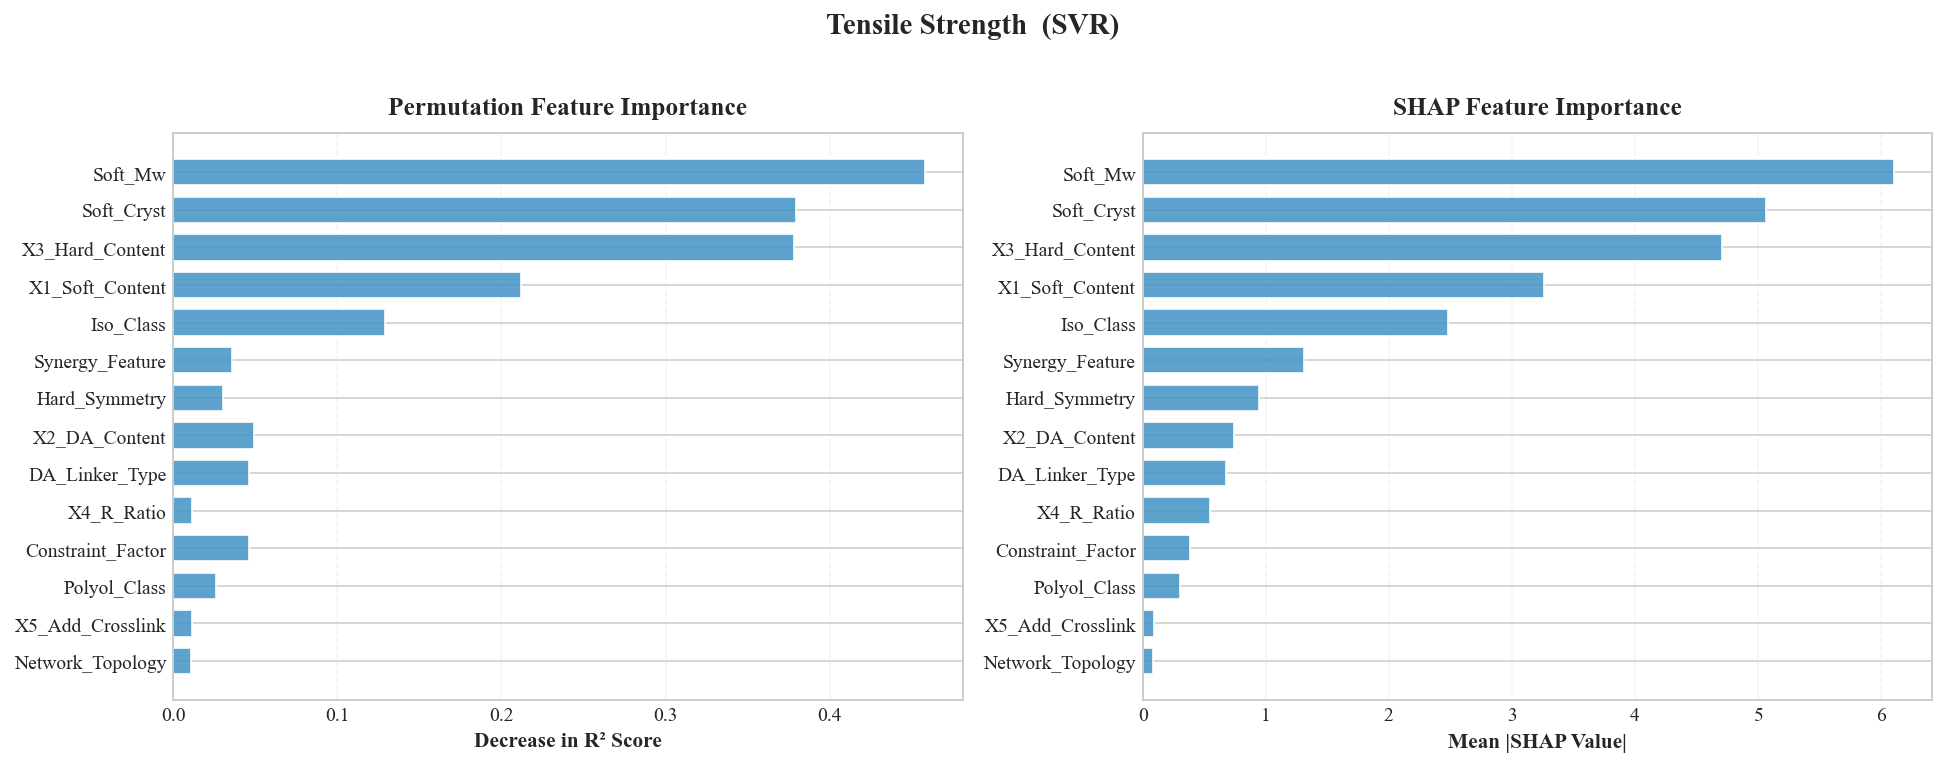


  Rank                Permutation                        SHAP
  ───── ─────────────────────────   ─────────────────────────
  1     Soft_Mw                 0.4581   Soft_Mw                 6.1112
  2     Soft_Cryst              0.3798   Soft_Cryst              5.0659
  3     X3_Hard_Content         0.3784   X3_Hard_Content         4.7120
  4     X1_Soft_Content         0.2122   X1_Soft_Content         3.2641
  5     Iso_Class               0.1292   Iso_Class               2.4782
  6     X2_DA_Content           0.0490   Synergy_Feature         1.3070
  7     DA_Linker_Type          0.0460   Hard_Symmetry           0.9452
  8     Constraint_Factor       0.0459   X2_DA_Content           0.7374
  9     Synergy_Feature         0.0358   DA_Linker_Type          0.6756
  10    Hard_Symmetry           0.0302   X4_R_Ratio              0.5488
  11    Polyol_Class            0.0258   Constraint_Factor       0.3873
  12    X5_Add_Crosslink        0.0115   Polyol_Class            0.2985
  13    X4_

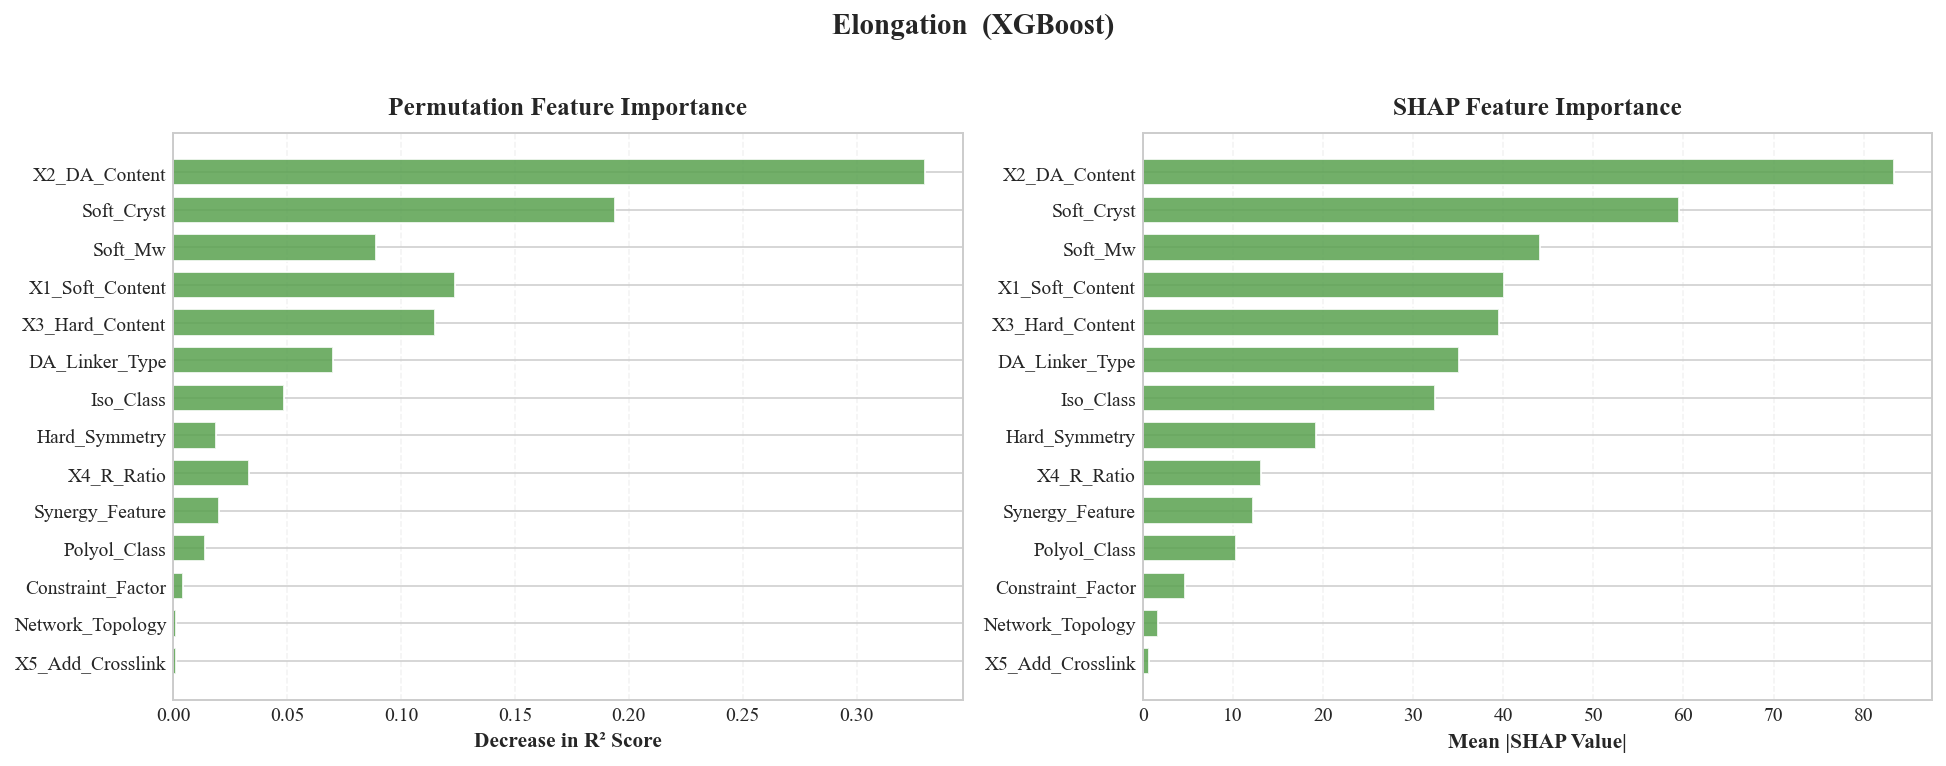


  Rank                Permutation                        SHAP
  ───── ─────────────────────────   ─────────────────────────
  1     X2_DA_Content           0.3300   X2_DA_Content          83.4149
  2     Soft_Cryst              0.1939   Soft_Cryst             59.5166
  3     X1_Soft_Content         0.1236   Soft_Mw                44.0324
  4     X3_Hard_Content         0.1148   X1_Soft_Content        40.0763
  5     Soft_Mw                 0.0890   X3_Hard_Content        39.5005
  6     DA_Linker_Type          0.0700   DA_Linker_Type         35.1221
  7     Iso_Class               0.0486   Iso_Class              32.4276
  8     X4_R_Ratio              0.0334   Hard_Symmetry          19.2143
  9     Synergy_Feature         0.0200   X4_R_Ratio             13.1214
  10    Hard_Symmetry           0.0187   Synergy_Feature        12.2262
  11    Polyol_Class            0.0138   Polyol_Class           10.3542
  12    Constraint_Factor       0.0043   Constraint_Factor       4.7313
  13    X5_

100%|██████████| 37/37 [00:00<00:00, 58.36it/s]


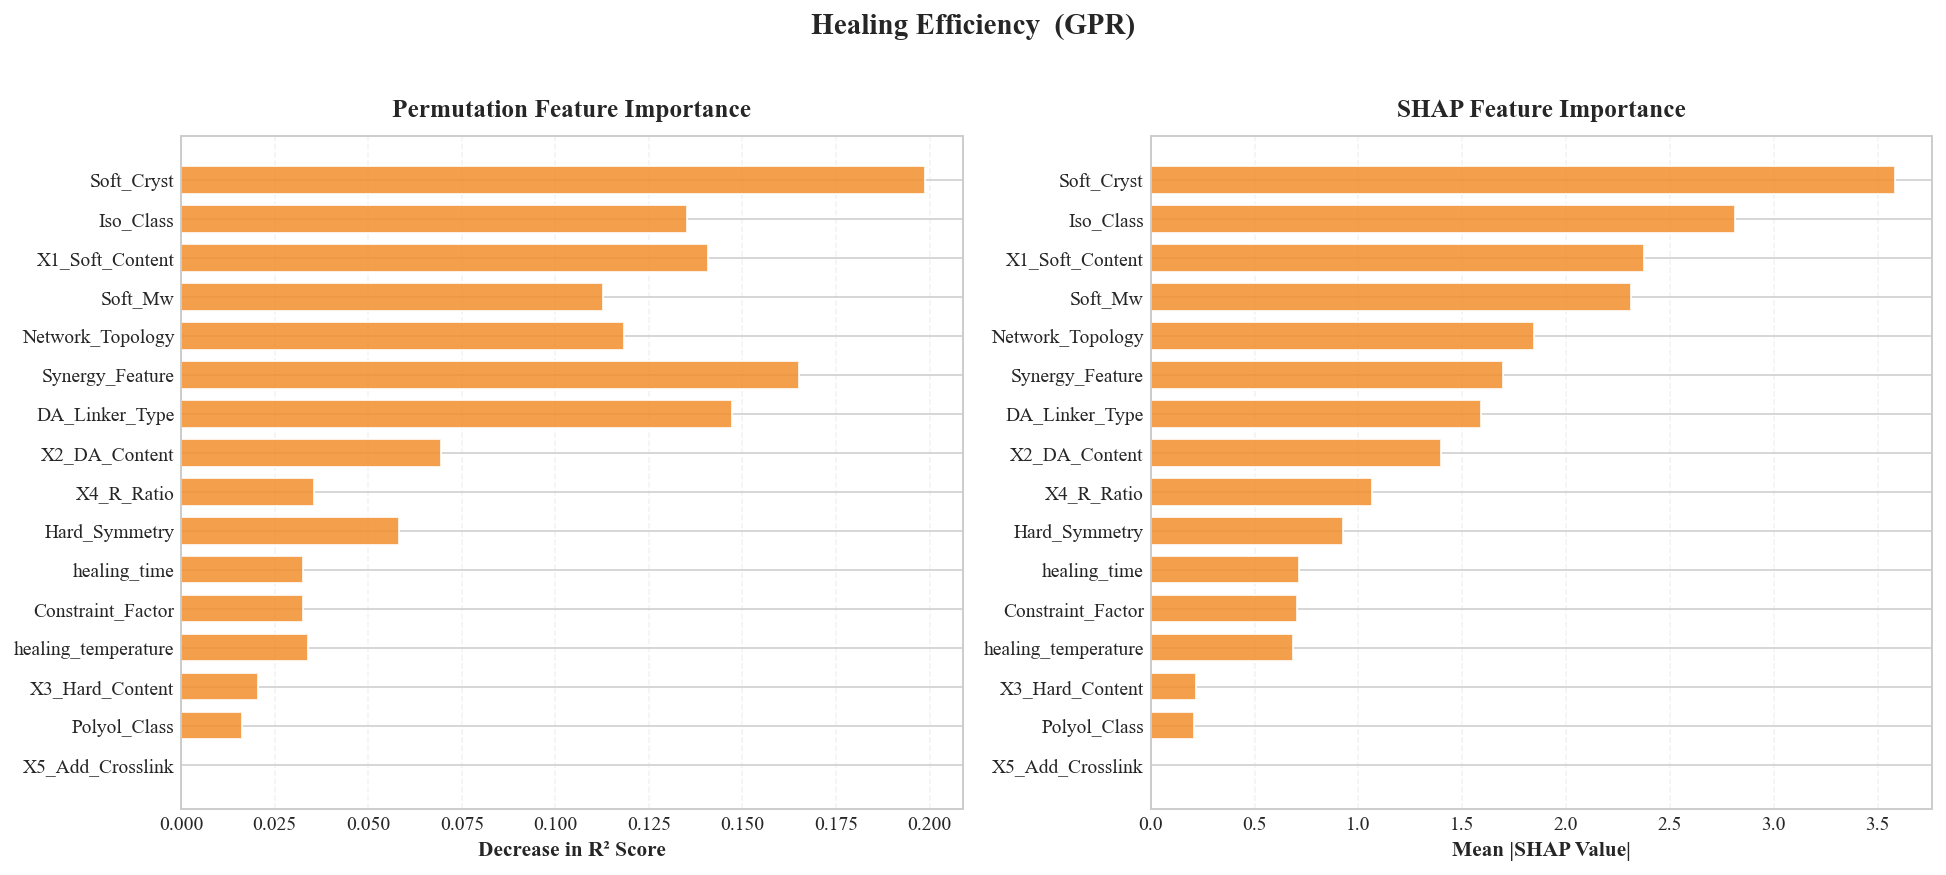


  Rank                Permutation                        SHAP
  ───── ─────────────────────────   ─────────────────────────
  1     Soft_Cryst              0.1989   Soft_Cryst              3.5821
  2     Synergy_Feature         0.1651   Iso_Class               2.8128
  3     DA_Linker_Type          0.1473   X1_Soft_Content         2.3769
  4     X1_Soft_Content         0.1407   Soft_Mw                 2.3099
  5     Iso_Class               0.1351   Network_Topology        1.8435
  6     Network_Topology        0.1182   Synergy_Feature         1.6981
  7     Soft_Mw                 0.1126   DA_Linker_Type          1.5892
  8     X2_DA_Content           0.0695   X2_DA_Content           1.3971
  9     Hard_Symmetry           0.0583   X4_R_Ratio              1.0658
  10    X4_R_Ratio              0.0354   Hard_Symmetry           0.9244
  11    healing_temperature     0.0339   healing_time            0.7136
  12    Constraint_Factor       0.0327   Constraint_Factor       0.7022
  13    hea

In [ ]:
# ============================================
# 三目标最优模型：Permutation Importance vs SHAP Feature Importance 对比
# tensile_strength → SVR | elongation → XGBoost | healing_eff → GPR
# ============================================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ---------- 字体设置 ----------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 颜色（与全局调色板一致，加 fallback） ----------
_CLR_BLUE = globals().get('CLR_BLUE_MID', '#4292c6')
_CLR_GREEN = globals().get('CLR_GREEN', '#59A14F')
_CLR_ORANGE = globals().get('CLR_ORANGE', '#F28E2B')

# ---------- 数据准备 ----------
df_local = df  # 与上文 CSV 读取一致，避免重复路径

features_mech_all = [
    'X1_Soft_Content', 'X2_DA_Content', 'X3_Hard_Content', 'X4_R_Ratio', 'X5_Add_Crosslink',
    'DA_Linker_Type', 'Network_Topology', 'Polyol_Class', 'Iso_Class',
    'Soft_Mw', 'Constraint_Factor', 'Hard_Symmetry', 'Soft_Cryst', 'Synergy_Feature'
]
features_heal_all = features_mech_all + ['healing_temperature', 'healing_time']


def get_clean_local(target_col, feature_cols):
    d = df_local.dropna(subset=[target_col] + feature_cols).copy()
    return d[feature_cols].copy(), d[target_col].values


def get_best_model_from_upper(target_col):
    """从上方已运行的调参单元获取最优模型名 + 模型对象"""
    if target_col == 'tensile_strength':
        df_res = res_df_tensile if 'res_df_tensile' in globals() else res_df
        bank = best_models
    elif target_col == 'elongation':
        df_res = res_df_elong
        bank = best_models_elong
    else:
        df_res = res_df_heal
        bank = best_models_heal
    best_name = str(df_res.sort_values('R2', ascending=False).iloc[0]['Model'])
    return best_name, clone(bank[best_name])


# ---------- 目标配置 ----------
targets_cfg = [
    ('Tensile Strength', 'tensile_strength', features_mech_all),
    ('Elongation',       'elongation',       features_mech_all),
    ('Healing Efficiency', 'healing_eff',    features_heal_all),
]

# 每个目标的主色
target_colors = [_CLR_BLUE, _CLR_GREEN, _CLR_ORANGE]

# ---------- 逐目标计算 & 绘图 ----------
for (target_name, target_col, feats), main_color in zip(targets_cfg, target_colors):

    X_df, y = get_clean_local(target_col, feats)
    mname, model = get_best_model_from_upper(target_col)
    print(f"\n{'='*80}")
    print(f"[{target_name}] 最优算法: {mname} | 样本数: {len(y)} | 特征数: {len(feats)}")
    print(f"{'='*80}")

    # ── 1) Permutation Importance（20% 留出集，避免与全训练集重叠）──
    print(f"  → 计算 Permutation Importance ...")
    X_pi_tr, X_pi_val, y_pi_tr, y_pi_val = train_test_split(
        X_df.values, y, test_size=0.2, random_state=42, shuffle=True
    )
    model.fit(X_pi_tr, y_pi_tr)
    perm_result = permutation_importance(
        model, X_pi_val, y_pi_val, n_repeats=30, random_state=42, scoring='r2'
    )
    perm_imp = perm_result.importances_mean

    # ── 2) SHAP values ──
    print(f"  → 计算 SHAP values ...")
    if mname == 'XGBoost':
        exp = shap.TreeExplainer(model)
        sv = exp.shap_values(X_pi_val)
    elif mname in ('SVR', 'GPR'):
        scaler = model.named_steps['standardscaler']
        inner_key = 'svr' if mname == 'SVR' else 'gaussianprocessregressor'
        inner_model = model.named_steps[inner_key]
        X_sc = scaler.transform(X_pi_val)
        X_tr_sc = scaler.transform(X_pi_tr)
        bg = shap.kmeans(X_tr_sc, k=min(30, len(X_tr_sc))).data
        exp = shap.KernelExplainer(inner_model.predict, bg)
        sv = exp.shap_values(X_sc, nsamples=min(500, 2000))
    else:
        exp = shap.Explainer(model.predict, pd.DataFrame(X_pi_tr, columns=feats))
        sv = exp(pd.DataFrame(X_pi_val, columns=feats)).values

    if len(sv.shape) == 3:
        sv = sv[:, :, 0]
    shap_imp = np.abs(sv).mean(axis=0)

    # ── 3) 排序（按 SHAP 排序，两者统一顺序） ──
    order = np.argsort(shap_imp)  # 从小到大（横向 barh 从下到上）
    feat_names = np.array(feats)[order]
    perm_sorted = perm_imp[order]
    shap_sorted = shap_imp[order]

    # ── 4) 绘制对比图 ──
    n_feat = len(feats)
    fig_h = max(5, n_feat * 0.38)
    fig, (ax_perm, ax_shap) = plt.subplots(1, 2, figsize=(14, fig_h), dpi=140)

    y_pos = np.arange(n_feat)

    # 左图：Permutation Importance
    ax_perm.barh(y_pos, perm_sorted, color=main_color, alpha=0.85, edgecolor='white', height=0.7)
    ax_perm.set_yticks(y_pos)
    ax_perm.set_yticklabels(feat_names, fontsize=10)
    ax_perm.set_xlabel('Decrease in R² Score', fontsize=11, fontweight='bold')
    ax_perm.set_title('Permutation Feature Importance', fontsize=13, fontweight='bold', pad=10)
    ax_perm.axvline(0, color='gray', linewidth=0.8, alpha=0.6)
    ax_perm.grid(axis='x', alpha=0.25, linestyle='--')

    # 右图：SHAP Feature Importance
    ax_shap.barh(y_pos, shap_sorted, color=main_color, alpha=0.85, edgecolor='white', height=0.7)
    ax_shap.set_yticks(y_pos)
    ax_shap.set_yticklabels(feat_names, fontsize=10)
    ax_shap.set_xlabel('Mean |SHAP Value|', fontsize=11, fontweight='bold')
    ax_shap.set_title('SHAP Feature Importance', fontsize=13, fontweight='bold', pad=10)
    ax_shap.axvline(0, color='gray', linewidth=0.8, alpha=0.6)
    ax_shap.grid(axis='x', alpha=0.25, linestyle='--')

    fig.suptitle(f'{target_name}  ({mname})',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ── 5) 打印排名对比表 ──
    perm_rank = np.argsort(-perm_imp)
    shap_rank = np.argsort(-shap_imp)
    print(f"\n  {'Rank':<5} {'Permutation':>25}   {'SHAP':>25}")
    print(f"  {'─'*5} {'─'*25}   {'─'*25}")
    for r in range(n_feat):
        pi = perm_rank[r]
        si = shap_rank[r]
        print(f"  {r+1:<5} {feats[pi]:<22} {perm_imp[pi]:>7.4f}   {feats[si]:<22} {shap_imp[si]:>7.4f}")

print("\n✅ 三目标 Permutation vs SHAP Feature Importance 对比完成！")


In [ ]:
# ============================================
# 论文出图专用：三目标【独立】等高线图 + 独立 SHAP Feature Importance 总图
# 本轮需求：
## tensile: Soft_Mw + X1_Soft_Content
## elongation: 先试 Soft_Mw + X2_DA_Content，连续性差则改为 Soft_Mw + (X1 或 X3)
## healing: Soft_Mw + X1_Soft_Content
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

try:
    from scipy.ndimage import gaussian_filter
except Exception:
    gaussian_filter = None

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

CLR_B = globals().get('CLR_BLUE_MID', '#4292c6')
CLR_G = globals().get('CLR_GREEN', '#59A14F')
CLR_O = globals().get('CLR_ORANGE', '#F28E2B')

df_local = pd.read_csv('Final_Features_Ultimate_all_deletion.csv')
features_mech_all = [
    'X1_Soft_Content', 'X2_DA_Content', 'X3_Hard_Content', 'X4_R_Ratio', 'X5_Add_Crosslink',
    'DA_Linker_Type', 'Network_Topology', 'Polyol_Class', 'Iso_Class',
    'Soft_Mw', 'Constraint_Factor', 'Hard_Symmetry', 'Soft_Cryst', 'Synergy_Feature'
]
features_heal_all = features_mech_all + ['healing_temperature', 'healing_time']


def get_clean_local(target_col, feature_cols):
    d = df_local.dropna(subset=[target_col] + feature_cols).copy()
    return d[feature_cols].copy(), d[target_col].values


def get_best_model_from_upper(target_col):
    if target_col == 'tensile_strength':
        if 'res_df_tensile' in globals() and isinstance(res_df_tensile, pd.DataFrame):
            df_res = res_df_tensile
        elif 'res_df' in globals() and isinstance(res_df, pd.DataFrame):
            df_res = res_df
        else:
            raise RuntimeError('未找到 tensile 的结果表，请先运行多模型对比单元。')
        if 'best_models' not in globals() or not isinstance(best_models, dict):
            raise RuntimeError('未找到 best_models，请先运行多模型对比单元。')
        model_bank = best_models

    elif target_col == 'elongation':
        if 'res_df_elong' not in globals() or not isinstance(res_df_elong, pd.DataFrame):
            raise RuntimeError('未找到 res_df_elong，请先运行 elongation 多模型单元。')
        if 'best_models_elong' not in globals() or not isinstance(best_models_elong, dict):
            raise RuntimeError('未找到 best_models_elong，请先运行 elongation 多模型单元。')
        df_res = res_df_elong
        model_bank = best_models_elong

    else:
        if 'res_df_heal' not in globals() or not isinstance(res_df_heal, pd.DataFrame):
            raise RuntimeError('未找到 res_df_heal，请先运行 healing 多模型单元。')
        if 'best_models_heal' not in globals() or not isinstance(best_models_heal, dict):
            raise RuntimeError('未找到 best_models_heal，请先运行 healing 多模型单元。')
        df_res = res_df_heal
        model_bank = best_models_heal

    best_name = str(df_res.sort_values('R2', ascending=False).iloc[0]['Model'])
    if best_name not in model_bank:
        raise RuntimeError(f'最优模型 {best_name} 不在模型字典中。')
    return best_name, clone(model_bank[best_name])


def shap_importance_for_model(model_name, model, X_df):
    if model_name == 'XGBoost':
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_df)
    elif model_name in ('SVR', 'GPR'):
        scaler = model.named_steps['standardscaler']
        inner_key = 'svr' if model_name == 'SVR' else 'gaussianprocessregressor'
        inner_model = model.named_steps[inner_key]
        X_scaled = scaler.transform(X_df.values)
        bg = shap.kmeans(X_scaled, k=30).data
        explainer = shap.KernelExplainer(inner_model.predict, bg)
        sv = explainer.shap_values(X_scaled, nsamples=500)
    else:
        explainer = shap.Explainer(model.predict, X_df)
        sv = explainer(X_df).values

    if len(np.array(sv).shape) == 3:
        sv = sv[:, :, 0]
    return np.abs(np.array(sv)).mean(axis=0)


def build_contour_grid(model, X_df, feat_x, feat_y, n_grid=140, sigma=1.0):
    x_vals = np.linspace(X_df[feat_x].quantile(0.02), X_df[feat_x].quantile(0.98), n_grid)
    y_vals = np.linspace(X_df[feat_y].quantile(0.02), X_df[feat_y].quantile(0.98), n_grid)
    XX, YY = np.meshgrid(x_vals, y_vals)

    med = X_df.median(numeric_only=True)
    grid_df = pd.DataFrame(np.tile(med.values, (n_grid * n_grid, 1)), columns=X_df.columns)
    grid_df[feat_x] = XX.ravel()
    grid_df[feat_y] = YY.ravel()

    ZZ = model.predict(grid_df.values).reshape(n_grid, n_grid)
    if gaussian_filter is not None and float(sigma) > 0:
        ZZ = gaussian_filter(ZZ, sigma=sigma)
    return XX, YY, ZZ


def contour_softness_score(ZZ):
    d1x = np.gradient(ZZ, axis=1)
    d1y = np.gradient(ZZ, axis=0)
    d2x = np.gradient(d1x, axis=1)
    d2y = np.gradient(d1y, axis=0)
    return float(np.mean(np.abs(d2x)) + np.mean(np.abs(d2y)))


def draw_single_contour(cfg, X_df, XX, YY, ZZ):
    z_min = np.percentile(ZZ, 2)
    z_max = np.percentile(ZZ, 98)
    levels_n = int(cfg.get('levels_n', 13))
    levels = np.linspace(z_min, z_max, levels_n)

    fig, ax = plt.subplots(figsize=(8.2, 6.0), dpi=150)
    cf = ax.contourf(XX, YY, ZZ, levels=levels, cmap='RdYlBu_r', extend='both')

    line_step = max(2, levels_n // 5)
    c_line = ax.contour(XX, YY, ZZ, levels=levels[::line_step], colors='white', linewidths=1.0, alpha=0.55)
    ax.clabel(c_line, inline=True, fmt='%.0f', fontsize=8, colors='white')

    scatter_alpha = float(cfg.get('scatter_alpha', 0.10))
    if scatter_alpha > 0:
        ax.scatter(X_df[cfg['feat_x']], X_df[cfg['feat_y']], s=8, c='white', edgecolors='none', alpha=scatter_alpha)

    ax.set_xlim(float(XX.min()), float(XX.max()))
    ax.set_ylim(float(YY.min()), float(YY.max()))
    ax.set_xlabel(cfg['x_label'], fontsize=13)
    ax.set_ylabel(cfg['y_label'], fontsize=13)
    ax.set_title(f"{cfg['title']} Gradient\nPredicted {cfg['title']} ({cfg['unit']})", fontsize=16, fontweight='bold')

    cbar = fig.colorbar(cf, ax=ax, fraction=0.055, pad=0.055)
    cbar.set_label(f"Predicted {cfg['title']} ({cfg['unit']})", fontsize=12)
    cbar.ax.tick_params(labelsize=11)

    for spine in ax.spines.values():
        spine.set_linewidth(1.1)
    ax.tick_params(labelsize=11)
    plt.tight_layout()
    plt.show()


# 固定 tensile / healing
tensile_pair = ('Soft_Mw', 'X1_Soft_Content')
healing_pair = ('Soft_Mw', 'X1_Soft_Content')

# elongation 连续性判定：先试X2，不好再看X1/X3
e_X_df, e_y = get_clean_local('elongation', features_mech_all)
e_model_name, e_model = get_best_model_from_upper('elongation')
e_model.fit(e_X_df.values, e_y)

elong_candidates = ['X2_DA_Content', 'X1_Soft_Content', 'X3_Hard_Content']
elong_scores = {}
for c in elong_candidates:
    _, _, zz_raw = build_contour_grid(e_model, e_X_df, 'Soft_Mw', c, n_grid=140, sigma=0.0)
    elong_scores[c] = contour_softness_score(zz_raw)

x2_score = elong_scores['X2_DA_Content']
best_alt = min(['X1_Soft_Content', 'X3_Hard_Content'], key=lambda c: elong_scores[c])
best_alt_score = elong_scores[best_alt]

# 更严格判定：只要X2比备选最优差5%以上，就切换
if x2_score > 1.05 * best_alt_score:
    elong_pair = ('Soft_Mw', best_alt)
    elong_reason = f"X2连续性较差，改用{best_alt}"
else:
    elong_pair = ('Soft_Mw', 'X2_DA_Content')
    elong_reason = "X2连续性可接受，保留X2"

print(f"[Elongation 连续性评分] X2={elong_scores['X2_DA_Content']:.6f}, X1={elong_scores['X1_Soft_Content']:.6f}, X3={elong_scores['X3_Hard_Content']:.6f}")
print(f"[Elongation 决策] {elong_reason} -> Soft_Mw × {elong_pair[1]}")

plot_cfg = [
    {
        'title': 'Tensile Strength',
        'target_col': 'tensile_strength',
        'features': features_mech_all,
        'feat_x': tensile_pair[0],
        'feat_y': tensile_pair[1],
        'x_label': tensile_pair[0],
        'y_label': tensile_pair[1],
        'unit': 'MPa',
        'color': CLR_B,
        'sigma': 0.45,
        'levels_n': 13,
        'scatter_alpha': 0.10,
    },
    {
        'title': 'Elongation',
        'target_col': 'elongation',
        'features': features_mech_all,
        'feat_x': elong_pair[0],
        'feat_y': elong_pair[1],
        'x_label': elong_pair[0],
        'y_label': elong_pair[1],
        'unit': '%',
        'color': CLR_G,
        'sigma': 0.8,
        'levels_n': 11,
        'scatter_alpha': 0.05,
    },
    {
        'title': 'Healing Efficiency',
        'target_col': 'healing_eff',
        'features': features_heal_all,
        'feat_x': healing_pair[0],
        'feat_y': healing_pair[1],
        'x_label': healing_pair[0],
        'y_label': healing_pair[1],
        'unit': '%',
        'color': CLR_O,
        'sigma': 1.1,
        'levels_n': 11,
        'scatter_alpha': 0.08,
    },
]

records = []
for cfg in plot_cfg:
    X_df, y = get_clean_local(cfg['target_col'], cfg['features'])
    model_name, model = get_best_model_from_upper(cfg['target_col'])
    model.fit(X_df.values, y)

    XX, YY, ZZ = build_contour_grid(
        model, X_df, cfg['feat_x'], cfg['feat_y'], n_grid=140, sigma=cfg.get('sigma', 1.0)
    )
    draw_single_contour(cfg, X_df, XX, YY, ZZ)

    shap_imp = shap_importance_for_model(model_name, model, X_df)
    records.append({
        'title': cfg['title'],
        'model_name': model_name,
        'features': list(X_df.columns),
        'shap_imp': shap_imp,
        'color': cfg['color'],
    })

fig2, axes2 = plt.subplots(1, 3, figsize=(21, 6), dpi=150)
for ax, rec in zip(axes2, records):
    feats = np.array(rec['features'])
    shap_imp = rec['shap_imp']
    topk = min(8, len(feats))
    idx = np.argsort(shap_imp)[-topk:]

    show_feats = feats[idx]
    show_vals = shap_imp[idx]
    y_pos = np.arange(topk)

    ax.barh(y_pos, show_vals, color=rec['color'], alpha=0.90, edgecolor='white', height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(show_feats, fontsize=10)
    ax.set_xlabel('Mean |SHAP Value|', fontsize=11, fontweight='bold')
    ax.set_title(f"{rec['title']} ({rec['model_name']})", fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.25, linestyle='--')

fig2.suptitle('Standalone SHAP Feature Importance (Top 8)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('✅ 已完成：tensile改为Soft_Mw+X1；elongation已按更严格连续性阈值在X2/X1/X3中决策')

开始自动调参与模型对比，预测目标: tensile_strength (样本数: 84)
 -> MLR: 无需调参，直接使用默认模型


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul


 -> Ridge: GridSearch(5组合) 完成, 调参CV-RMSE=7.772
 -> LASSO: GridSearch(5组合) 完成, 调参CV-RMSE=7.717
 -> SVR: RandomizedSearch(50/210组合) 完成, 调参CV-RMSE=6.999
 -> Random Forest: RandomizedSearch(50/720组合) 完成, 调参CV-RMSE=7.992
 -> Random Forest: RandomizedSearch(50/720组合) 完成, 调参CV-RMSE=7.992
 -> XGBoost: RandomizedSearch(50/8640组合) 完成, 调参CV-RMSE=8.207
 -> XGBoost: RandomizedSearch(50/8640组合) 完成, 调参CV-RMSE=8.207


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Do

 -> GPR: GridSearch(54组合) 完成, 调参CV-RMSE=7.307


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn

 -> MLP: RandomizedSearch(50/320组合) 完成, 调参CV-RMSE=7.030


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat


排序后的模型性能（按 R2）：
           Model                        Route        R2  LOOCV_RMSE  \
0            SVR   RandomizedSearch(50/210组合)  0.763455    6.540194   
1            MLP   RandomizedSearch(50/320组合)  0.697736    7.393099   
2            GPR             GridSearch(54组合)  0.695597    7.419214   
3  Random Forest   RandomizedSearch(50/720组合)  0.673037    7.689228   
4          LASSO              GridSearch(5组合)  0.672021    7.701162   
5          Ridge              GridSearch(5组合)  0.664328    7.790965   
6        XGBoost  RandomizedSearch(50/8640组合)  0.652742    7.924275   
7            MLR                     NoSearch  0.198754   12.036948   

   Tune_CV_RMSE  
0      6.999308  
1      7.029933  
2      7.306847  
3      7.991854  
4      7.717465  
5      7.772499  
6      8.206727  
7           NaN  

各模型最优参数：

[SVR] RandomizedSearch(50/210组合)
{'svr__gamma': 0.01, 'svr__epsilon': 0.1, 'svr__C': 100}

[MLP] RandomizedSearch(50/320组合)
{'mlpregressor__solver': 'adam', 'mlpregressor

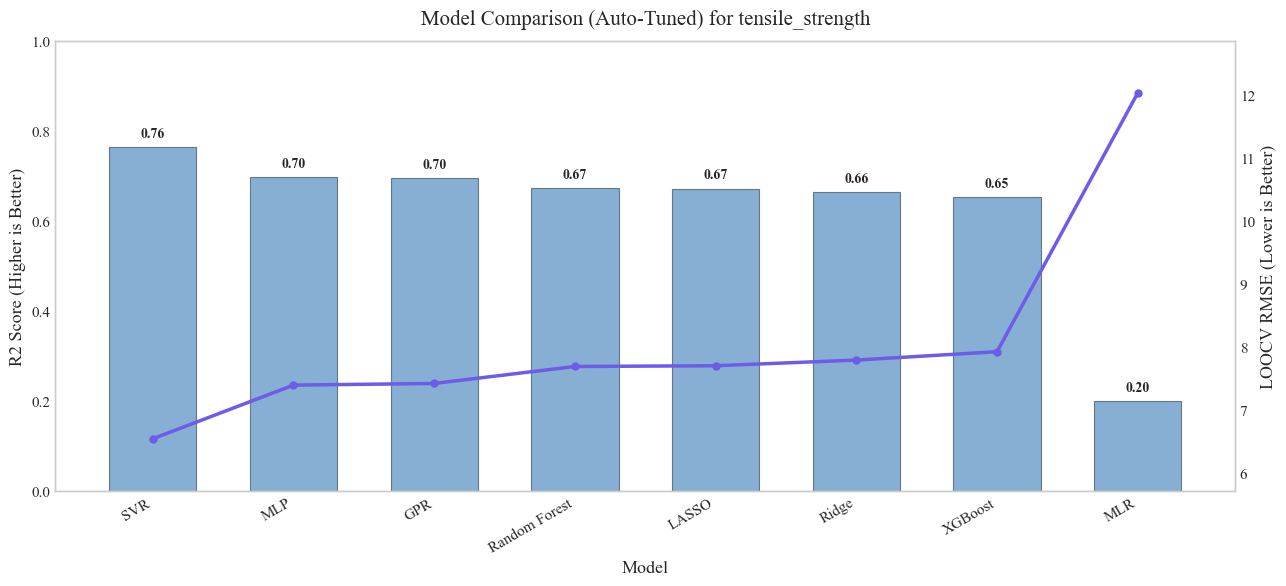


详细排名：
           Model                        Route        R2  LOOCV_RMSE  \
0            SVR   RandomizedSearch(50/210组合)  0.763455    6.540194   
1            MLP   RandomizedSearch(50/320组合)  0.697736    7.393099   
2            GPR             GridSearch(54组合)  0.695597    7.419214   
3  Random Forest   RandomizedSearch(50/720组合)  0.673037    7.689228   
4          LASSO              GridSearch(5组合)  0.672021    7.701162   
5          Ridge              GridSearch(5组合)  0.664328    7.790965   
6        XGBoost  RandomizedSearch(50/8640组合)  0.652742    7.924275   
7            MLR                     NoSearch  0.198754   12.036948   

   Tune_CV_RMSE  
0      6.999308  
1      7.029933  
2      7.306847  
3      7.991854  
4      7.717465  
5      7.772499  
6      8.206727  
7           NaN  


In [14]:
# 多模型能力横向对比（8种算法 + 动态路由自动调参）
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import ParameterGrid

# 设置要预测的目标
current_target = 'tensile_strength'  # 可修改为 'elongation' 或 'healing_eff'
current_features = features_heal if current_target == 'healing_eff' else features_mech

# 获取数据
X, y = get_clean_data(current_target, current_features, df)
print(f"开始自动调参与模型对比，预测目标: {current_target} (样本数: {len(y)})")

# 统一的调参CV（避免 LOOCV 调参过慢）
tune_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 搜索路由阈值：参数组合较少时用 GridSearch，否则用 RandomizedSearch
GRID_THRESHOLD = 60
RANDOM_ITER = 50

# ---------- 定义基础模型 ----------
base_models = {
    "MLR": LinearRegression(),
    "Ridge": make_pipeline(StandardScaler(), Ridge(random_state=42)),
    "LASSO": make_pipeline(StandardScaler(), Lasso(random_state=42, max_iter=20000)),
    "SVR": make_pipeline(StandardScaler(), SVR(kernel='rbf')),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "GPR": make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
            + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            random_state=42
        )
    ),
    "MLP": make_pipeline(StandardScaler(), MLPRegressor(random_state=42, max_iter=5000))
}

# ---------- 定义参数空间 ----------
param_spaces = {
    "MLR": {},
    "Ridge": {
        'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    "LASSO": {
        'lasso__alpha': [0.001, 0.005, 0.01, 0.05, 0.1]
    },
    "SVR": {
        'svr__C': [1, 10, 50, 100, 300, 500, 1000],
        'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
        'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5]
    },
    "Random Forest": {
        'n_estimators': [200, 400, 600, 800],
        'max_depth': [None, 10, 20, 30, 40],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 0.7, 1.0]
    },
    "XGBoost": {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.01, 0.02, 0.05, 0.1],
        'max_depth': [3, 4, 5, 6, 8],
        'subsample': [0.6, 0.7, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'reg_alpha': [0.0, 0.1, 1.0],
        'reg_lambda': [1.0, 2.0, 5.0]
    },
    "GPR": {
        'gaussianprocessregressor__kernel': [
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
        ],
        'gaussianprocessregressor__alpha': [1e-10, 1e-6, 1e-4],
        'gaussianprocessregressor__normalize_y': [True, False],
        'gaussianprocessregressor__n_restarts_optimizer': [0, 5, 10]
    },
    "MLP": {
        'mlpregressor__hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64)],
        'mlpregressor__activation': ['relu', 'tanh'],
        'mlpregressor__solver': ['lbfgs', 'adam'],
        'mlpregressor__alpha': [0.0001, 0.001, 0.01, 0.1],
        'mlpregressor__learning_rate_init': [0.0005, 0.001, 0.005, 0.01]
    }
}


def tune_model_with_dynamic_route(model_name, base_model, param_space, X_train, y_train):
    """
    根据参数空间大小，自动选择 GridSearch 或 RandomizedSearch。
    """
    if not param_space:
        print(f" -> {model_name}: 无需调参，直接使用默认模型")
        return base_model, "NoSearch", {}, np.nan

    total_combinations = len(list(ParameterGrid(param_space)))

    if total_combinations <= GRID_THRESHOLD:
        search = GridSearchCV(
            estimator=base_model,
            param_grid=param_space,
            cv=tune_cv,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            verbose=0
        )
        route = f"GridSearch({total_combinations}组合)"
    else:
        n_iter = min(RANDOM_ITER, total_combinations)
        search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_space,
            n_iter=n_iter,
            cv=tune_cv,
            scoring='neg_mean_squared_error',
            random_state=42,
            n_jobs=-1,
            verbose=0
        )
        route = f"RandomizedSearch({n_iter}/{total_combinations}组合)"

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_params = search.best_params_
    best_rmse_cv = np.sqrt(-search.best_score_)

    print(f" -> {model_name}: {route} 完成, 调参CV-RMSE={best_rmse_cv:.3f}")
    return best_model, route, best_params, best_rmse_cv


results = []
best_models = {}

for name in base_models.keys():
    tuned_model, route_used, best_params, tune_rmse, r2, rmse, _ = nested_loocv_tune_eval(
        name,
        base_models[name],
        param_spaces[name],
        X,
        y,
        outer_mode="kfoldOuter",
        n_outer_splits=5,
        random_iter=25,
        inner_split_cap=3,
        search_n_jobs=1,
    )
    best_models[name] = tuned_model

    results.append({
        "Model": name,
        "Route": route_used,
        "R2": r2,
        "LOOCV_RMSE": rmse,
        "RMSE": rmse,
        "Tune_CV_RMSE": tune_rmse,
        "Best_Params": best_params
    })

# ---------- 汇总与排序 ----------
res_df = pd.DataFrame(results).sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\n排序后的模型性能（按 R2）：")
print(res_df[["Model", "Route", "R2", "LOOCV_RMSE", "Tune_CV_RMSE"]])

print("\n各模型最优参数：")
for _, row in res_df.iterrows():
    print(f"\n[{row['Model']}] {row['Route']}")
    print(row["Best_Params"] )

# --- 绘图部分（保证柱状图与折线顺序一致） ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
fig, ax1 = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(res_df))

# R2兜底显示：限制在[0, 1]，避免负值影响学术图展示
r2_plot = res_df['R2'].clip(lower=0, upper=1)

# 柱状图：按 elongation 模板统一样式
ax1.bar(x_pos, r2_plot, alpha=0.9, width=0.62, color='#79A7CF', edgecolor='#5B6C7B', linewidth=0.8)
ax1.set_xlabel("Model", fontsize=13)
ax1.set_ylabel("R2 Score (Higher is Better)", fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(res_df['Model'], rotation=30, ha='right', fontsize=11)
ax1.tick_params(axis='y', labelsize=11)

for i, r2 in enumerate(r2_plot):
    if r2 > 0:
        ax1.text(i, min(r2 + 0.015, 0.985), f"{r2:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# 右轴：按 elongation 模板统一样式
ax2 = ax1.twinx()
ax2.plot(
    x_pos, res_df['LOOCV_RMSE'], color='#6C5CE7', marker='o', linewidth=2.5, markersize=5
)
ax2.set_ylabel("LOOCV RMSE (Lower is Better)", fontsize=13)
ax2.tick_params(axis='y', labelsize=11)
rmse_min, rmse_max = res_df['LOOCV_RMSE'].min(), res_df['LOOCV_RMSE'].max()
pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
ax2.set_ylim(max(0, rmse_min - pad), rmse_max + pad)

plt.title(f"Model Comparison (Auto-Tuned) for {current_target}", fontsize=15, pad=12)
ax1.grid(False)
ax2.grid(False)
fig.tight_layout(pad=1.2)
plt.show()

print("\n详细排名：")
print(res_df[["Model", "Route", "R2", "LOOCV_RMSE", "Tune_CV_RMSE"]])

# 为汇总对比创建别名
res_df_tensile = res_df



In [ ]:
# 多模型能力横向对比: elongation(8种算法 + 动态路由自动调参)

# 设置要预测的目标
current_target = 'elongation'
current_features = features_mech

# 获取数据
X, y = get_clean_data(current_target, current_features, df)
print(f"开始自动调参与模型对比,预测目标: {current_target} (样本数: {len(y)})")

# 复用之前定义的基础模型和参数空间
results_elong = []
best_models_elong = {}

for name in base_models.keys():
    tuned_model, route_used, best_params, tune_rmse, r2, rmse, _ = nested_loocv_tune_eval(
        name,
        base_models[name],
        param_spaces[name],
        X,
        y,
        outer_mode="kfoldOuter",
        n_outer_splits=5,
        random_iter=25,
        inner_split_cap=3,
        search_n_jobs=1,
    )
    best_models_elong[name] = tuned_model
    results_elong.append({
        "Model": name, "Route": route_used, "R2": r2, "RMSE": rmse,
        "Tune_CV_RMSE": tune_rmse, "Best_Params": best_params
    })

res_df_elong = pd.DataFrame(results_elong).sort_values(by="R2", ascending=False).reset_index(drop=True)
print("\n排序后的模型性能(按 R2):")
print(res_df_elong[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

print("\n各模型最优参数:")
for _, row in res_df_elong.iterrows():
    print(f"\n[{row['Model']}] {row['Route']}")
    print(row["Best_Params"])

# 绘图
fig, ax1 = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(res_df_elong))

# R2兜底显示：限制在[0, 1]，避免负值影响学术图展示
r2_plot = res_df_elong['R2'].clip(lower=0, upper=1)

ax1.bar(x_pos, r2_plot, alpha=0.88, width=0.62, color='#59A14F', edgecolor='black', linewidth=0.5)
ax1.set_xlabel("Model", fontsize=13)
ax1.set_ylabel("R2 Score (Higher is Better)", fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(res_df_elong['Model'], rotation=30, ha='right', fontsize=11)
ax1.tick_params(axis='y', labelsize=11)
for i, r2 in enumerate(r2_plot):
    if r2 > 0:
        ax1.text(i, min(r2 + 0.015, 0.985), f"{r2:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()

# RMSE仅用于绘图的兜底显示：截断极端值，保留原始结果表不变
rmse_raw = res_df_elong['RMSE'].copy()
rmse_cap = rmse_raw.nlargest(2).iloc[-1] * 1.05 if len(rmse_raw) > 1 else rmse_raw.max()
rmse_plot = rmse_raw.clip(upper=rmse_cap)
is_capped = rmse_raw > rmse_cap

ax2.plot(x_pos, rmse_plot, marker='o', linewidth=2.0, linestyle='-', color='#D62728')
ax2.set_ylabel("RMSE (Lower is Better)", fontsize=13)
ax2.tick_params(axis='y', labelsize=11)
rmse_min, rmse_max = rmse_plot.min(), rmse_plot.max()
pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
ax2.set_ylim(rmse_min - pad, rmse_max + pad)

for i, (rmse_disp, rmse_true, capped) in enumerate(zip(rmse_plot, rmse_raw, is_capped)):
    label = f"{rmse_true:.2f}*" if capped else f"{rmse_true:.2f}"
    ax2.text(i, rmse_disp + (pad * 0.03), label, ha='center', va='bottom', color='#B22222', fontsize=10)

if is_capped.any():
    ax2.text(
        0.99, 0.98,
        f"* RMSE capped at {rmse_cap:.2f} for display only",
        transform=ax2.transAxes, ha='right', va='top',
        fontsize=9, color='#8B0000'
    )

plt.title(f"Model Comparison (Auto-Tuned) for {current_target}", fontsize=15, pad=12)
ax1.grid(False)
ax2.grid(False)
fig.tight_layout(pad=1.2)
plt.show()

print("\n详细排名:")
print(res_df_elong[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])



In [ ]:
# 多模型能力横向对比: healing_eff(8种算法 + 动态路由自动调参)

# 设置要预测的目标
current_target = 'healing_eff'
current_features = features_heal  # 注意: healing_eff 需要包含温度和时间特征

# 获取数据
X, y = get_clean_data(current_target, current_features, df)
print(f"开始自动调参与模型对比,预测目标: {current_target} (样本数: {len(y)})")

# 复用之前定义的基础模型和参数空间
results_heal = []
best_models_heal = {}

for name in base_models.keys():
    tuned_model, route_used, best_params, tune_rmse, r2, rmse, _ = nested_loocv_tune_eval(
        name,
        base_models[name],
        param_spaces[name],
        X,
        y,
        outer_mode="kfoldOuter",
        n_outer_splits=5,
        random_iter=25,
        inner_split_cap=3,
        search_n_jobs=1,
    )
    best_models_heal[name] = tuned_model
    results_heal.append({
        "Model": name, "Route": route_used, "R2": r2, "RMSE": rmse,
        "Tune_CV_RMSE": tune_rmse, "Best_Params": best_params
    })

res_df_heal = pd.DataFrame(results_heal).sort_values(by="R2", ascending=False).reset_index(drop=True)
print("\n排序后的模型性能(按 R2):")
print(res_df_heal[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])

print("\n各模型最优参数:")
for _, row in res_df_heal.iterrows():
    print(f"\n[{row['Model']}] {row['Route']}")
    print(row["Best_Params"])

# 绘图
fig, ax1 = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(res_df_heal))

# R2兜底显示：限制在[0, 1]，避免负值影响学术图展示
r2_plot = res_df_heal['R2'].clip(lower=0, upper=1)

ax1.bar(x_pos, r2_plot, alpha=0.88, width=0.62, color='#F28E2B', edgecolor='black', linewidth=0.5)
ax1.set_xlabel("Model", fontsize=13)
ax1.set_ylabel("R2 Score (Higher is Better)", fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(res_df_heal['Model'], rotation=30, ha='right', fontsize=11)
ax1.tick_params(axis='y', labelsize=11)
for i, r2 in enumerate(r2_plot):
    if r2 > 0:
        ax1.text(i, min(r2 + 0.015, 0.985), f"{r2:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(x_pos, res_df_heal['RMSE'], marker='o', linewidth=2.0, linestyle='-', color='#D62728')
ax2.set_ylabel("RMSE (Lower is Better)", fontsize=13)
ax2.tick_params(axis='y', labelsize=11)
rmse_min, rmse_max = res_df_heal['RMSE'].min(), res_df_heal['RMSE'].max()
pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
ax2.set_ylim(rmse_min - pad, rmse_max + pad)
for i, rmse in enumerate(res_df_heal['RMSE']):
    ax2.text(i, rmse + (pad * 0.03), f"{rmse:.2f}", ha='center', va='bottom', color='#B22222', fontsize=10)

plt.title(f"Model Comparison (Auto-Tuned) for {current_target}", fontsize=15, pad=12)
ax1.grid(False)
ax2.grid(False)
fig.tight_layout(pad=1.2)
plt.show()

print("\n详细排名:")
print(res_df_heal[["Model", "Route", "R2", "RMSE", "Tune_CV_RMSE"]])



In [ ]:
# ============================================
# 三目标综合对比汇总
# ============================================

# 提取每个目标的前3名模型
summary_data = []

# Tensile Strength 前3名
for idx, row in res_df_tensile.head(3).iterrows():
    summary_data.append({
        '目标': 'tensile_strength',
        '排名': idx+1,
        '模型': row['Model'],
        'R²': row['R2'],
        'RMSE': row['RMSE'],
        '调参路由': row['Route']
    })

# Elongation 前3名
for idx, row in res_df_elong.head(3).iterrows():
    summary_data.append({
        '目标': 'elongation',
        '排名': idx+1,
        '模型': row['Model'],
        'R²': row['R2'],
        'RMSE': row['RMSE'],
        '调参路由': row['Route']
    })

# Healing Efficiency 前3名
for idx, row in res_df_heal.head(3).iterrows():
    summary_data.append({
        '目标': 'healing_eff',
        '排名': idx+1,
        '模型': row['Model'],
        'R²': row['R2'],
        'RMSE': row['RMSE'],
        '调参路由': row['Route']
    })

summary_df = pd.DataFrame(summary_data)

print("="*80)
print("三目标自动调参最优模型综合对比 (Top 3 for Each Target)")
print("="*80)
print(summary_df.to_string(index=False))
print("\n")

# 最优模型总结
print("="*80)
print("各目标最优模型总结")
print("="*80)
print(f"1. [tensile_strength] 最优: {res_df_tensile.iloc[0]['Model']} (R²={res_df_tensile.iloc[0]['R2']:.3f}, RMSE={res_df_tensile.iloc[0]['RMSE']:.2f})")
print(f"2. [elongation]       最优: {res_df_elong.iloc[0]['Model']} (R²={res_df_elong.iloc[0]['R2']:.3f}, RMSE={res_df_elong.iloc[0]['RMSE']:.2f})")
print(f"3. [healing_eff]      最优: {res_df_heal.iloc[0]['Model']} (R²={res_df_heal.iloc[0]['R2']:.3f}, RMSE={res_df_heal.iloc[0]['RMSE']:.2f})")
print("="*80)

正在基于最优参数重绘 Tensile Strength 三RMSE条形图...


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

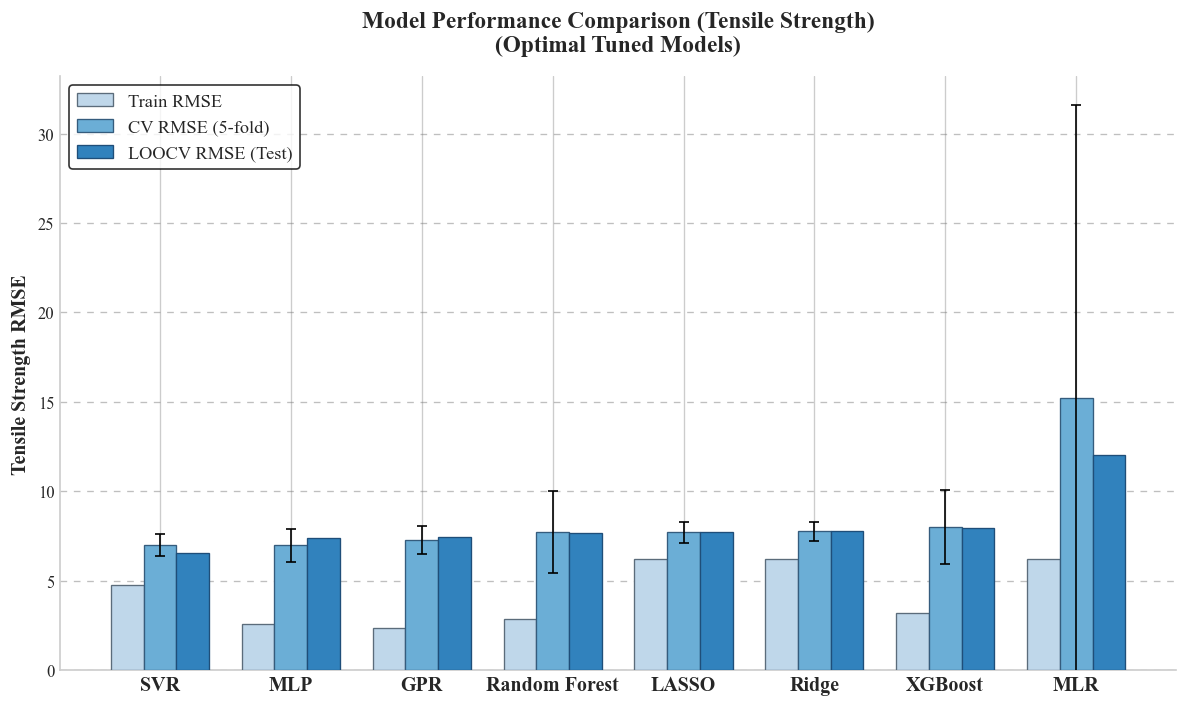


Tensile 三RMSE对比（最优参数）:
           Model  Train_RMSE  CV_RMSE_5Fold  CV_RMSE_5Fold_Std  LOOCV_RMSE
0            SVR      4.7774         6.9774             0.6183      6.5402
1            MLP      2.6036         6.9825             0.9115      7.3931
2            GPR      2.3723         7.2731             0.7842      7.4192
3  Random Forest      2.8540         7.7250             2.2897      7.6892
4          LASSO      6.2282         7.7006             0.5707      7.7012
5          Ridge      6.2039         7.7576             0.5383      7.7910
6        XGBoost      3.2046         7.9937             2.0772      7.9243
7            MLR      6.1907        15.2001            16.3705     12.0369


In [15]:
# --- 学术级多模型性能横向比对柱状图 (Train vs 5-Fold CV vs LOOCV) ---
# 仅重做 tensile，并严格使用第13个单元自动调参后的最优模型对象
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import KFold, cross_validate, cross_val_predict, LeaveOneOut
from sklearn.metrics import mean_squared_error

# 安全检查：确保已运行第13个单元
if 'best_models' not in globals() or 'res_df_tensile' not in globals():
    raise RuntimeError("未检测到 best_models / res_df_tensile，请先运行第13个单元（tensile自动调参对比）。")

# 数据
target_name = 'Tensile Strength'
target_col = 'tensile_strength'
X_cur, y_cur = get_clean_data(target_col, features_mech, df)

# 使用第13个单元排序后的模型顺序（即最优参数结果顺序）
model_order = res_df_tensile['Model'].tolist()

train_rmses = []
cv_rmses = []
cv_stds = []
loocv_rmses = []

print(f"正在基于最优参数重绘 {target_name} 三RMSE条形图...")

for model_name in model_order:
    model = clone(best_models[model_name])

    # 1) Train RMSE
    model.fit(X_cur, y_cur)
    y_train_pred = model.predict(X_cur)
    train_rmse = float(np.sqrt(mean_squared_error(y_cur, y_train_pred)))
    train_rmses.append(train_rmse)

    # 2) 5-fold CV RMSE（均值+标准差）
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_result = cross_validate(
        clone(model), X_cur, y_cur, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    rmse_scores = -cv_result['test_score']
    cv_rmses.append(float(np.mean(rmse_scores)))
    cv_stds.append(float(np.std(rmse_scores, ddof=1)))

    # 3) LOOCV RMSE
    loo = LeaveOneOut()
    y_loocv_pred = cross_val_predict(clone(model), X_cur, y_cur, cv=loo, n_jobs=-1)
    loocv_rmse = float(np.sqrt(mean_squared_error(y_cur, y_loocv_pred)))
    loocv_rmses.append(loocv_rmse)

# 学术配色（按 elongation 模板）
color_train = '#BFD7EA'
color_cv = '#6BAED6'
color_test = '#3182BD'

# 作图
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
x_pos = np.arange(len(model_order))
width = 0.25

ax.bar(
    x_pos - width, train_rmses, width, label='Train RMSE',
    color=color_train, edgecolor='#5B6C7B', linewidth=0.8, zorder=3
)
ax.bar(
    x_pos, cv_rmses, width, yerr=cv_stds, label='CV RMSE (5-fold)',
    color=color_cv, edgecolor='#355C7D', linewidth=0.8, capsize=3, ecolor='black', error_kw={'elinewidth': 1}, zorder=3
)
ax.bar(
    x_pos + width, loocv_rmses, width, label='LOOCV RMSE (Test)',
    color=color_test, edgecolor='#1F4E79', linewidth=0.8, zorder=3
)

ax.set_ylabel(f'{target_name} RMSE', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (Tensile Strength)\n(Optimal Tuned Models)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_order, fontsize=12, fontweight='bold')
ax.set_ylim(bottom=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle=(0, (5, 5)), alpha=0.5, color='gray', zorder=0)
ax.legend(fontsize=11, frameon=True, shadow=False, edgecolor='black')

plt.tight_layout()
plt.show()

# 输出核对表
rmse_compare_tensile = pd.DataFrame({
    'Model': model_order,
    'Train_RMSE': train_rmses,
    'CV_RMSE_5Fold': cv_rmses,
    'CV_RMSE_5Fold_Std': cv_stds,
    'LOOCV_RMSE': loocv_rmses,
})
print('\nTensile 三RMSE对比（最优参数）:')
print(rmse_compare_tensile.round(4))

In [ ]:
# ============================================
# 一图决策（纯图版）：RMSE + R2（无表格，主图显示全部8个算法）
# 严格优先使用前面对比单元结果：res_df_tensile（SVR≈0.76）
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) 目标切换
decision_target = 'tensile_strength'  # 'elongation' / 'healing_eff'

# 2) 读取前面单元的结果表（优先顺序非常严格）
def _pick_result_df(target_name: str):
    if target_name == 'tensile_strength':
        if 'res_df_tensile' in globals() and isinstance(res_df_tensile, pd.DataFrame):
            return res_df_tensile[['Model', 'R2', 'RMSE']].copy(), 'res_df_tensile'
        if 'res_df' in globals() and isinstance(res_df, pd.DataFrame):
            tmp = res_df.copy()
            needed_cols = {'Model', 'R2', 'RMSE'}
            model_set = set(tmp['Model'].astype(str).tolist()) if 'Model' in tmp.columns else set()
            if needed_cols.issubset(tmp.columns) and {'MLR', 'Ridge', 'LASSO', 'SVR'}.issubset(model_set):
                return tmp[['Model', 'R2', 'RMSE']].copy(), 'res_df'
        raise ValueError('未检测到 tensile 的自动调参结果表。请先运行第20格（多模型自动调参）后再运行本格。')

    if target_name == 'elongation':
        if 'res_df_elong' in globals() and isinstance(res_df_elong, pd.DataFrame):
            return res_df_elong[['Model', 'R2', 'RMSE']].copy(), 'res_df_elong'
        raise ValueError('未检测到 elongation 结果表。请先运行第21格后再运行本格。')

    if target_name == 'healing_eff':
        if 'res_df_heal' in globals() and isinstance(res_df_heal, pd.DataFrame):
            return res_df_heal[['Model', 'R2', 'RMSE']].copy(), 'res_df_heal'
        raise ValueError('未检测到 healing_eff 结果表。请先运行第22格后再运行本格。')

    raise ValueError(f'未知目标: {target_name}')

res_dec, source_name = _pick_result_df(decision_target)

# 3) 计算综合分（R2高 + RMSE低）
w_r2, w_rmse = 0.55, 0.45
r2_min, r2_max = res_dec['R2'].min(), res_dec['R2'].max()
rmse_min, rmse_max = res_dec['RMSE'].min(), res_dec['RMSE'].max()

res_dec['R2_norm'] = 1.0 if np.isclose(r2_max, r2_min) else (res_dec['R2'] - r2_min) / (r2_max - r2_min)
res_dec['RMSE_norm'] = 1.0 if np.isclose(rmse_max, rmse_min) else (rmse_max - res_dec['RMSE']) / (rmse_max - rmse_min)
res_dec['Score'] = w_r2 * res_dec['R2_norm'] + w_rmse * res_dec['RMSE_norm']

res_dec = res_dec.sort_values('Score', ascending=False).reset_index(drop=True)
res_dec['Rank'] = np.arange(1, len(res_dec) + 1)
best_row = res_dec.iloc[0]

# 4) 仅用于视觉辅助：标记离群，但不隐藏任何点
q1_rmse, q3_rmse = res_dec['RMSE'].quantile([0.25, 0.75])
iqr_rmse = q3_rmse - q1_rmse
rmse_upper = q3_rmse + 1.5 * iqr_rmse

q1_r2, q3_r2 = res_dec['R2'].quantile([0.25, 0.75])
iqr_r2 = q3_r2 - q1_r2
r2_lower = q1_r2 - 1.5 * iqr_r2

res_dec['is_outlier'] = (res_dec['RMSE'] > rmse_upper) | (res_dec['R2'] < r2_lower)

# 5) 主图：显示全部8个算法
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10.6, 7.0), dpi=140)

main_df = res_dec[~res_dec['is_outlier']].copy()
out_df = res_dec[res_dec['is_outlier']].copy()

# 非离群点
if len(main_df) > 0:
    ax.scatter(main_df['RMSE'], main_df['R2'], s=145, c='#4292c6', edgecolors='black', linewidths=0.95, zorder=3)

# 离群点（仍在主图显示，只是换色）
if len(out_df) > 0:
    ax.scatter(out_df['RMSE'], out_df['R2'], s=155, c='#F28E2B', edgecolors='black', linewidths=0.95, zorder=3)

# 所有点都标 rank 数字
for _, row in res_dec.iterrows():
    txt_color = 'white' if not row['is_outlier'] else 'black'
    ax.text(row['RMSE'], row['R2'], str(int(row['Rank'])), ha='center', va='center',
            color=txt_color, fontsize=9, fontweight='bold', zorder=4)

# 推荐点高亮
ax.scatter(best_row['RMSE'], best_row['R2'], s=280, marker='*', c='crimson', edgecolors='black', linewidths=0.95, zorder=5)
ax.annotate(
    f"Recommended #{int(best_row['Rank'])}: {best_row['Model']}\nR2={best_row['R2']:.3f}, RMSE={best_row['RMSE']:.3f}",
    xy=(best_row['RMSE'], best_row['R2']),
    xytext=(24, 24),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.8, color='crimson'),
    fontsize=10.5,
    color='crimson',
    bbox=dict(boxstyle='round,pad=0.28', fc='white', ec='crimson', alpha=0.95)
)

# 坐标范围基于“全部点”，确保1-8全部可见
x_min, x_max = res_dec['RMSE'].min(), res_dec['RMSE'].max()
y_min, y_max = res_dec['R2'].min(), res_dec['R2'].max()
x_pad = (x_max - x_min) * 0.10 if x_max > x_min else 0.5
y_pad = (y_max - y_min) * 0.10 if y_max > y_min else 0.05
ax.set_xlim(max(0, x_min - x_pad), x_max + x_pad)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

# 图例（简洁）
legend_items = []
if len(main_df) > 0:
    legend_items.append(plt.Line2D([0], [0], marker='o', color='w', label='Regular Models', markerfacecolor='#4292c6', markeredgecolor='black', markersize=8))
if len(out_df) > 0:
    legend_items.append(plt.Line2D([0], [0], marker='o', color='w', label='Outlier Models', markerfacecolor='#F28E2B', markeredgecolor='black', markersize=8))
legend_items.append(plt.Line2D([0], [0], marker='*', color='w', label='Recommended', markerfacecolor='crimson', markeredgecolor='black', markersize=12))
ax.legend(handles=legend_items, loc='best', fontsize=9)

ax.set_title(f"Model Selection Map ({decision_target})\n(LOOCV R2 vs LOOCV RMSE)", fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('RMSE (lower is better)', fontsize=12, fontweight='bold')
ax.set_ylabel('R2 (higher is better)', fontsize=12, fontweight='bold')
ax.grid(True, linestyle=(0, (4, 5)), alpha=0.45)

plt.tight_layout()
plt.show()

# 6) 控制台确认
print(f"\nTarget: {decision_target}")
print(f"Source: {source_name}")
print(f"Recommended model: {best_row['Model']}")
print(res_dec[['Rank', 'Model', 'R2', 'RMSE', 'Score']].round(4))


目标: Tensile Strength | 采用最优算法: SVR | 来源: res_df_tensile
level1                         | 特征数= 5 | R2= 0.3965 | RMSE=  10.4462
level1+level2                  | 特征数= 9 | R2= 0.3961 | RMSE=  10.4496
level1+level2+level3           | 特征数=14 | R2= 0.7635 | RMSE=   6.5402
level1                         | 特征数= 5 | R2= 0.3965 | RMSE=  10.4462
level1+level2                  | 特征数= 9 | R2= 0.3961 | RMSE=  10.4496
level1+level2+level3           | 特征数=14 | R2= 0.7635 | RMSE=   6.5402


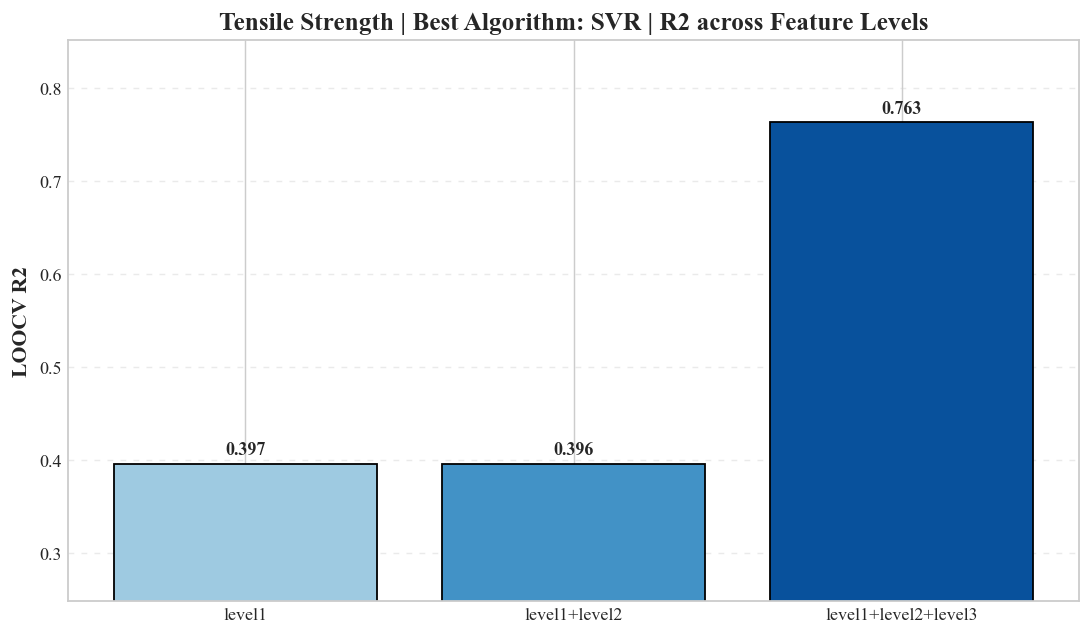

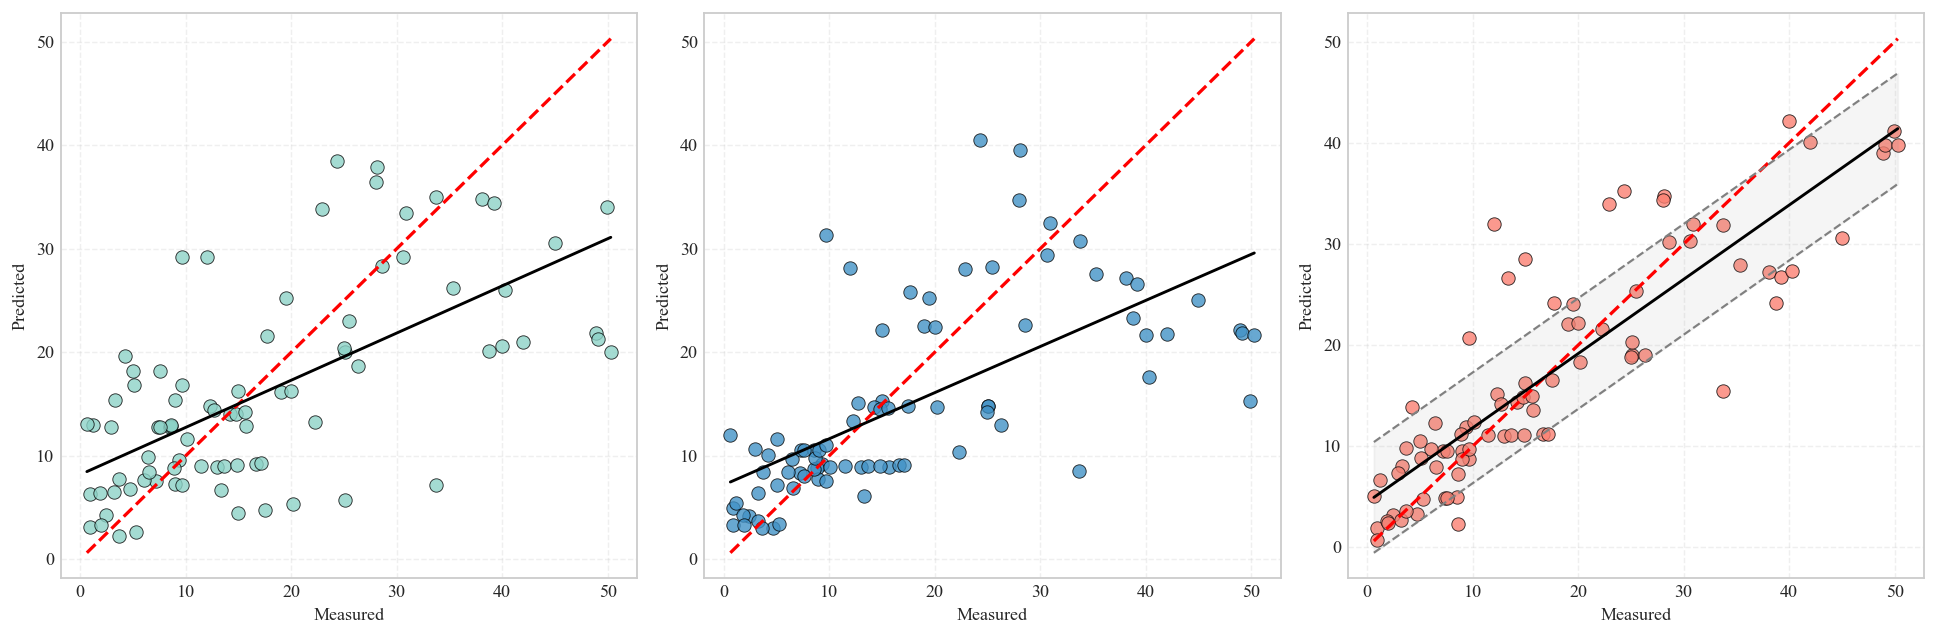


目标: Elongation | 采用最优算法: XGBoost | 来源: res_df_elong
level1                         | 特征数= 5 | R2= 0.2145 | RMSE= 238.9803
level1                         | 特征数= 5 | R2= 0.2145 | RMSE= 238.9803
level1+level2                  | 特征数= 9 | R2= 0.4924 | RMSE= 192.1120
level1+level2                  | 特征数= 9 | R2= 0.4924 | RMSE= 192.1120
level1+level2+level3           | 特征数=14 | R2= 0.6627 | RMSE= 156.5909
level1+level2+level3           | 特征数=14 | R2= 0.6627 | RMSE= 156.5909


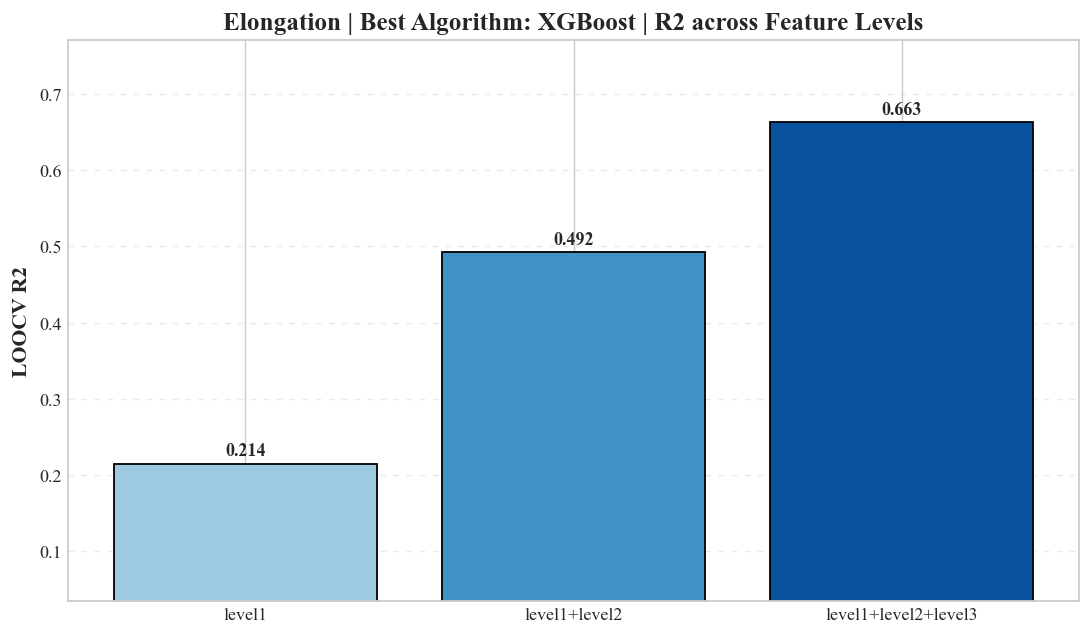

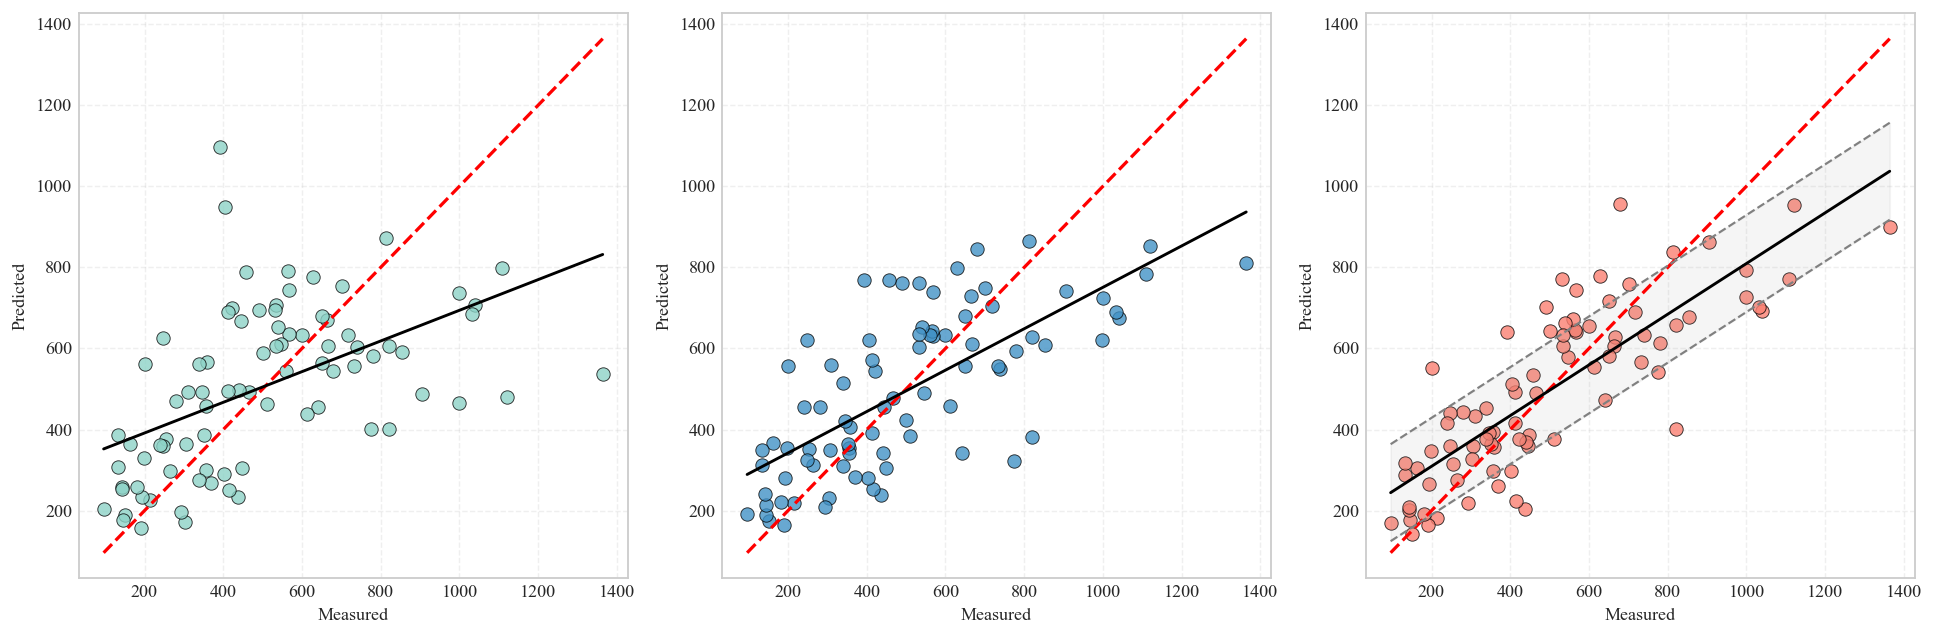


目标: Healing Efficiency | 采用最优算法: GPR | 来源: res_df_heal
level1                         | 特征数= 5 | R2= 0.2940 | RMSE=  10.1574
level1                         | 特征数= 5 | R2= 0.2940 | RMSE=  10.1574


/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Docume

level1+level2                  | 特征数= 9 | R2= 0.5771 | RMSE=   7.8610


/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Docume

level1+level2+level3+process   | 特征数=16 | R2= 0.8079 | RMSE=   5.2984


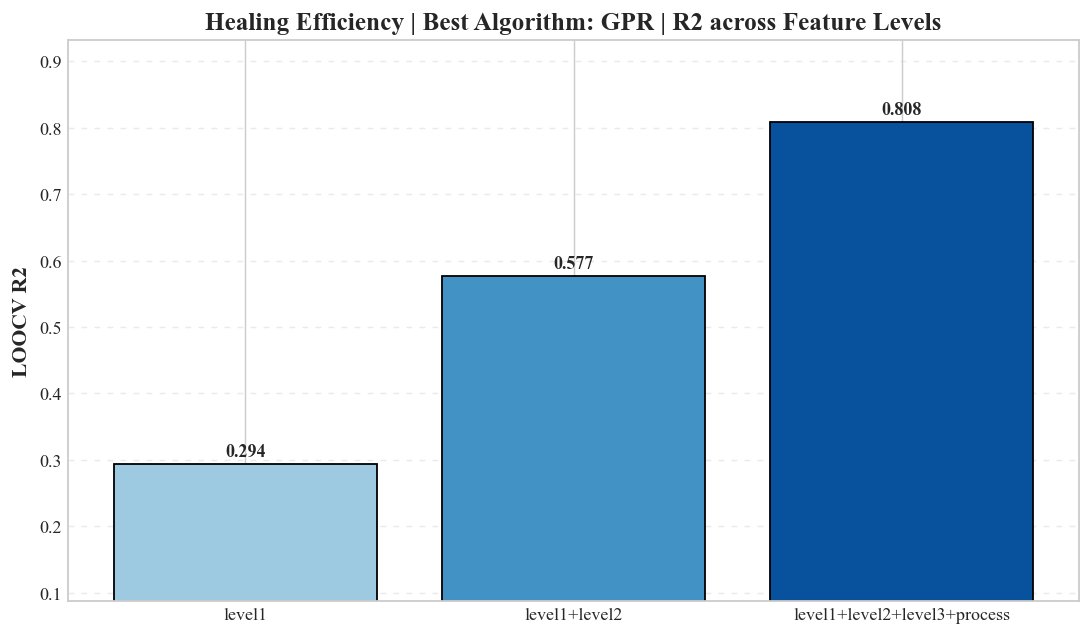

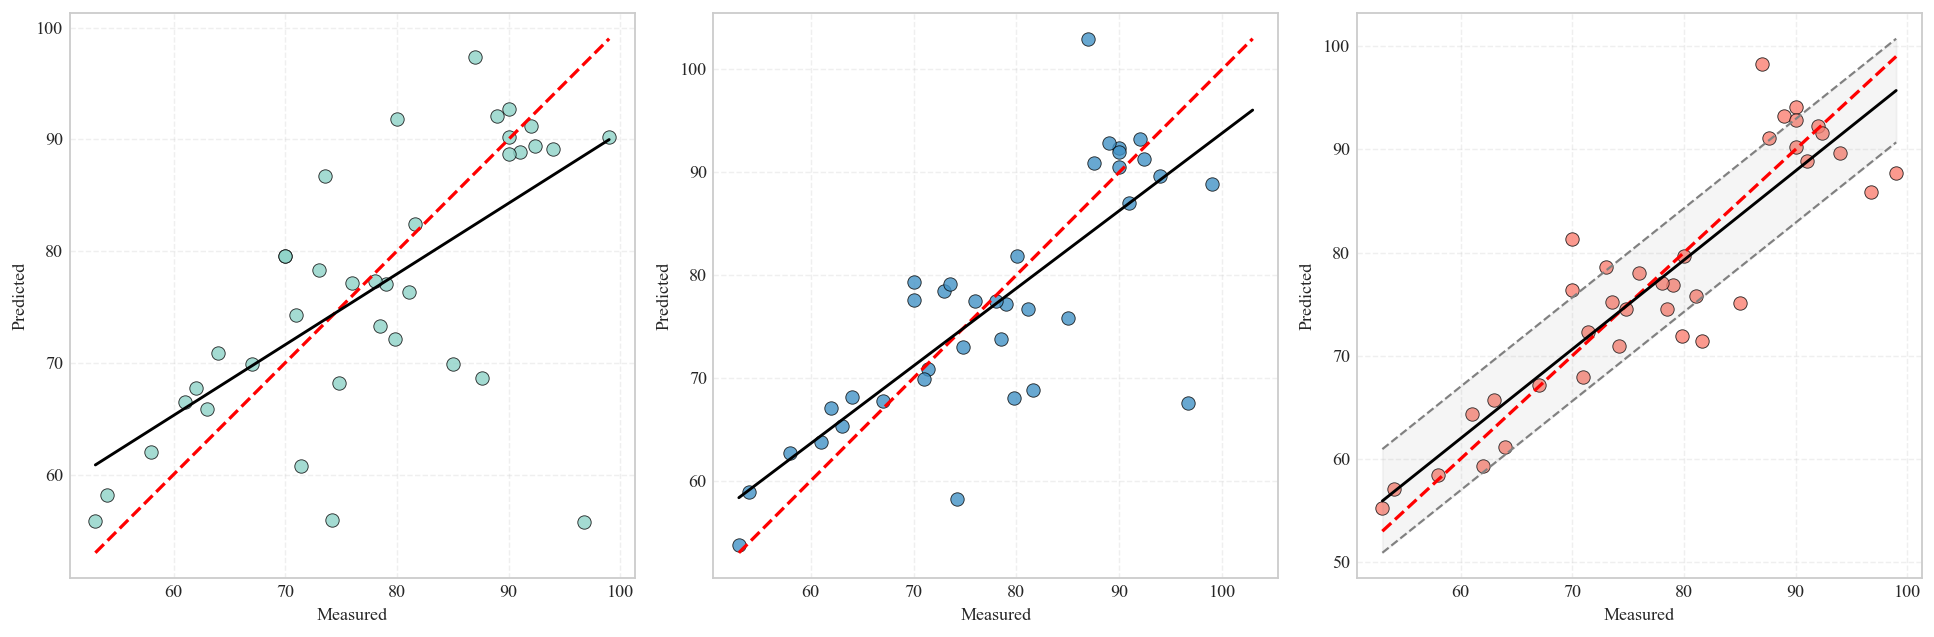


分层特征评估汇总：
               Target         TargetCol BestModel     ModelSource  \
0    Tensile Strength  tensile_strength       SVR  res_df_tensile   
1    Tensile Strength  tensile_strength       SVR  res_df_tensile   
2    Tensile Strength  tensile_strength       SVR  res_df_tensile   
3          Elongation        elongation   XGBoost    res_df_elong   
4          Elongation        elongation   XGBoost    res_df_elong   
5          Elongation        elongation   XGBoost    res_df_elong   
6  Healing Efficiency       healing_eff       GPR     res_df_heal   
7  Healing Efficiency       healing_eff       GPR     res_df_heal   
8  Healing Efficiency       healing_eff       GPR     res_df_heal   

                          Level  NumFeatures      R2      RMSE  
0                        level1            5  0.3965   10.4462  
1                 level1+level2            9  0.3961   10.4496  
2          level1+level2+level3           14  0.7635    6.5402  
3                        level1       

In [68]:
# ============================================
# 三目标：最优算法在分层特征输入下的 R2 与拟合曲线
# elongation: level1 / level1+level2 / level1+level2+level3
# healing:    level1 / level1+level2 / level1+level2+level3+process (即 1/2/3 阶段)
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, RBF
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor


verified_best_models = {
    'tensile_strength': 'SVR',
    'elongation': 'XGBoost',
    'healing_eff': 'GPR'
}

# 参考带宽系数：越小，虚线带越窄（包含点更少）
pi_sigma_factor = 1.0


def build_model_by_name(model_name: str):
    name = str(model_name).strip()
    if name == 'MLR':
        return LinearRegression()
    if name == 'Ridge':
        return make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42))
    if name in ['LASSO', 'Lasso']:
        return make_pipeline(StandardScaler(), Lasso(alpha=0.01, random_state=42, max_iter=20000))
    if name == 'SVR':
        return make_pipeline(StandardScaler(), SVR(C=500, gamma=1.0, epsilon=0.1, kernel='rbf'))
    if name in ['Random Forest', 'RF']:
        return RandomForestRegressor(n_estimators=400, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
    if name == 'XGBoost':
        return XGBRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1
        )
    if name == 'GPR':
        kernel = 1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + \
                 WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
        return make_pipeline(
            StandardScaler(),
            GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=5)
        )
    if name in ['MLP', 'ANN']:
        return make_pipeline(
            StandardScaler(),
            MLPRegressor(hidden_layer_sizes=(64,), activation='tanh', solver='lbfgs', alpha=0.01, max_iter=3000, random_state=42)
        )
    raise ValueError(f'未知模型名: {name}')


def get_best_model_name_for_target(target_col: str):
    if target_col == 'tensile_strength' and 'res_df_tensile' in globals() and isinstance(res_df_tensile, pd.DataFrame):
        return res_df_tensile.sort_values('R2', ascending=False).iloc[0]['Model'], 'res_df_tensile'
    if target_col == 'elongation' and 'res_df_elong' in globals() and isinstance(res_df_elong, pd.DataFrame):
        return res_df_elong.sort_values('R2', ascending=False).iloc[0]['Model'], 'res_df_elong'
    if target_col == 'healing_eff' and 'res_df_heal' in globals() and isinstance(res_df_heal, pd.DataFrame):
        return res_df_heal.sort_values('R2', ascending=False).iloc[0]['Model'], 'res_df_heal'
    return verified_best_models[target_col], 'fallback_fixed_default'


def get_best_model_estimator_for_target(target_col: str, best_model_name: str):
    if target_col == 'tensile_strength' and 'best_models' in globals() and isinstance(best_models, dict):
        if best_model_name in best_models:
            return clone(best_models[best_model_name])
    if target_col == 'elongation' and 'best_models_elong' in globals() and isinstance(best_models_elong, dict):
        if best_model_name in best_models_elong:
            return clone(best_models_elong[best_model_name])
    if target_col == 'healing_eff' and 'best_models_heal' in globals() and isinstance(best_models_heal, dict):
        if best_model_name in best_models_heal:
            return clone(best_models_heal[best_model_name])
    return build_model_by_name(best_model_name)


def evaluate_loocv(model, X, y):
    y_pred = cross_val_predict(model, X, y, cv=LeaveOneOut(), n_jobs=-1)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    return r2, rmse, y_pred


lvl1 = features_mech[:5]
lvl2 = features_mech[5:9]
lvl3 = features_mech[9:]

analysis_targets = [
    ('Tensile Strength', 'tensile_strength'),
    ('Elongation', 'elongation'),
    ('Healing Efficiency', 'healing_eff')
]

layer_results_all = []

for target_name, target_col in analysis_targets:
    best_model_name, model_source = get_best_model_name_for_target(target_col)

    if target_col == 'healing_eff':
        feature_levels = [
            ('level1', lvl1),
            ('level1+level2', lvl1 + lvl2),
            ('level1+level2+level3+process', lvl1 + lvl2 + lvl3 + ['healing_temperature', 'healing_time'])
        ]
    else:
        feature_levels = [
            ('level1', lvl1),
            ('level1+level2', lvl1 + lvl2),
            ('level1+level2+level3', lvl1 + lvl2 + lvl3)
        ]

    print(f"\n{'='*90}")
    print(f"目标: {target_name} | 采用最优算法: {best_model_name} | 来源: {model_source}")
    print(f"{'='*90}")

    if model_source == 'fallback_fixed_default':
        print("⚠️ 当前未检测到该目标的自动调参结果表，正在使用固定默认参数，R2 可能低于你之前的最优结果。")

    per_level = []

    for level_label, feat_list in feature_levels:
        X_cur, y_cur = get_clean_data(target_col, feat_list, df)
        model = get_best_model_estimator_for_target(target_col, best_model_name)
        r2, rmse, y_pred = evaluate_loocv(model, X_cur, y_cur)

        rec = {
            'Target': target_name,
            'TargetCol': target_col,
            'BestModel': best_model_name,
            'ModelSource': model_source,
            'Level': level_label,
            'NumFeatures': len(feat_list),
            'R2': r2,
            'RMSE': rmse,
            'y_true': y_cur,
            'y_pred': y_pred
        }
        per_level.append(rec)
        layer_results_all.append({k: v for k, v in rec.items() if k not in ['y_true', 'y_pred']})

        print(f"{level_label:<30} | 特征数={len(feat_list):>2d} | R2={r2:>7.4f} | RMSE={rmse:>9.4f}")

    n_levels = len(per_level)

    # ----------------------------------------------------
    # 1. 输出条形图 (R2 Comparison)
    # ----------------------------------------------------
    bar_fig_width = max(8.5, 2.4 * n_levels)
    fig_bar, ax_bar = plt.subplots(figsize=(bar_fig_width, 5), dpi=130)

    level_labels = [x['Level'] for x in per_level]
    r2_vals = [x['R2'] for x in per_level]

    bar_colors = ['#9ecae1', '#4292c6', '#08519c']

    bars = ax_bar.bar(level_labels, r2_vals, color=bar_colors[:n_levels], edgecolor='black', linewidth=1.0)
    ax_bar.set_ylabel('LOOCV R2', fontsize=12, fontweight='bold')
    ax_bar.set_title(f'{target_name} | Best Algorithm: {best_model_name} | R2 across Feature Levels', fontsize=14, fontweight='bold')
    ax_bar.grid(axis='y', linestyle=(0, (4, 5)), alpha=0.4)

    r2_min, r2_max = min(r2_vals), max(r2_vals)
    pad = max(0.05, (r2_max - r2_min) * 0.4)
    ax_bar.set_ylim(r2_min - pad, min(1.05, r2_max + pad * 0.6))

    for b, v in zip(bars, r2_vals):
        ax_bar.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.006, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    fig_bar.subplots_adjust(top=0.90, bottom=0.18)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------------------
    # 2. 输出散点图 (Measured vs Predicted)
    # ----------------------------------------------------
    fig_scat, axes = plt.subplots(1, n_levels, figsize=(5 * n_levels, 5), dpi=130)
    if n_levels == 1:
        axes = [axes]

    # 各预测阶段散点颜色（与条形图区分）
    scatter_colors = ['#8dd3c7', '#4292c6', '#fb8072']

    for i, rec in enumerate(per_level):
        ax = axes[i]
        y_true = rec['y_true']
        y_pred = rec['y_pred']

        y_min = min(np.min(y_true), np.min(y_pred))
        y_max = max(np.max(y_true), np.max(y_pred))
        line_x = np.linspace(y_min, y_max, 200)

        # 散点（更换配色）
        ax.scatter(y_true, y_pred, s=55, alpha=0.80, c=scatter_colors[i], edgecolors='black', linewidths=0.5)
        # 1:1 对角线
        ax.plot(line_x, line_x, 'r--', linewidth=1.8)

        if len(y_true) > 1:
            # 拟合线
            k, b = np.polyfit(y_true, y_pred, 1)
            ax.plot(line_x, k * line_x + b, color='black', linewidth=1.6)

            # --- 特殊处理: 最后一个子图 (Level 3) 增加参考虚线 ---
            if i == n_levels - 1:
                y_fit_vals = k * y_true + b
                resid = y_pred - y_fit_vals
                sigma = np.std(resid)

                # 由原先 ±2σ 收窄到 ±1σ，减少被包络点数
                upper_line = k * line_x + b + pi_sigma_factor * sigma
                lower_line = k * line_x + b - pi_sigma_factor * sigma

                ax.plot(line_x, upper_line, color='grey', linestyle='--', linewidth=1.2)
                ax.plot(line_x, lower_line, color='grey', linestyle='--', linewidth=1.2)
                ax.fill_between(line_x, lower_line, upper_line, color='grey', alpha=0.08)


        ax.set_xlabel('Measured', fontsize=10)
        ax.set_ylabel('Predicted', fontsize=10)
        ax.grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

layer_results_df = pd.DataFrame(layer_results_all)
print("\n分层特征评估汇总：")
print(layer_results_df.round(4))

[Tensile Strength | SVR] SHAP计算中... (模型来源: 上方最优模型对象)
  最优参数: {'svr__gamma': 0.01, 'svr__epsilon': 0.1, 'svr__C': 100}


100%|██████████| 84/84 [00:02<00:00, 32.72it/s]
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHe

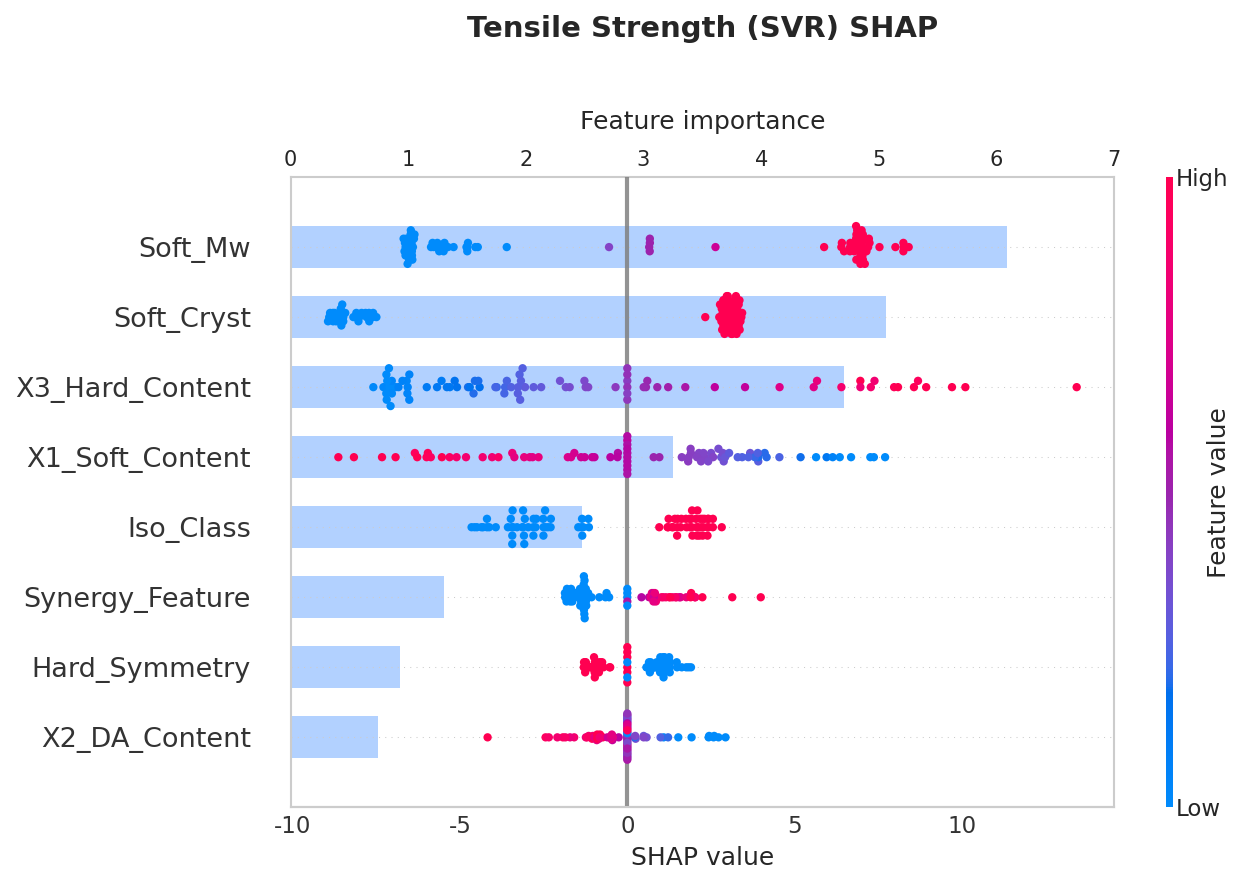

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

[Elongation | XGBoost] SHAP计算中... (模型来源: 上方最优模型对象)
  最优参数: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.02, 'colsample_bytree': 0.6}


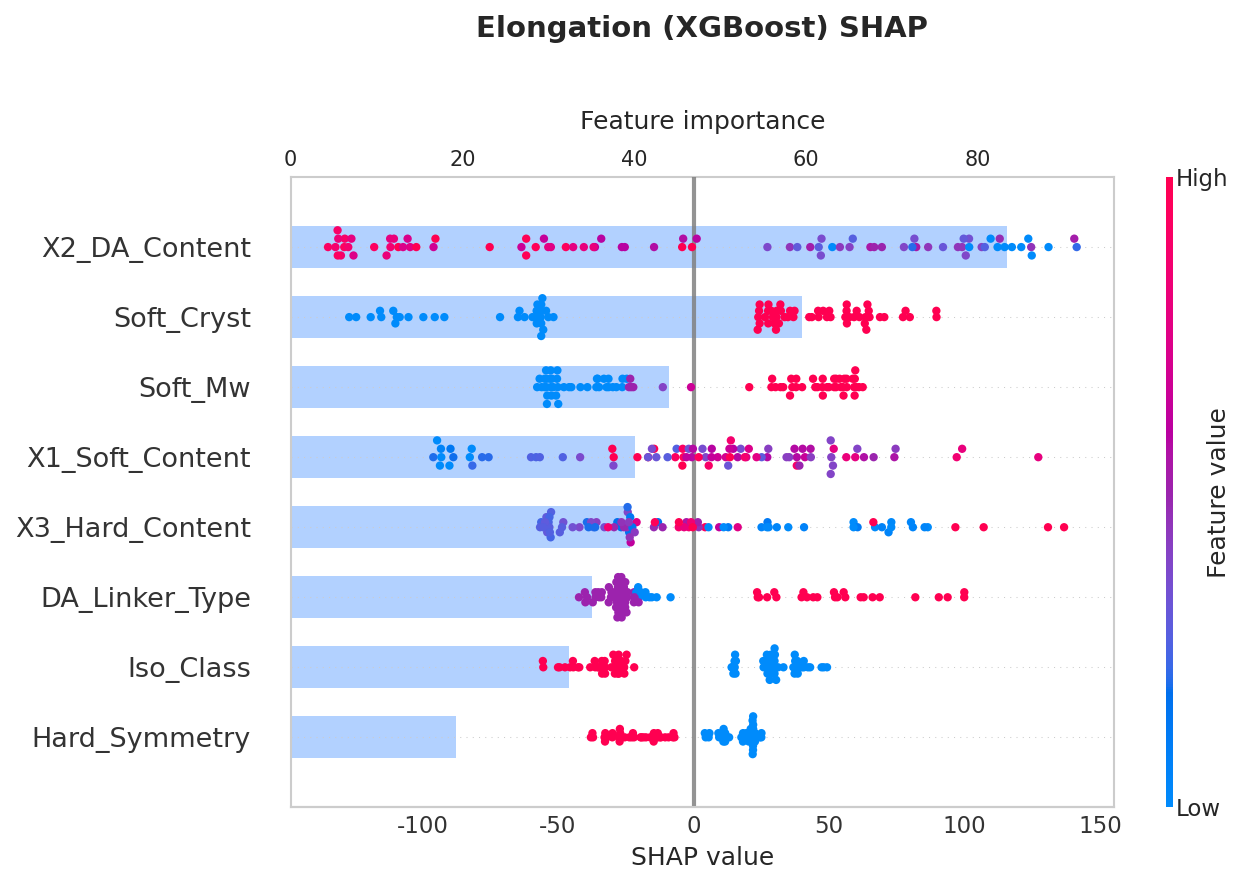

[Healing Efficiency | GPR] SHAP计算中... (模型来源: 上方最优模型对象)
  最优参数: {'gaussianprocessregressor__alpha': 0.0001, 'gaussianprocessregressor__kernel': 1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=0.1), 'gaussianprocessregressor__n_restarts_optimizer': 0, 'gaussianprocessregressor__normalize_y': False}


100%|██████████| 37/37 [00:00<00:00, 81.28it/s]
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHe

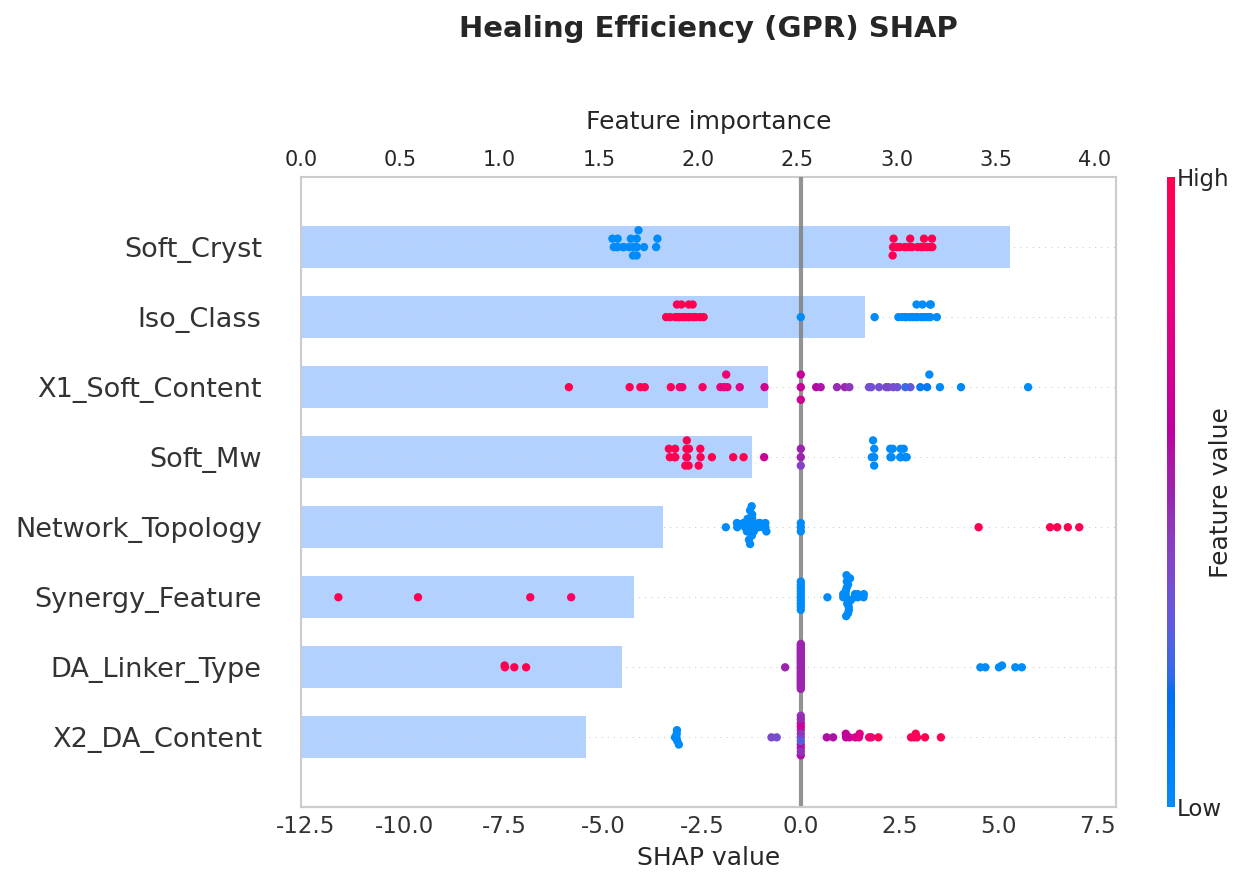

In [ ]:
# ============================================
# 按要求绘制 SHAP 散点图 + 底部条形图 (Top 8 特征)
# 最优算法（严格来自上方单元最优结果）对应三个目标
# ============================================
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone

import warnings
warnings.filterwarnings('ignore')

# 使用数据集
df_all = pd.read_csv('Final_Features_Ultimate_all_deletion.csv')

features_mech_all = [
    'X1_Soft_Content', 'X2_DA_Content', 'X3_Hard_Content', 'X4_R_Ratio', 'X5_Add_Crosslink',
    'DA_Linker_Type', 'Network_Topology', 'Polyol_Class', 'Iso_Class',
    'Soft_Mw', 'Constraint_Factor', 'Hard_Symmetry', 'Soft_Cryst', 'Synergy_Feature'
]
features_heal_all = features_mech_all + ['healing_temperature', 'healing_time']

def get_clean_data_local(target_col, feature_cols):
    d = df_all.dropna(subset=[target_col] + feature_cols).copy()
    return d[feature_cols].copy(), d[target_col].values


def extract_best_params(best_row):
    for col in ['Best_Params', 'Params', 'best_params']:
        if col in best_row.index:
            return best_row[col]
    return 'N/A'


def get_best_from_upper_cells_strict(target_col):
    if target_col == 'tensile_strength':
        df_res = res_df_tensile if 'res_df_tensile' in globals() and isinstance(res_df_tensile, pd.DataFrame) else (
            res_df if 'res_df' in globals() and isinstance(res_df, pd.DataFrame) else None
        )
        model_bank = best_models if 'best_models' in globals() and isinstance(best_models, dict) else None
    elif target_col == 'elongation':
        df_res = res_df_elong if 'res_df_elong' in globals() and isinstance(res_df_elong, pd.DataFrame) else None
        model_bank = best_models_elong if 'best_models_elong' in globals() and isinstance(best_models_elong, dict) else None
    else:
        df_res = res_df_heal if 'res_df_heal' in globals() and isinstance(res_df_heal, pd.DataFrame) else None
        model_bank = best_models_heal if 'best_models_heal' in globals() and isinstance(best_models_heal, dict) else None

    if df_res is None or model_bank is None or len(df_res) == 0:
        raise RuntimeError(f"{target_col}: 未找到上方最优结果表或最优模型对象，请先运行调参与最优模型单元。")

    best_row = df_res.sort_values('R2', ascending=False).iloc[0]
    best_name = str(best_row['Model'])

    if best_name not in model_bank:
        raise RuntimeError(f"{target_col}: 最优模型 {best_name} 不在最优模型对象字典中，请先完整运行上方单元。")

    best_params = extract_best_params(best_row)
    return best_name, clone(model_bank[best_name]), best_params


targets_list = [
    ('Tensile Strength', 'tensile_strength', features_mech_all),
    ('Elongation', 'elongation', features_mech_all),
    ('Healing Efficiency', 'healing_eff', features_heal_all),
]

for target_name, target_col, feats in targets_list:
    X_df, y = get_clean_data_local(target_col, feats)
    mname, model, best_params = get_best_from_upper_cells_strict(target_col)

    model.fit(X_df.values, y)

    print(f"[{target_name} | {mname}] SHAP计算中... (模型来源: 上方最优模型对象)")
    print(f"  最优参数: {best_params}")

    if mname == 'XGBoost':
        exp_xg = shap.TreeExplainer(model)
        vals = exp_xg.shap_values(X_df)
    elif mname == 'SVR':
        scaler = model.named_steps['standardscaler']
        svr_model = model.named_steps['svr']
        X_scaled = scaler.transform(X_df.values)
        X_train_summary = shap.kmeans(X_scaled, k=30).data
        exp_svr = shap.KernelExplainer(svr_model.predict, X_train_summary)
        vals = exp_svr.shap_values(X_scaled, nsamples=400)
    elif mname == 'GPR':
        scaler = model.named_steps['standardscaler']
        gpr_model = model.named_steps['gaussianprocessregressor']
        X_scaled = scaler.transform(X_df.values)
        X_train_summary = shap.kmeans(X_scaled, k=30).data
        exp_gpr = shap.KernelExplainer(gpr_model.predict, X_train_summary)
        vals = exp_gpr.shap_values(X_scaled, nsamples=400)
    else:
        exp = shap.Explainer(model.predict, X_df)
        exp_vals = exp(X_df)
        vals = exp_vals.values

    if len(vals.shape) == 3:
        vals = vals[:, :, 0]

    mean_abs = np.abs(vals).mean(axis=0)

    top_idx = np.argsort(mean_abs)[::-1][:8]
    X_top = X_df.iloc[:, top_idx]
    vals_top = vals[:, top_idx]

    mean_abs_dict = {feat: val for feat, val in zip(X_df.columns[top_idx], mean_abs[top_idx])}

    plt.close('all')
    fig = plt.figure(figsize=(9, 6), dpi=150)

    shap.summary_plot(vals_top, X_top, show=False, plot_size=None)

    ax1 = plt.gca()
    ax1.set_xlabel('SHAP value', fontsize=12)

    ax1.tick_params(axis='y', pad=-1)

    for line in list(ax1.lines):
        xd = line.get_xdata()
        if hasattr(xd, '__len__') and len(xd) >= 2:
            if np.allclose(np.asarray(xd, dtype=float), float(xd[0])):
                line.remove()

    ax1.grid(False)
    ax1.xaxis.grid(False)
    ax1.yaxis.grid(False)

    ax1.axvline(0, color='gray', linewidth=2.0, alpha=0.85, zorder=1)

    yticklabels = [t.get_text() for t in ax1.get_yticklabels()]
    bar_lengths = [mean_abs_dict[name] for name in yticklabels]
    y_pos = np.arange(len(yticklabels))

    ax2 = ax1.twiny()

    ax2.barh(y_pos, bar_lengths, color='#9ecae1', alpha=0.6, height=0.6, align='center', zorder=-1)

    ax2.set_xlabel('Feature importance', fontsize=12, labelpad=10)
    ax2.xaxis.set_label_position('top')
    ax2.xaxis.tick_top()
    ax2.set_xlim(0, max(bar_lengths) * 1.15)

    ax2.grid(False)
    ax2.xaxis.grid(False)
    ax2.yaxis.grid(False)

    ax1.patch.set_visible(False)
    ax1.set_zorder(ax2.get_zorder() + 1)

    for cax in fig.axes:
        if cax is not ax1 and cax is not ax2:
            if isinstance(cax.get_ylabel(), str) and 'Feature value' in cax.get_ylabel():
                cax.set_ylabel('Feature value', rotation=90, fontsize=12, labelpad=-10)
                cax.yaxis.set_label_position('right')
                cax.tick_params(axis='y', pad=1)

    plt.title(f"{target_name} ({mname}) SHAP", pad=35, fontsize=14, loc='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================
# 附加实验：清洗后特征消融（tensile + elongation）
# ============================================

ablation_feats = ['Hard_Soft_Ratio_clean', 'Crosslink_Density_Proxy_clean']
base_features_mech = [f for f in features_mech if f not in ablation_feats]

def run_multimodel_for_target(target_col, feature_list):
    X_cur, y_cur = get_clean_data(target_col, feature_list, df)
    out = []
    for name in base_models.keys():
        tuned_model, route_used, best_params, tune_rmse, r2, rmse, _ = nested_loocv_tune_eval(
            name,
            base_models[name],
            param_spaces[name],
            X_cur,
            y_cur,
            outer_mode="kfoldOuter",
            n_outer_splits=5,
            random_iter=25,
            inner_split_cap=3,
            search_n_jobs=1,
        )
        out.append({
            'Model': name,
            'Route': route_used,
            'R2': r2,
            'RMSE': rmse,
            'Tune_CV_RMSE': tune_rmse,
            'Best_Params': best_params
        })
    return pd.DataFrame(out).sort_values('R2', ascending=False).reset_index(drop=True)

def ablation_for_target(target_col, title):
    print('\n' + '='*120)
    print(title)
    print('='*120)

    configs = [
        ('Base(14特征)', base_features_mech),
        ('Base + Hard_Soft_Ratio_clean', base_features_mech + ['Hard_Soft_Ratio_clean']),
        ('Base + Crosslink_Density_Proxy_clean', base_features_mech + ['Crosslink_Density_Proxy_clean']),
        ('Base + 两者(clean)', base_features_mech + ['Hard_Soft_Ratio_clean', 'Crosslink_Density_Proxy_clean']),
    ]

    rows = []
    for tag, feats in configs:
        print(f"\n--- 运行配置: {tag} | 特征数={len(feats)} ---")
        res_cfg = run_multimodel_for_target(target_col, feats)
        best_row = res_cfg.iloc[0]
        rows.append({
            'Config': tag,
            'NumFeatures': len(feats),
            'BestModel': best_row['Model'],
            'BestR2': best_row['R2'],
            'BestRMSE': best_row['RMSE']
        })
        print(f"最优模型: {best_row['Model']} | R2={best_row['R2']:.4f} | RMSE={best_row['RMSE']:.4f}")

    summary = pd.DataFrame(rows)
    base_row = summary[summary['Config'] == 'Base(14特征)'].iloc[0]
    summary['ΔR2_vs_Base'] = summary['BestR2'] - base_row['BestR2']
    summary['ΔRMSE_vs_Base'] = summary['BestRMSE'] - base_row['BestRMSE']
    summary = summary.sort_values('BestR2', ascending=False).reset_index(drop=True)

    print("\n[消融汇总 | 按BestR2排序]")
    print(summary[['Config', 'NumFeatures', 'BestModel', 'BestR2', 'BestRMSE', 'ΔR2_vs_Base', 'ΔRMSE_vs_Base']].to_string(index=False))
    return summary

tensile_summary_clean = ablation_for_target(
    'tensile_strength',
    'A) tensile_strength 清洗特征消融：Base / +HSR_clean / +CDP_clean / +两者(clean)'
)

elong_summary_clean = ablation_for_target(
    'elongation',
    'B) elongation 清洗特征消融：Base / +HSR_clean / +CDP_clean / +两者(clean)'
)

print("\n" + '='*120)
print('结论速览（清洗版）')
print('='*120)
t_best = tensile_summary_clean.sort_values('BestR2', ascending=False).iloc[0]
e_best = elong_summary_clean.sort_values('BestR2', ascending=False).iloc[0]
print(f"tensile 最优配置: {t_best['Config']} | 模型={t_best['BestModel']} | R2={t_best['BestR2']:.4f} | RMSE={t_best['BestRMSE']:.4f}")
print(f"elongation 最优配置: {e_best['Config']} | 模型={e_best['BestModel']} | R2={e_best['BestR2']:.4f} | RMSE={e_best['BestRMSE']:.4f}")



In [ ]:
# elongation 特征对照：X1_Soft_Content vs Soft_Cryst vs Soft_Mw（平滑曲面）
import numpy as np
import matplotlib.pyplot as plt

# 复用第12个单元已定义的方法：
# get_clean_local, get_best_model_from_upper, build_contour_smooth2d, draw_single_contour

X_df_e, y_e = get_clean_local('elongation', features_mech_all)
mname_e, model_e = get_best_model_from_upper('elongation')
model_e.fit(X_df_e.values, y_e)

compare_cfg = [
    {
        'title': 'Elongation (Soft_Cryst × X2_DA_Content)',
        'feat_x': 'Soft_Cryst',
        'feat_y': 'X2_DA_Content',
        'x_label': 'Soft_Cryst',
        'y_label': 'X2_DA_Content',
        'unit': '%',
        'levels_n': 11,
        'scatter_alpha': 0.05,
        'sigma': 3.2,
    },
    {
        'title': 'Elongation (Soft_Mw × X2_DA_Content)',
        'feat_x': 'Soft_Mw',
        'feat_y': 'X2_DA_Content',
        'x_label': 'Soft_Mw',
        'y_label': 'X2_DA_Content',
        'unit': '%',
        'levels_n': 11,
        'scatter_alpha': 0.05,
        'sigma': 3.2,
    },
]

for c in compare_cfg:
    XX, YY, ZZ = build_contour_smooth2d(
        X_df_e, y_e,
        feat_x=c['feat_x'],
        feat_y=c['feat_y'],
        n_grid=190, degree=2, alpha=1.2, sigma=c['sigma']
    )
    draw_single_contour(c, X_df_e, y_e, XX, YY, ZZ)

print('✅ 对照完成：请比较 Soft_Cryst 与 Soft_Mw 的平滑度和可解释性')

100%|██████████| 84/84 [00:02<00:00, 32.72it/s]


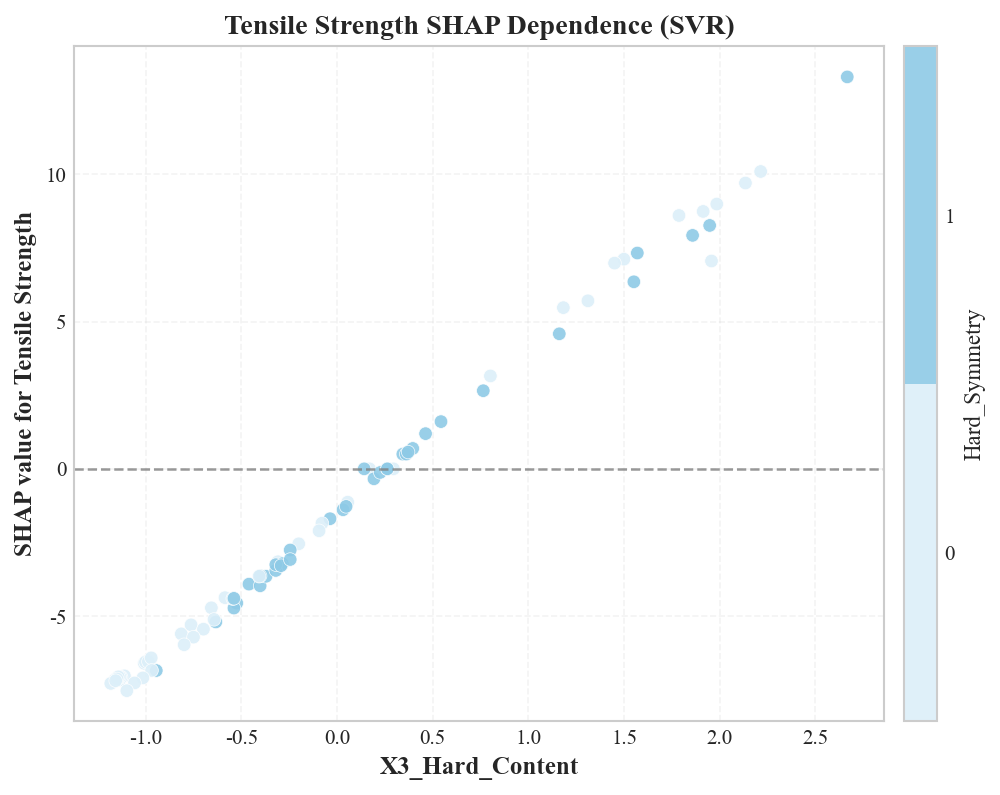

✅ Tensile Strength: model=SVR (upper_cells) | x=X3_Hard_Content | color=Hard_Symmetry


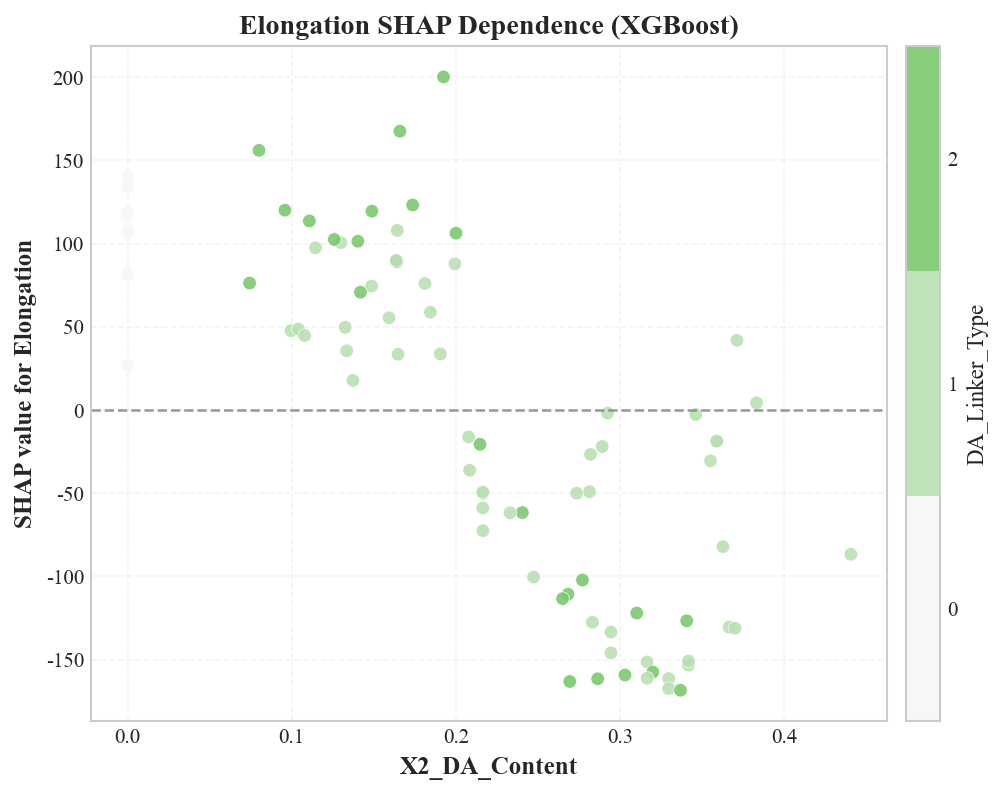

✅ Elongation: model=XGBoost (fallback) | x=X2_DA_Content | color=DA_Linker_Type


100%|██████████| 37/37 [00:00<00:00, 64.02it/s]


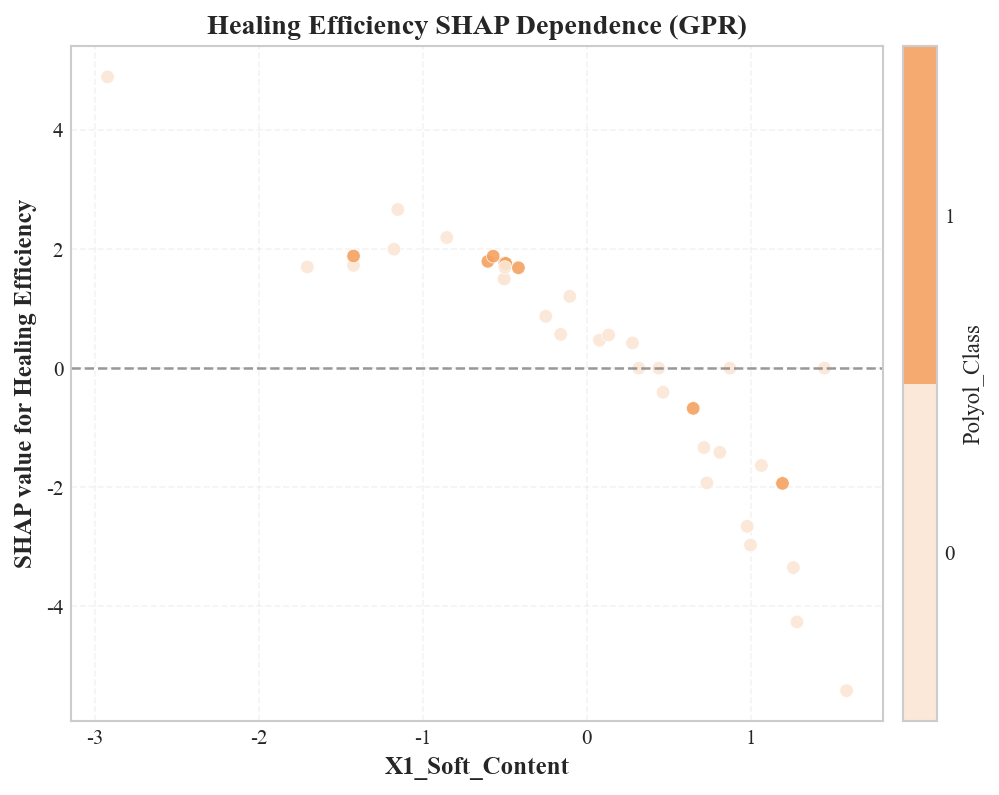

✅ Healing Efficiency: model=GPR (fallback) | x=X1_Soft_Content | color=Polyol_Class
🎯 三张 SHAP Dependence Plot（蓝/绿/橙）已生成。


In [24]:
# ============================================
# 5. SHAP Dependence Plot（论文图：三目标各1张）
# Dep.1: x=X3_Hard_Content, y=SHAP(Tensile Strength),      color=Hard_Symmetry
# Dep.2: x=X2_DA_Content,   y=SHAP(Elongation),            color=DA_Linker_Type
# Dep.3: x=X1_Soft_Content, y=SHAP(Healing Efficiency),    color=Polyol_Class
# 颜色：使用 visualization_graphs.ipynb 的蓝 / 绿 / 橙主题
# 色条：二分类/三分类使用离散分段标签（非连续）
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from xgboost import XGBRegressor
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# ---------- visualization notebook 同款配色 ----------
VIS_BLUE = '#8ECAE6'
VIS_GREEN = '#7BC96F'
VIS_ORANGE = '#F4A261'
VIS_LIGHT_BLUE_0 = '#DCEFF9'
VIS_LIGHT_ORANGE_0 = '#FBE6D5'

def _single_hue_cmap(base_color, name='single_hue', low_color='#f7f7f7'):
    return LinearSegmentedColormap.from_list(name, [low_color, base_color])

def _build_discrete_cmap(theme_color, low_color='#f7f7f7', n_class=2, name='discrete_hue'):
    if n_class <= 1:
        return ListedColormap([theme_color], name=name)
    if n_class == 2:
        return ListedColormap([low_color, theme_color], name=name)
    grad = LinearSegmentedColormap.from_list(name + '_grad', [low_color, theme_color])
    colors = [grad(v) for v in np.linspace(0.0, 1.0, n_class)]
    return ListedColormap(colors, name=name)

# ---------- 数据与特征 ----------
df_dep = pd.read_csv('Final_Features_Ultimate_all_deletion.csv')
features_mech_dep = [
    'X1_Soft_Content', 'X2_DA_Content', 'X3_Hard_Content', 'X4_R_Ratio', 'X5_Add_Crosslink',
    'DA_Linker_Type', 'Network_Topology', 'Polyol_Class', 'Iso_Class',
    'Soft_Mw', 'Constraint_Factor', 'Hard_Symmetry', 'Soft_Cryst', 'Synergy_Feature'
]
features_heal_dep = features_mech_dep + ['healing_temperature', 'healing_time']

def _get_clean_xy_dep(target_col, feat_cols):
    d = df_dep.dropna(subset=[target_col] + feat_cols).copy()
    return d[feat_cols].copy(), d[target_col].values

def _build_fallback_model(model_name):
    if model_name == 'SVR':
        return make_pipeline(StandardScaler(), SVR(C=500, gamma=1.0, epsilon=0.1, kernel='rbf'))
    if model_name == 'XGBoost':
        return XGBRegressor(
            n_estimators=300, learning_rate=0.03, max_depth=5,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=0.0, reg_lambda=1.0,
            random_state=42, n_jobs=-1
        )
    if model_name == 'GPR':
        kernel = 1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(
            noise_level=0.1, noise_level_bounds=(1e-5, 1e1)
        )
        return make_pipeline(
            StandardScaler(),
            GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=5)
        )
    raise ValueError(f'未知模型: {model_name}')

def _get_best_model_dep(target_col):
    # 优先：复用你上方单元中已调好的最优模型
    if target_col == 'tensile_strength':
        if 'res_df_tensile' in globals() and 'best_models' in globals() and isinstance(best_models, dict):
            best_name = str(res_df_tensile.sort_values('R2', ascending=False).iloc[0]['Model'])
            if best_name in best_models:
                return best_name, clone(best_models[best_name]), 'upper_cells'
        if 'res_df' in globals() and 'best_models' in globals() and isinstance(best_models, dict):
            best_name = str(res_df.sort_values('R2', ascending=False).iloc[0]['Model'])
            if best_name in best_models:
                return best_name, clone(best_models[best_name]), 'upper_cells'
        return 'SVR', _build_fallback_model('SVR'), 'fallback'

    if target_col == 'elongation':
        if 'res_df_elong' in globals() and 'best_models_elong' in globals() and isinstance(best_models_elong, dict):
            best_name = str(res_df_elong.sort_values('R2', ascending=False).iloc[0]['Model'])
            if best_name in best_models_elong:
                return best_name, clone(best_models_elong[best_name]), 'upper_cells'
        return 'XGBoost', _build_fallback_model('XGBoost'), 'fallback'

    if target_col == 'healing_eff':
        if 'res_df_heal' in globals() and 'best_models_heal' in globals() and isinstance(best_models_heal, dict):
            best_name = str(res_df_heal.sort_values('R2', ascending=False).iloc[0]['Model'])
            if best_name in best_models_heal:
                return best_name, clone(best_models_heal[best_name]), 'upper_cells'
        return 'GPR', _build_fallback_model('GPR'), 'fallback'

    raise ValueError(f'未知目标: {target_col}')

def _compute_shap_values_dep(model_name, model, X_df):
    if model_name == 'XGBoost':
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_df)
        X_for_plot = X_df.copy()
    elif model_name == 'SVR':
        scaler = model.named_steps['standardscaler']
        svr_model = model.named_steps['svr']
        X_scaled = scaler.transform(X_df.values)
        bg = shap.kmeans(X_scaled, k=min(30, len(X_df))).data
        explainer = shap.KernelExplainer(svr_model.predict, bg)
        shap_vals = explainer.shap_values(X_scaled, nsamples=400)
        X_for_plot = pd.DataFrame(X_scaled, columns=X_df.columns, index=X_df.index)
    elif model_name == 'GPR':
        scaler = model.named_steps['standardscaler']
        gpr_model = model.named_steps['gaussianprocessregressor']
        X_scaled = scaler.transform(X_df.values)
        bg = shap.kmeans(X_scaled, k=min(30, len(X_df))).data
        explainer = shap.KernelExplainer(gpr_model.predict, bg)
        shap_vals = explainer.shap_values(X_scaled, nsamples=400)
        X_for_plot = pd.DataFrame(X_scaled, columns=X_df.columns, index=X_df.index)
    else:
        explainer = shap.Explainer(model.predict, X_df)
        shap_vals = explainer(X_df).values
        X_for_plot = X_df.copy()

    shap_vals = np.array(shap_vals)
    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 0]
    return shap_vals, X_for_plot

def _prepare_color_series(x_df_raw, color_feature):
    color_raw = x_df_raw[color_feature].copy()
    if pd.api.types.is_numeric_dtype(color_raw):
        nunique = color_raw.nunique(dropna=True)
        if nunique <= 8:
            cat = color_raw.astype('Int64').astype(str)
            cats = sorted(cat.unique())
            mapper = {c: i for i, c in enumerate(cats)}
            codes = cat.map(mapper).astype(float).values
            ticks = np.arange(len(cats))
            ticklabels = cats
            return codes, True, ticks, ticklabels
        return color_raw.values, False, None, None

    cat = color_raw.astype(str)
    cats = sorted(cat.unique())
    mapper = {c: i for i, c in enumerate(cats)}
    codes = cat.map(mapper).astype(float).values
    ticks = np.arange(len(cats))
    ticklabels = cats
    return codes, True, ticks, ticklabels

def plot_custom_dependence(target_name, target_col, feat_cols, x_feature, color_feature, theme_color, low_color='#f7f7f7'):
    X_df, y = _get_clean_xy_dep(target_col, feat_cols)
    model_name, model, model_source = _get_best_model_dep(target_col)
    model.fit(X_df.values, y)

    shap_vals, X_for_plot = _compute_shap_values_dep(model_name, model, X_df)

    if x_feature not in X_df.columns:
        raise ValueError(f'{target_name}: x_feature `{x_feature}` 不在特征列表中')
    if color_feature not in X_df.columns:
        raise ValueError(f'{target_name}: color_feature `{color_feature}` 不在特征列表中')

    x_idx = list(X_df.columns).index(x_feature)
    x_vals = X_for_plot[x_feature].values
    y_shap = shap_vals[:, x_idx]

    c_vals, is_discrete, ticks, ticklabels = _prepare_color_series(X_df, color_feature)

    fig, ax = plt.subplots(figsize=(7.2, 5.4), dpi=150)

    if is_discrete and ticks is not None and ticklabels is not None:
        n_class = len(ticks)
        cmap_theme = _build_discrete_cmap(
            theme_color=theme_color, low_color=low_color, n_class=n_class, name=f'discrete_{target_col}'
        )
        boundaries = np.arange(-0.5, n_class + 0.5, 1.0)
        norm = BoundaryNorm(boundaries, cmap_theme.N, clip=True)
        sc = ax.scatter(
            x_vals, y_shap,
            c=c_vals, cmap=cmap_theme, norm=norm,
            s=42, alpha=0.90, edgecolors='white', linewidths=0.35
        )
        cbar = plt.colorbar(sc, ax=ax, pad=0.02, boundaries=boundaries, ticks=ticks, spacing='proportional')
        cbar.set_ticklabels(ticklabels)
    else:
        cmap_theme = _single_hue_cmap(theme_color, name=f'cmap_{target_col}', low_color=low_color)
        sc = ax.scatter(
            x_vals, y_shap,
            c=c_vals, cmap=cmap_theme,
            s=42, alpha=0.90, edgecolors='white', linewidths=0.35
        )
        cbar = plt.colorbar(sc, ax=ax, pad=0.02)

    ax.axhline(0, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.grid(alpha=0.22, linestyle='--')

    ax.set_xlabel(x_feature, fontsize=12, fontweight='bold')
    ax.set_ylabel(f'SHAP value for {target_name}', fontsize=12, fontweight='bold')
    ax.set_title(f'{target_name} SHAP Dependence ({model_name})', fontsize=13.5, fontweight='bold')

    cbar.set_label(color_feature, fontsize=11)

    plt.tight_layout()
    plt.show()

    print(f'✅ {target_name}: model={model_name} ({model_source}) | x={x_feature} | color={color_feature}')

# ---------- 按图示绘制三张 Dependence 图（蓝/绿/橙） ----------
plot_custom_dependence(
    target_name='Tensile Strength',
    target_col='tensile_strength',
    feat_cols=features_mech_dep,
    x_feature='X3_Hard_Content',
    color_feature='Hard_Symmetry',
    theme_color=VIS_BLUE,
    low_color=VIS_LIGHT_BLUE_0
)

plot_custom_dependence(
    target_name='Elongation',
    target_col='elongation',
    feat_cols=features_mech_dep,
    x_feature='X2_DA_Content',
    color_feature='DA_Linker_Type',
    theme_color=VIS_GREEN
)

plot_custom_dependence(
    target_name='Healing Efficiency',
    target_col='healing_eff',
    feat_cols=features_heal_dep,
    x_feature='X1_Soft_Content',
    color_feature='Polyol_Class',
    theme_color=VIS_ORANGE,
    low_color=VIS_LIGHT_ORANGE_0
)

print('🎯 三张 SHAP Dependence Plot（蓝/绿/橙）已生成。')

100%|██████████| 37/37 [00:00<00:00, 73.28it/s]


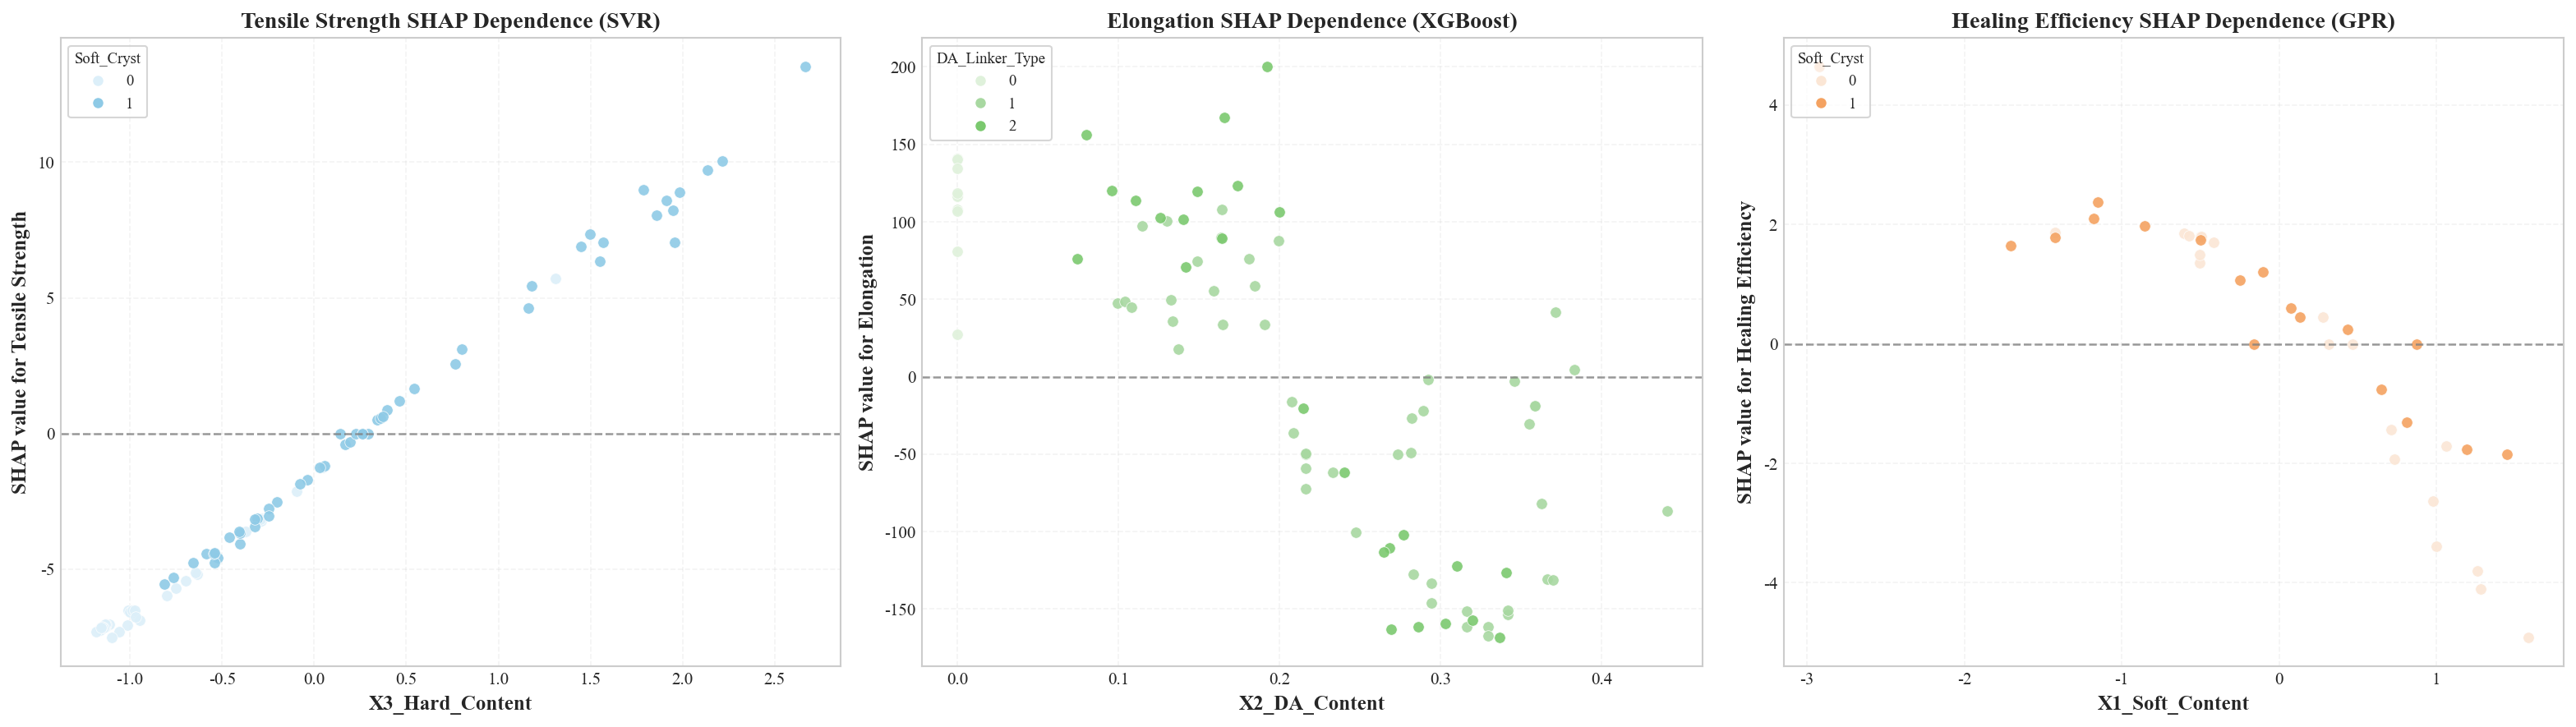

✅ 已完成三图排版：左上角分类图例（蓝/浅蓝；绿/浅绿；橙/浅橙）


In [26]:
# ============================================
# 论文排版版：三张 SHAP Dependence 并排 + 左上角离散图例（无色条）
# 保留三图：
# 1) Tensile:   x=X3_Hard_Content, color=Soft_Cryst
# 2) Elongation:x=X2_DA_Content,   color=DA_Linker_Type
# 3) Healing:   x=X1_Soft_Content, color=Soft_Cryst
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 若前一格尚未运行，给出提示
required_symbols = [
    '_get_clean_xy_dep', '_get_best_model_dep', '_compute_shap_values_dep', '_prepare_color_series',
    'features_mech_dep', 'features_heal_dep',
    'VIS_BLUE', 'VIS_GREEN', 'VIS_ORANGE', 'VIS_LIGHT_BLUE_0', 'VIS_LIGHT_ORANGE_0'
 ]
missing = [s for s in required_symbols if s not in globals()]
if missing:
    raise RuntimeError(f'请先运行第23个单元后再运行本单元，缺失: {missing}')

# 绿色浅色补充（与当前蓝/橙风格一致）
VIS_LIGHT_GREEN_0 = '#DFF1DB'
VIS_LIGHT_GREEN_1 = '#A8D8A1'

plot_cfg = [
    {
        'title': 'Tensile Strength SHAP Dependence (SVR)',
        'target_name': 'Tensile Strength',
        'target_col': 'tensile_strength',
        'feat_cols': features_mech_dep,
        'x_feature': 'X3_Hard_Content',
        'color_feature': 'Soft_Cryst',
        'palette': [VIS_LIGHT_BLUE_0, VIS_BLUE]
    },
    {
        'title': 'Elongation SHAP Dependence (XGBoost)',
        'target_name': 'Elongation',
        'target_col': 'elongation',
        'feat_cols': features_mech_dep,
        'x_feature': 'X2_DA_Content',
        'color_feature': 'DA_Linker_Type',
        'palette': [VIS_LIGHT_GREEN_0, VIS_LIGHT_GREEN_1, VIS_GREEN]
    },
    {
        'title': 'Healing Efficiency SHAP Dependence (GPR)',
        'target_name': 'Healing Efficiency',
        'target_col': 'healing_eff',
        'feat_cols': features_heal_dep,
        'x_feature': 'X1_Soft_Content',
        'color_feature': 'Soft_Cryst',
        'palette': [VIS_LIGHT_ORANGE_0, VIS_ORANGE]
    }
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=150)

for ax, cfg in zip(axes, plot_cfg):
    X_df, y = _get_clean_xy_dep(cfg['target_col'], cfg['feat_cols'])
    model_name, model, _ = _get_best_model_dep(cfg['target_col'])
    model.fit(X_df.values, y)
    shap_vals, X_for_plot = _compute_shap_values_dep(model_name, model, X_df)

    x_idx = list(X_df.columns).index(cfg['x_feature'])
    x_vals = X_for_plot[cfg['x_feature']].values
    y_shap = shap_vals[:, x_idx]

    c_vals, is_discrete, ticks, ticklabels = _prepare_color_series(X_df, cfg['color_feature'])

    if not is_discrete or ticks is None or ticklabels is None:
        q = np.quantile(c_vals, [0.33, 0.67])
        bins = np.digitize(c_vals, q, right=True)
        c_vals = bins.astype(float)
        uniq = np.unique(c_vals)
        ticks = uniq
        ticklabels = [f'bin_{int(v)}' for v in uniq]

    classes = [int(v) for v in sorted(np.unique(c_vals))]
    labels = [str(ticklabels[v]) if v < len(ticklabels) else str(v) for v in classes]

    palette = cfg['palette']
    if len(palette) < len(classes):
        palette = palette + [palette[-1]] * (len(classes) - len(palette))

    for i, cls in enumerate(classes):
        m = c_vals == float(cls)
        ax.scatter(
            x_vals[m], y_shap[m],
            s=42, alpha=0.90,
            color=palette[i], edgecolors='white', linewidths=0.35
        )

    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='None', markersize=7,
               markerfacecolor=palette[i], markeredgecolor='white', label=labels[i])
        for i in range(len(classes))
    ]
    ax.legend(handles=legend_handles, title=cfg['color_feature'], loc='upper left',
              frameon=True, fontsize=9, title_fontsize=9)

    ax.axhline(0, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.grid(alpha=0.22, linestyle='--')
    ax.set_xlabel(cfg['x_feature'], fontsize=12, fontweight='bold')
    ax.set_ylabel(f"SHAP value for {cfg['target_name']}", fontsize=12, fontweight='bold')
    ax.set_title(cfg['title'], fontsize=13.5, fontweight='bold')

plt.tight_layout()
plt.show()

print('✅ 已完成三图排版：左上角分类图例（蓝/浅蓝；绿/浅绿；橙/浅橙）')